In [1]:
import scipy.io as sio
import numpy as np
from scipy.signal import butter, filtfilt
from mne.decoding import CSP
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
def bandpass_filter(data, lowcut=8, highcut=30, fs=250, order=4):
    """Applies a Butterworth bandpass filter to EEG data."""
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

In [3]:
def load_BCI2a_data(data_path, subject, training, all_trials=True):    
    # Define MI-trials parameters
    n_channels = 22
    n_tests = 6 * 48     
    window_Length = 7 * 250  # Total trial duration (7s)

    # Define MI trial window 
    fs = 250          # Sampling rate
    t1 = int(2 * fs)  # Start time_point (2s)
    t2 = int(6 * fs)  # End time_point (6s)

    class_return = np.zeros(n_tests)
    data_return = np.zeros((n_tests, n_channels, window_Length))  #(trials x channels x time)

    NO_valid_trial = 0
    if training:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'T.mat')   #()
    else:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'E.mat')

    a_data = a['data']  #()
    
    for ii in range(a_data.size):
        a_data1 = a_data[0, ii]
        a_data2 = [a_data1[0, 0]]
        a_data3 = a_data2[0]
        a_X = a_data3[0]  # EEG signals
        a_trial = a_data3[1]  # Trial start indices
        a_y = a_data3[2]  # Class labels
        a_artifacts = a_data3[5]  # Artifact presence

        for trial in range(a_trial.size):
            if a_artifacts[trial] != 0 and not all_trials:
                continue
            # Extract EEG trial (time x channels) and transpose to (channels x time)
            trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
            
            # Apply bandpass filter
            trial_data = bandpass_filter(trial_data, lowcut=8, highcut=30, fs=fs, order=4)

            data_return[NO_valid_trial, :, :] = trial_data
            class_return[NO_valid_trial] = int(a_y[trial])
            NO_valid_trial += 1        

    # Keep only valid trials and select MI window (2s to 6s)
    data_return = data_return[0:NO_valid_trial, :, t1:t2]
    class_return = class_return[0:NO_valid_trial]
    class_return = (class_return - 1).astype(int)  # Convert to zero-based index

    return data_return, class_return

In [4]:
import torch
import numpy as np
from torch_geometric.data import Data, Dataset
from itertools import combinations

class EEGGraphDataset(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, spec_coh_values, transform=None):
        self.epochs = X                  # shape: [n_samples, 22 x T]
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform
        self.spec_coh_values = spec_coh_values  # shape: [n_samples, 231]

        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = list(range(len(self.ch_names)))  # [0..21]

        # Build undirected edge index for upper triangle (no self-loops)
        edge_list = list(combinations(self.node_ids, 2))  # 231 edges
        self.edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()

        real_idx = self.indices[idx]

        # Shape: [22, time_steps]
        node_features = torch.from_numpy(self.epochs[real_idx].reshape(22, -1)).float()

        # Get spectral coherence values for current sample: shape [231]
        edge_weights = torch.tensor(self.spec_coh_values[real_idx], dtype=torch.float32)

        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=real_idx,
            y=torch.tensor(self.labels[real_idx], dtype=torch.long)
        )

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, ChebConv, SAGEConv, global_mean_pool

# --- GNN Blocks with LayerNorm ---

class GraphConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = GraphConv(hidden_channels, hidden_channels)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = GraphConv(hidden_channels, hidden_channels // 2)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class ChebConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = ChebConv(hidden_channels, hidden_channels // 2, K)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class SAGEConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels // 2)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index)))
        x = F.relu(self.ln2(self.conv2(x, edge_index)))
        x = F.relu(self.ln3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

# --- Transformer Block (unchanged) ---

class TransformerBlock(nn.Module):
    def __init__(self, input_dim, nhead=4, num_layers=2, dim_feedforward=256):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        return self.transformer(x)

# --- Combined GNN + Transformer Model with LayerNorm ---

class GraphTransformerNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=3, transformer_heads=4, transformer_layers=3,dropouts=0.5):
        super().__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)

        self.feature_dim = (hidden_channels // 2) * 3
        assert self.feature_dim % transformer_heads == 0, "embed_dim must be divisible by num_heads"

        self.transformer = TransformerBlock(
            input_dim=self.feature_dim,
            nhead=transformer_heads,
            num_layers=transformer_layers
        )

        self.mlp = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_channels),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels // 2),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index, edge_weight, batch):
        g1 = self.graph_block(x, edge_index, edge_weight, batch)
        g2 = self.cheb_block(x, edge_index, edge_weight, batch)
        g3 = self.sage_block(x, edge_index, edge_weight, batch)

        x = torch.cat([g1, g2, g3], dim=1)

        x = x.unsqueeze(1)  # (batch_size, seq_len=1, feature_dim)
        x = self.transformer(x)
        x = x[:, 0, :]  # back to (batch_size, feature_dim)

        return self.mlp(x)

In [9]:
# cv = ShuffleSplit(10, test_size=0.2, random_state=42)
# cv_split = cv.split(epochs_data_train)
# lda = LinearDiscriminantAnalysis()
# csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
# clf = Pipeline([("CSP", csp), ("LDA", lda)])
# scores = cross_val_score(clf, epochs_data_train, labels, cv=cv, n_jobs=None)

In [30]:
train_data, train_labels = load_BCI2a_data('/Users/siddharth/Documents/Brainconnectivity/BCI_Kaggle/', subject=0, training=True, all_trials=True)
test_data, test_labels = load_BCI2a_data('/Users/siddharth/Documents/Brainconnectivity/BCI_Kaggle/', subject=0, training=False, all_trials=True)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [31]:
train_mask = np.logical_or(train_labels == 0, train_labels == 1)
train_data_binary = train_data[train_mask]
train_labels_binary = train_labels[train_mask]

# Filter test data
test_mask = np.logical_or(test_labels == 0, test_labels == 1)
test_data_binary = test_data[test_mask]
test_labels_binary = test_labels[test_mask]

csp = CSP(n_components=22, reg=None, log=True, norm_trace=False,transform_into='average_power')
train_csp = csp.fit_transform(train_data_binary, train_labels_binary)

test_csp = csp.transform(test_data_binary)


In [36]:
print("Class distribution in binary train set:", np.bincount(train_labels_binary))
print("Class distribution in binary test set:", np.bincount(test_labels_binary))

Class distribution in binary train set: [72 72]
Class distribution in binary test set: [72 72]


In [6]:
import numpy as np
from scipy.signal import coherence
from tqdm import tqdm

def compute_spectral_coherence(data, sfreq=250):
    """
    Compute coherence between all pairs of channels for each sample.
    
    Args:
        data: np.ndarray, shape (samples, channels, time)
        sfreq: Sampling frequency
    
    Returns:
        np.ndarray, shape (samples, num_edges), coherence values averaged over frequencies
    """
    n_samples, n_channels, _ = data.shape
    coherence_features = []

    for sample in tqdm(data, desc="Computing coherence"):
        sample_coherence = []
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                f, coh = coherence(sample[i], sample[j], fs=sfreq, nperseg=256)
                avg_coh = np.mean(coh)  # Optionally, take band average
                sample_coherence.append(avg_coh)
        coherence_features.append(sample_coherence)

    return np.array(coherence_features)

In [7]:
train_csp = []
for ch in range(22):
    train_csp = csp.fit_transform(train_data_binary[:, ch, :], train_labels_binary)

NameError: name 'csp' is not defined

In [83]:
train_data, train_labels = load_BCI2a_data('BCI_Kaggle/', subject=0, training=True, all_trials=True)
test_data, test_labels = load_BCI2a_data('BCI_Kaggle/', subject=0, training=False, all_trials=True)

# 2. Binary Class Filter (Classes 0 and 1 only)
train_mask = np.isin(train_labels, [0, 1])
test_mask = np.isin(test_labels, [0, 1])

train_data_binary = train_data[train_mask]
train_labels_binary = train_labels[train_mask]

test_data_binary = test_data[test_mask]
test_labels_binary = test_labels[test_mask]

# 3. CSP Feature Extraction
csp = CSP(n_components=22, reg=None, log=True, norm_trace=False, transform_into='average_power')

train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
test_csp = csp.transform(test_data_binary)

# 4. Repeat CSP features across channels (to match shape expected by Graph Transformer)
#    Assumes input to EEGGraphDataset expects shape: (samples, channels, features)
train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (N, 22, 22)
test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)

# 5. Compute Spectral Coherence (likely used inside EEGGraphDataset)
train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
test_spec_coh  = compute_spectral_coherence(test_data_binary, sfreq=250)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 36 (2.2e-16 eps * 22 dim * 7.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Computing coherence: 100%|██████████| 144/144 [00:10<00:00, 13.45it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3436551176.py:56: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3436551176.py:56: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


In [90]:
# 6. Dataset Construction
train_dataset = EEGGraphDataset(
    X=train_features, 
    y=train_labels_binary, 
    indices=np.arange(len(train_labels_binary)), 
    loader_type="train", 
    sfreq=250,
    spec_coh_values=train_spec_coh
    
)

test_dataset = EEGGraphDataset(
    X=test_features, 
    y=test_labels_binary, 
    indices=np.arange(len(test_labels_binary)), 
    loader_type="test", 
    sfreq=250,
    spec_coh_values =test_spec_coh
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 2. Instantiate Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphTransformerNet(in_channels=22, hidden_channels=32, out_channels=1, K=3, transformer_heads=8,dropouts=0.3)


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs:  17%|█▋        | 171/1000 [01:54<09:16,  1.49it/s, Train Loss=0.3516, Train Acc=0.9306, Test Acc=0.8333, Test Kappa=0.6667, Best Test Kappa=0.7778 (Epoch 72), Best Test Acc=0.8889 (Epoch 72)]


⏹️ Early stopping at epoch 172. No improvement for 100 consecutive epochs.


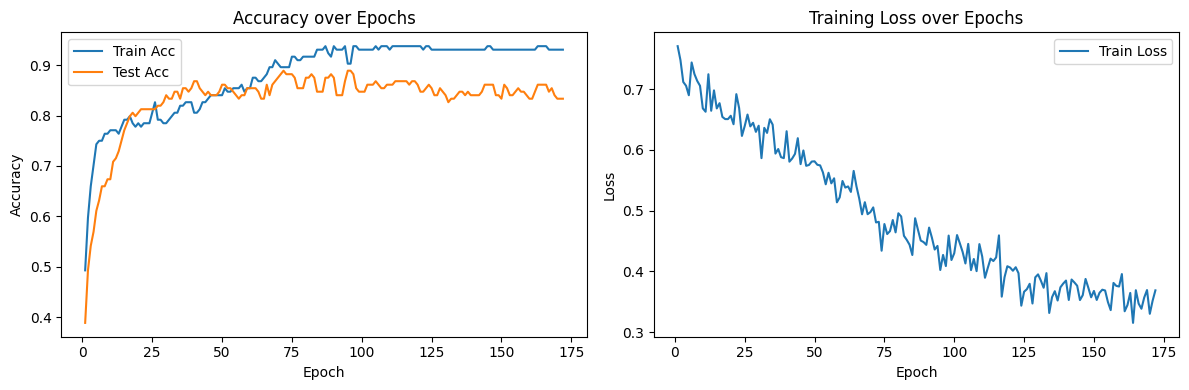

In [91]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

# 4. Train Function
def train_model(model, train_loader):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
        loss = criterion(out, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)
from sklearn.metrics import cohen_kappa_score
def evaluate_model(model, data_loader, return_preds=False):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().float().numpy())
    acc = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    if return_preds:
        return acc, kappa, all_labels, all_preds
    return acc, kappa

# 6. Training Loop with Progress Bar and Metrics Logging
# 6. Training Loop with Early Stopping and Progress Bar
num_epochs = 1000
patience = 100
early_stop_counter = 0

best_test_acc = 0.0
best_epoch = 0
best_model_state = None
best_test_kappa = 0.0
train_losses = []
train_accuracies = []
test_accuracies = []

epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

for epoch in epoch_bar:
    train_loss = train_model(model, train_loader)
    train_acc, train_kappa = evaluate_model(model, train_loader)
    test_acc, test_kappa = evaluate_model(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    if test_kappa>best_test_kappa:
        best_test_kappa = test_kappa
        best_epoch = epoch
        best_model_state = model.state_dict()
    # Check for improvement
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        best_model_state = model.state_dict()  # Save best model
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    # Early stopping condition
    if early_stop_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
        break

    epoch_bar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Train Acc': f'{train_acc:.4f}',
        'Test Acc': f'{test_acc:.4f}',
        'Test Kappa': f'{test_kappa:.4f}',
        'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
        'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
    })
# Load the best model state before evaluation
if best_model_state:
    model.load_state_dict(best_model_state)

# final_acc, final_kappa = evaluate_model(model, test_loader)
# print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
# print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


# 7. Optional: Plot Learning Curves
def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, test_accuracies, label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_learning_curves(train_losses, train_accuracies, test_accuracies)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 36 (2.2e-16 eps * 22 dim * 7.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  11%|█▏        | 114/1000 [01:04<08:21,  1.77it/s, Train Loss=0.3548, Train Acc=0.9306, Test Acc=0.8194, Test Kappa=0.6389, Best Test Kappa=0.7778 (Epoch 15), Best Test Acc=0.8889 (Epoch 15)]


⏹️ Early stopping at epoch 115. No improvement for 100 consecutive epochs.


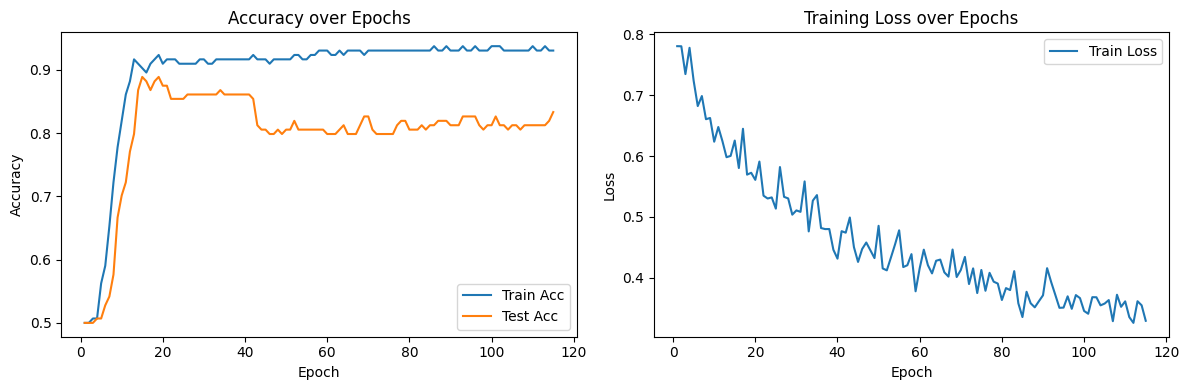

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 41 (2.2e-16 eps * 22 dim * 8.4e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  14%|█▍        | 143/1000 [01:35<09:33,  1.50it/s, Train Loss=0.5859, Train Acc=0.8264, Test Acc=0.5486, Test Kappa=0.0972, Best Test Kappa=0.1528 (Epoch 44), Best Test Acc=0.5764 (Epoch 44)]


⏹️ Early stopping at epoch 144. No improvement for 100 consecutive epochs.


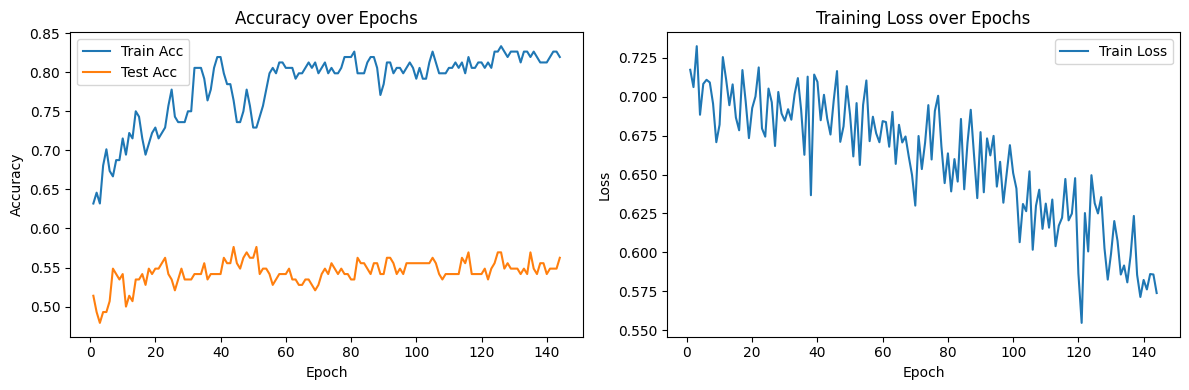

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  30%|███       | 301/1000 [03:07<07:14,  1.61it/s, Train Loss=0.1421, Train Acc=1.0000, Test Acc=0.9167, Test Kappa=0.8333, Best Test Kappa=0.8611 (Epoch 202), Best Test Acc=0.9306 (Epoch 202)]


⏹️ Early stopping at epoch 302. No improvement for 100 consecutive epochs.


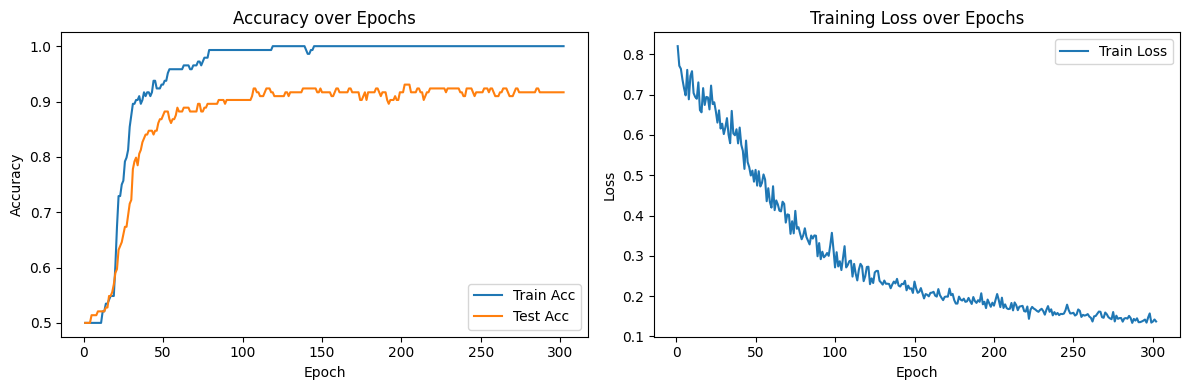

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 34 (2.2e-16 eps * 22 dim * 6.9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  24%|██▎       | 235/1000 [02:55<09:30,  1.34it/s, Train Loss=0.2439, Train Acc=0.9653, Test Acc=0.7292, Test Kappa=0.4583, Best Test Kappa=0.5000 (Epoch 136), Best Test Acc=0.7500 (Epoch 136)]


⏹️ Early stopping at epoch 236. No improvement for 100 consecutive epochs.


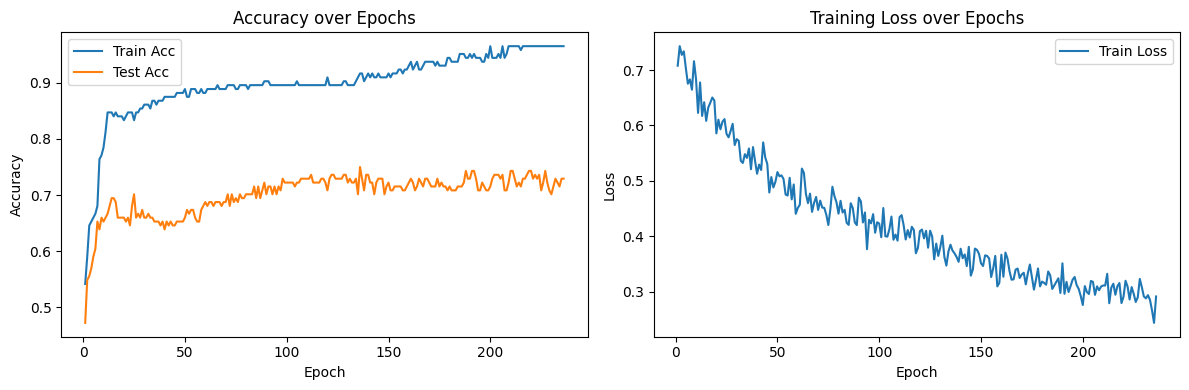

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 30 (2.2e-16 eps * 22 dim * 6.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  10%|█         | 105/1000 [00:49<06:58,  2.14it/s, Train Loss=0.6539, Train Acc=0.7431, Test Acc=0.5000, Test Kappa=0.0000, Best Test Kappa=0.0556 (Epoch 33), Best Test Acc=0.5278 (Epoch 33)] 


KeyboardInterrupt: 

In [93]:
for subi in range(0,9):
    train_data, train_labels = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
    test_data, test_labels = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)

    # 2. Binary Class Filter (Classes 0 and 1 only)
    train_mask = np.isin(train_labels, [0, 1])
    test_mask = np.isin(test_labels, [0, 1])

    train_data_binary = train_data[train_mask]
    train_labels_binary = train_labels[train_mask]

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]

    # 3. CSP Feature Extraction
    csp = CSP(n_components=22, reg=None, log=True, norm_trace=False, transform_into='average_power')

    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    # 4. Repeat CSP features across channels (to match shape expected by Graph Transformer)
    #    Assumes input to EEGGraphDataset expects shape: (samples, channels, features)
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (N, 22, 22)
    test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)

    # 5. Compute Spectral Coherence (likely used inside EEGGraphDataset)
    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh  = compute_spectral_coherence(test_data_binary, sfreq=250)

    # 6. Dataset Construction
# 6. Dataset Construction
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_labels_binary, 
        indices=np.arange(len(train_labels_binary)), 
        loader_type="train", 
        sfreq=250,
        spec_coh_values=train_spec_coh
        
    )

    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_labels_binary, 
        indices=np.arange(len(test_labels_binary)), 
        loader_type="test", 
        sfreq=250,
        spec_coh_values =test_spec_coh
    )

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # 2. Instantiate Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=22, hidden_channels=32, out_channels=1, K=3, transformer_heads=8,dropouts=0.3)


    # 3. Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    # 4. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    from sklearn.metrics import cohen_kappa_score
    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # 6. Training Loop with Progress Bar and Metrics Logging
    # 6. Training Loop with Early Stopping and Progress Bar
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_test_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_test_kappa = 0.0
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        test_acc, test_kappa = evaluate_model(model, test_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        if test_kappa>best_test_kappa:
            best_test_kappa = test_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        # Check for improvement
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_model_state = model.state_dict()  # Save best model
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # Early stopping condition
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test Kappa': f'{test_kappa:.4f}',
            'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
            'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
        })
    # Load the best model state before evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    # final_acc, final_kappa = evaluate_model(model, test_loader)
    # print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    # print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


    # 7. Optional: Plot Learning Curves
    def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(12, 4))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, test_accuracies, label='Test Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Call the plotting function
    plot_learning_curves(train_losses, train_accuracies, test_accuracies)

In [1]:
for test_sub in range(0,9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []
    for subi in range(0,9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)     # shape: (n_total_trials, n_channels, n_times)
    train_labels_all = np.concatenate(train_labels_all, axis=0) # shape: (n_total_trials,)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 =  load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training= False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)
    
    test_data = np.concatenate(test_data, axis=0)     # shape: (n_total_trials, n_channels, n_times)
    test_labels = np.concatenate(test_labels, axis=0) # shape: (n_total_trials,)
    # 2. Binary Class Filter (Classes 0 and 1 only)
    train_mask = np.isin(train_labels_all, [0, 1])
    test_mask = np.isin(test_labels, [0, 1])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask]

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]

    # 3. CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')

    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    # 4. Repeat CSP features across channels (to match shape expected by Graph Transformer)
    #    Assumes input to EEGGraphDataset expects shape: (samples, channels, features)
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (N, 22, 22)
    test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)

    # 5. Compute Spectral Coherence (likely used inside EEGGraphDataset)
    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh  = compute_spectral_coherence(test_data_binary, sfreq=250)

    # 6. Dataset Construction
    # 6. Dataset Construction
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_labels_binary, 
        indices=np.arange(len(train_labels_binary)), 
        loader_type="train", 
        sfreq=250,
        spec_coh_values=train_spec_coh
        
    )

    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_labels_binary, 
        indices=np.arange(len(test_labels_binary)), 
        loader_type="test", 
        sfreq=250,
        spec_coh_values =test_spec_coh
    )

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # 2. Instantiate Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8,dropouts=0.3)


    # 3. Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    # 4. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    from sklearn.metrics import cohen_kappa_score
    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # 6. Training Loop with Progress Bar and Metrics Logging
    # 6. Training Loop with Early Stopping and Progress Bar
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_test_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_test_kappa = 0.0
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        test_acc, test_kappa = evaluate_model(model, test_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        if test_kappa>best_test_kappa:
            best_test_kappa = test_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        # Check for improvement
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_model_state = model.state_dict()  # Save best model
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # Early stopping condition
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test Kappa': f'{test_kappa:.4f}',
            'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
            'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
        })
    # Load the best model state before evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    # final_acc, final_kappa = evaluate_model(model, test_loader)
    # print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    # print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


    # 7. Optional: Plot Learning Curves
    def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(12, 4))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, test_accuracies, label='Test Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Call the plotting function
    plot_learning_curves(train_losses, train_accuracies, test_accuracies)


=== Subject 0 held out for testing ===


NameError: name 'load_BCI2a_data' is not defined


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  39%|███▊      | 386/1000 [34:02<54:08,  5.29s/it, Train Loss=0.3415, Train Acc=0.8719, Val Acc=0.7701, Val Kappa=0.5416, Best Val Kappa=0.5745 (Epoch 287), Best Val Acc=0.7874 (Epoch 287)]  


⏹️ Early stopping at epoch 387. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6771
📊 Final Test Cohen’s Kappa Score: 0.3542


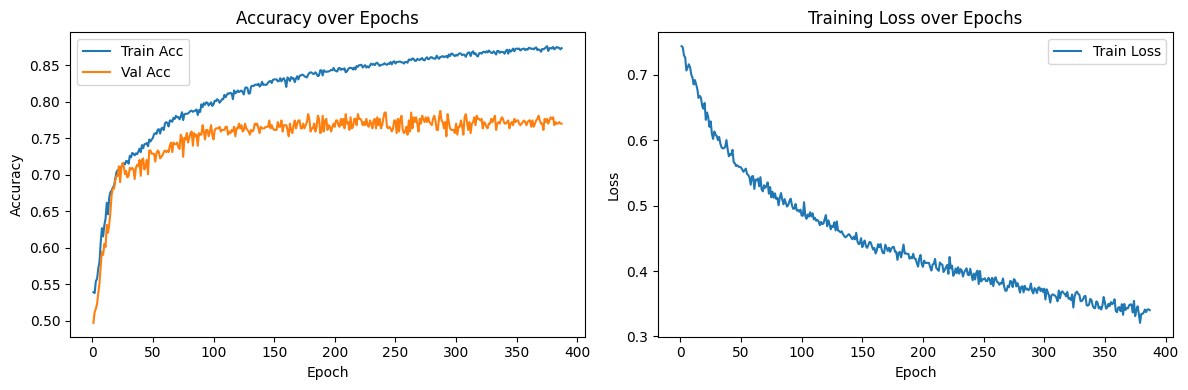


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  19%|█▉        | 188/1000 [19:24<1:23:50,  6.19s/it, Train Loss=0.3773, Train Acc=0.8622, Val Acc=0.7939, Val Kappa=0.5881, Best Val Kappa=0.6075 (Epoch 89), Best Val Acc=0.8048 (Epoch 89)]


⏹️ Early stopping at epoch 189. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4965
📊 Final Test Cohen’s Kappa Score: -0.0069


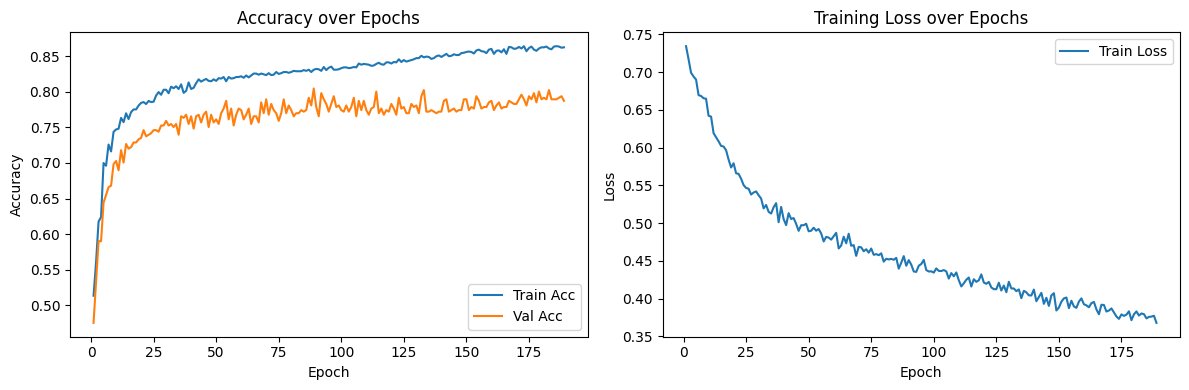


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  38%|███▊      | 383/1000 [1:11:21<1:54:56, 11.18s/it, Train Loss=0.3669, Train Acc=0.8524, Val Acc=0.8091, Val Kappa=0.6178, Best Val Kappa=0.6571 (Epoch 284), Best Val Acc=0.8286 (Epoch 284)]


⏹️ Early stopping at epoch 384. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7882
📊 Final Test Cohen’s Kappa Score: 0.5764


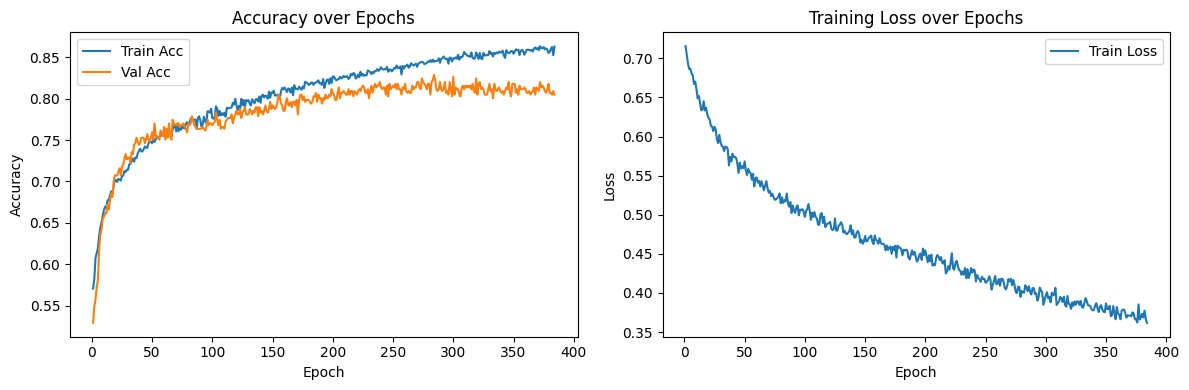


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  39%|███▊      | 387/1000 [5:59:01<9:28:41, 55.66s/it, Train Loss=0.3025, Train Acc=0.8947, Val Acc=0.8069, Val Kappa=0.6143, Best Val Kappa=0.6358 (Epoch 357), Best Val Acc=0.8178 (Epoch 357)] 


⏹️ Early stopping at epoch 388. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6215
📊 Final Test Cohen’s Kappa Score: 0.2431


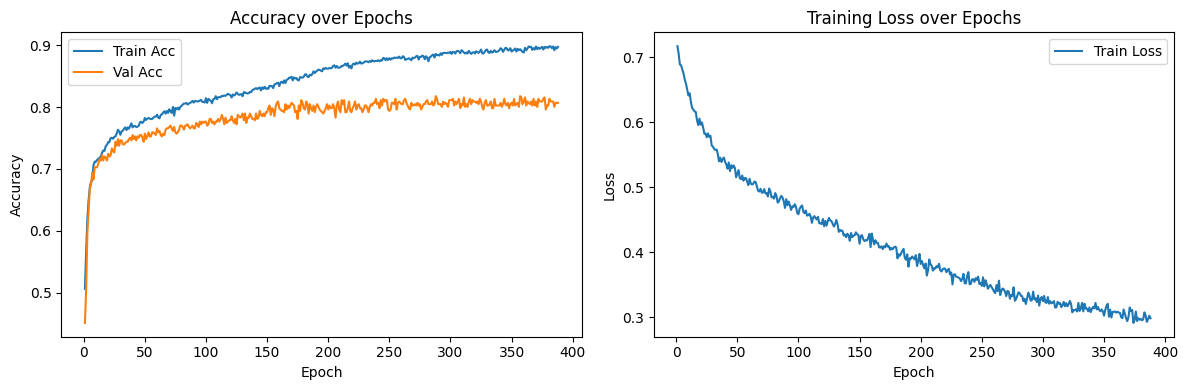


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  39%|███▉      | 394/1000 [30:55<47:33,  4.71s/it, Train Loss=0.2698, Train Acc=0.9230, Val Acc=0.8156, Val Kappa=0.6313, Best Val Kappa=0.6791 (Epoch 295), Best Val Acc=0.8395 (Epoch 295)]  


⏹️ Early stopping at epoch 395. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5174
📊 Final Test Cohen’s Kappa Score: 0.0347


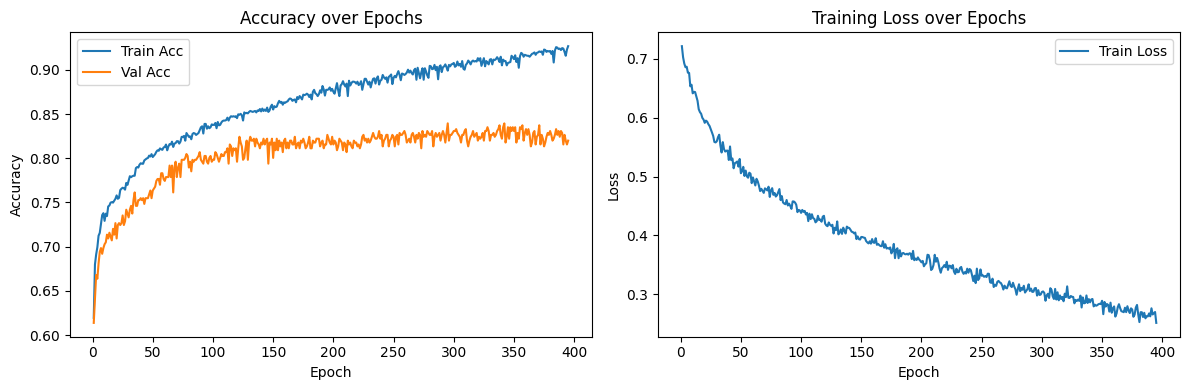


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  31%|███       | 311/1000 [24:08<53:29,  4.66s/it, Train Loss=0.3425, Train Acc=0.8513, Val Acc=0.8134, Val Kappa=0.6247, Best Val Kappa=0.6287 (Epoch 212), Best Val Acc=0.8156 (Epoch 212)]  


⏹️ Early stopping at epoch 312. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5000
📊 Final Test Cohen’s Kappa Score: 0.0000


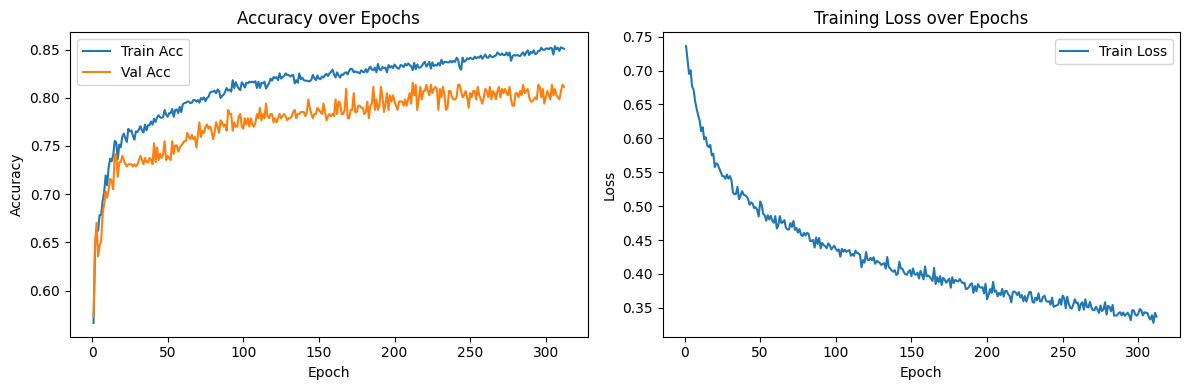


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  20%|█▉        | 197/1000 [14:12<57:53,  4.33s/it, Train Loss=0.4009, Train Acc=0.8448, Val Acc=0.8069, Val Kappa=0.6138, Best Val Kappa=0.6268 (Epoch 98), Best Val Acc=0.8134 (Epoch 98)]  


⏹️ Early stopping at epoch 198. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5069
📊 Final Test Cohen’s Kappa Score: 0.0139


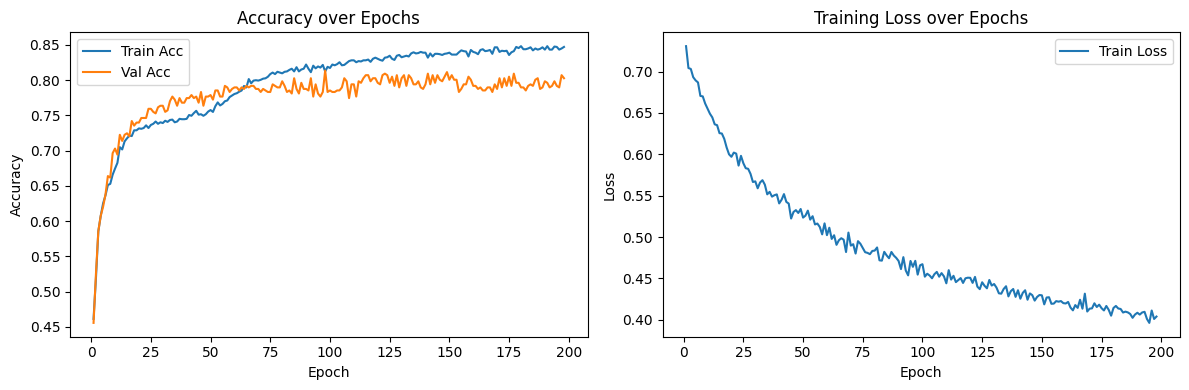


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  23%|██▎       | 233/1000 [18:44<1:01:40,  4.82s/it, Train Loss=0.3513, Train Acc=0.8774, Val Acc=0.7809, Val Kappa=0.5613, Best Val Kappa=0.5867 (Epoch 139), Best Val Acc=0.7939 (Epoch 139)]


⏹️ Early stopping at epoch 234. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6910
📊 Final Test Cohen’s Kappa Score: 0.3819


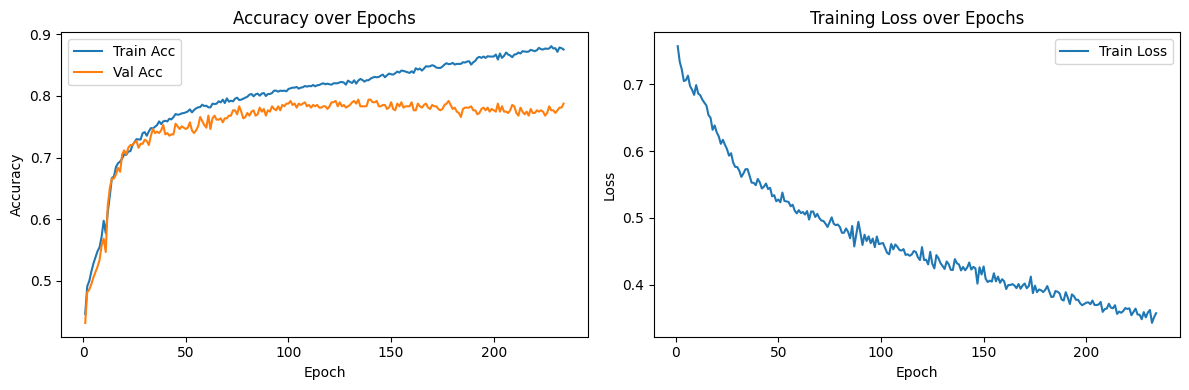


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  33%|███▎      | 333/1000 [1:38:34<3:17:26, 17.76s/it, Train Loss=0.2947, Train Acc=0.8953, Val Acc=0.8156, Val Kappa=0.6312, Best Val Kappa=0.6746 (Epoch 234), Best Val Acc=0.8373 (Epoch 234)]   


⏹️ Early stopping at epoch 334. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5938
📊 Final Test Cohen’s Kappa Score: 0.1875


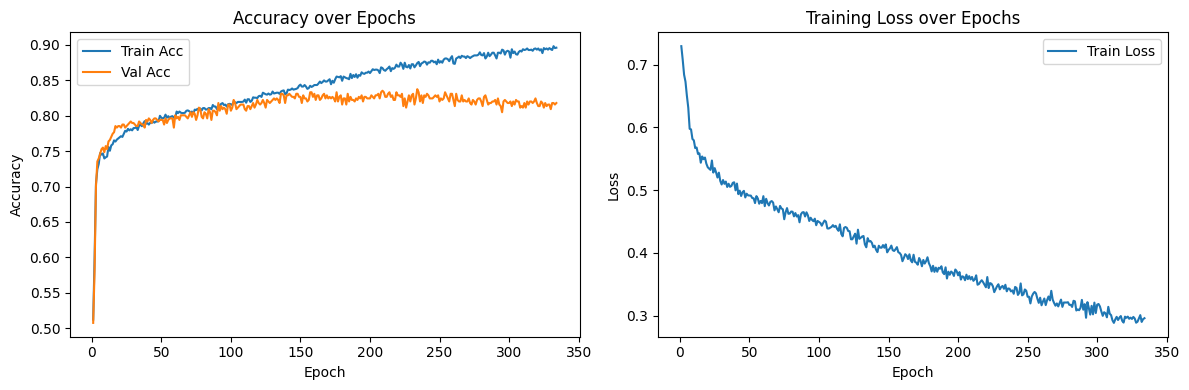

In [106]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [1, 2])
    test_mask = np.isin(test_labels, [1, 2])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask] - 1

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask] - 1

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)



=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  24%|██▍       | 245/1000 [17:24<53:39,  4.26s/it, Train Loss=0.4641, Train Acc=0.7878, Val Acc=0.7614, Val Kappa=0.5203, Best Val Kappa=0.5392 (Epoch 186), Best Val Acc=0.7701 (Epoch 186)]  


⏹️ Early stopping at epoch 246. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6111
📊 Final Test Cohen’s Kappa Score: 0.2222


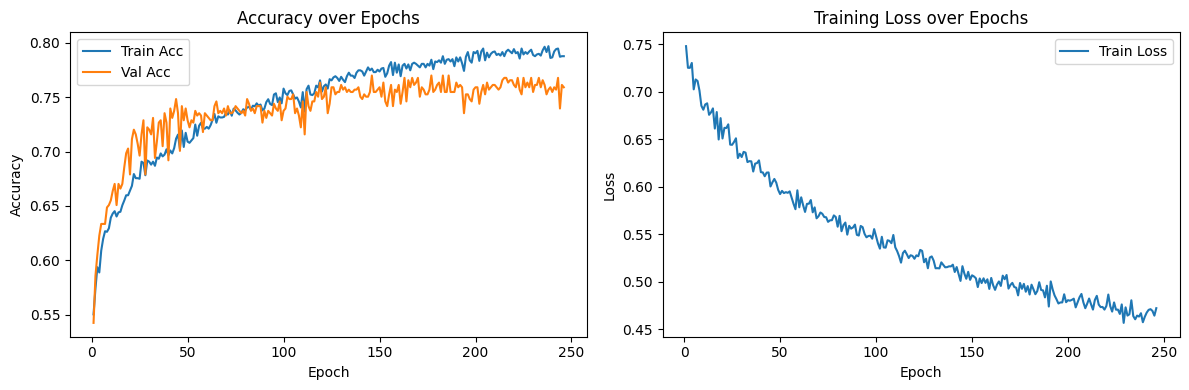


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  31%|███       | 309/1000 [9:53:46<22:07:48, 115.29s/it, Train Loss=0.3732, Train Acc=0.8481, Val Acc=0.7896, Val Kappa=0.5791, Best Val Kappa=0.6138 (Epoch 210), Best Val Acc=0.8069 (Epoch 210)]  


⏹️ Early stopping at epoch 310. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5417
📊 Final Test Cohen’s Kappa Score: 0.0833


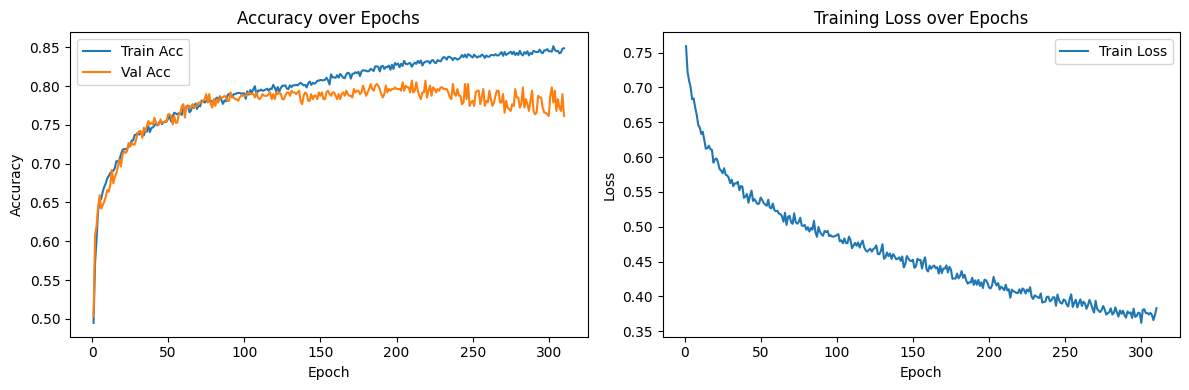


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  35%|███▍      | 346/1000 [47:02<1:28:55,  8.16s/it, Train Loss=0.4251, Train Acc=0.8106, Val Acc=0.7245, Val Kappa=0.4514, Best Val Kappa=0.4902 (Epoch 247), Best Val Acc=0.7440 (Epoch 247)]  


⏹️ Early stopping at epoch 347. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6944
📊 Final Test Cohen’s Kappa Score: 0.3889


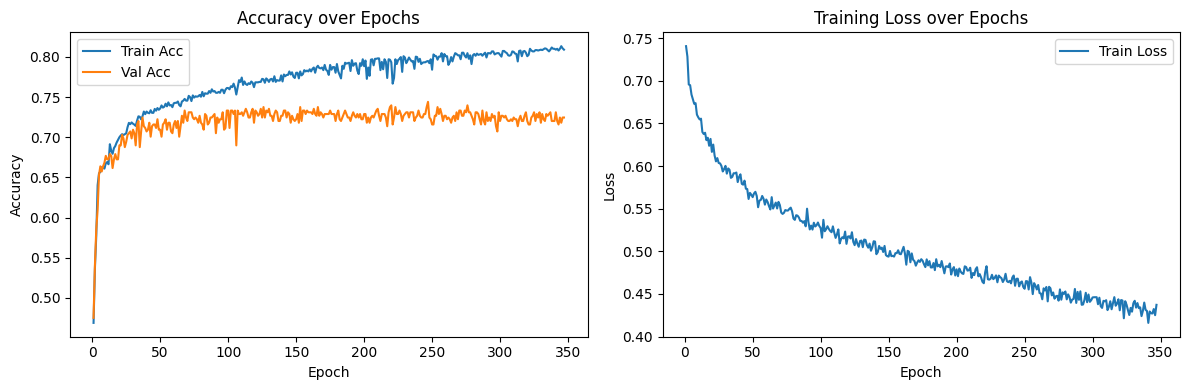


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  25%|██▌       | 251/1000 [40:25<2:00:36,  9.66s/it, Train Loss=0.4151, Train Acc=0.8231, Val Acc=0.7549, Val Kappa=0.5078, Best Val Kappa=0.5525 (Epoch 152), Best Val Acc=0.7766 (Epoch 152)]


⏹️ Early stopping at epoch 252. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6007
📊 Final Test Cohen’s Kappa Score: 0.2014


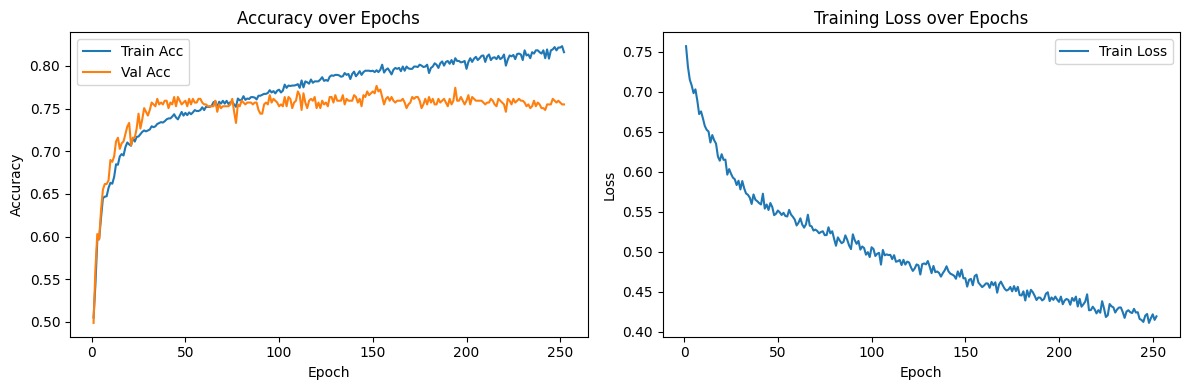


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  15%|█▍        | 147/1000 [20:32<1:59:13,  8.39s/it, Train Loss=0.4537, Train Acc=0.8275, Val Acc=0.7202, Val Kappa=0.4377, Best Val Kappa=0.4846 (Epoch 48), Best Val Acc=0.7440 (Epoch 48)]


⏹️ Early stopping at epoch 148. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5243
📊 Final Test Cohen’s Kappa Score: 0.0486


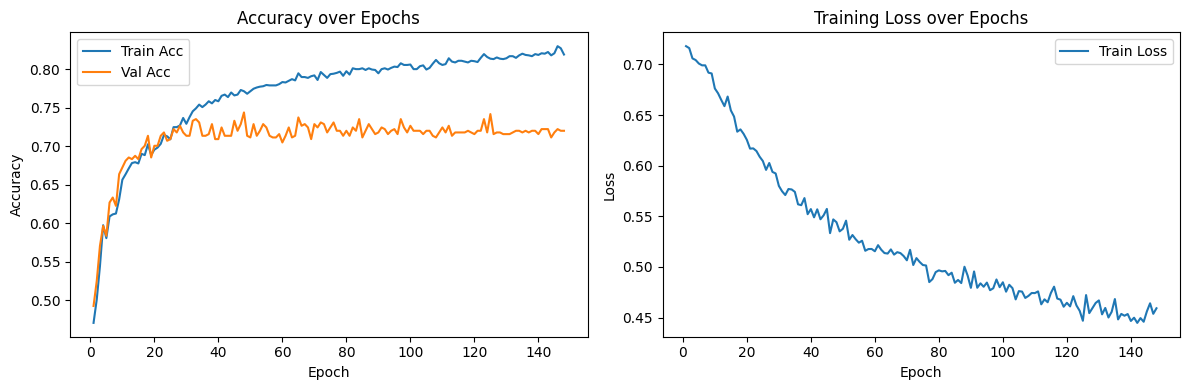


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  25%|██▌       | 251/1000 [1:28:06<4:22:54, 21.06s/it, Train Loss=0.4269, Train Acc=0.8155, Val Acc=0.6941, Val Kappa=0.3898, Best Val Kappa=0.4337 (Epoch 152), Best Val Acc=0.7180 (Epoch 152)]


⏹️ Early stopping at epoch 252. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208


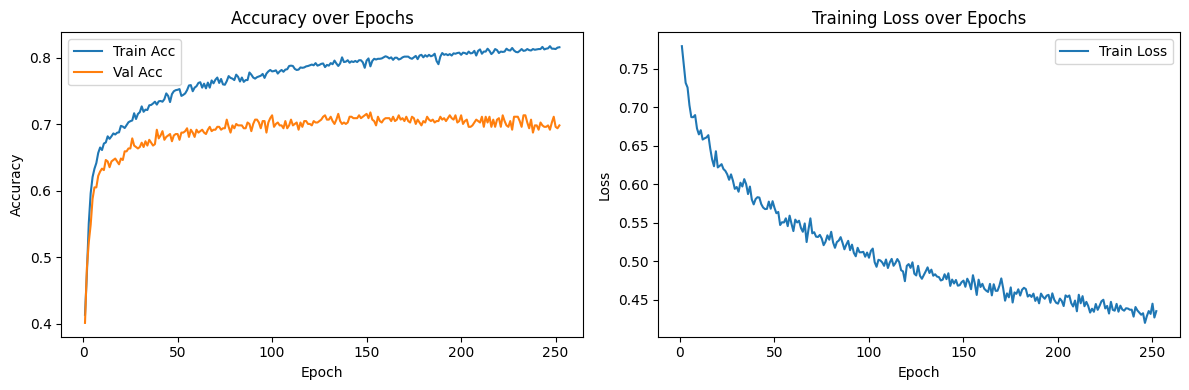


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  42%|████▏     | 424/1000 [8:05:46<10:59:54, 68.74s/it, Train Loss=0.3756, Train Acc=0.8258, Val Acc=0.7766, Val Kappa=0.5487, Best Val Kappa=0.5634 (Epoch 325), Best Val Acc=0.7831 (Epoch 325)]   


⏹️ Early stopping at epoch 425. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6285
📊 Final Test Cohen’s Kappa Score: 0.2569


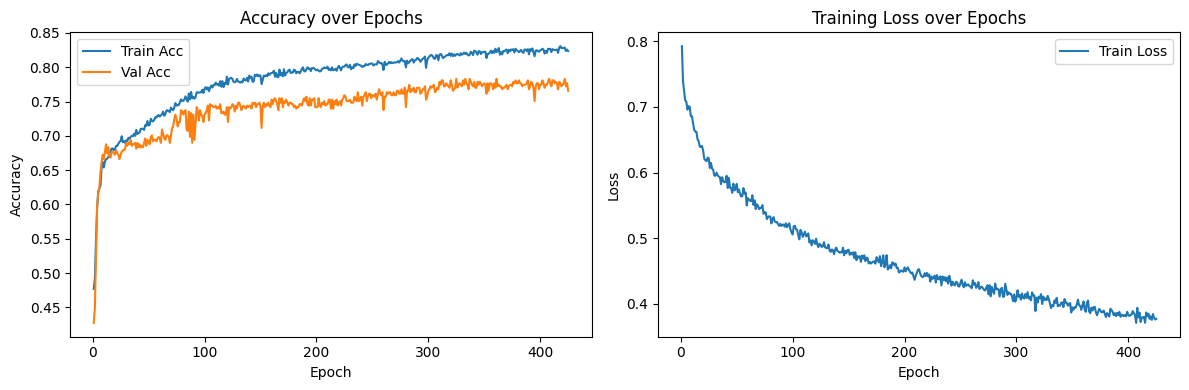


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  30%|██▉       | 295/1000 [19:54<47:33,  4.05s/it, Train Loss=0.4854, Train Acc=0.7602, Val Acc=0.6790, Val Kappa=0.3616, Best Val Kappa=0.4212 (Epoch 196), Best Val Acc=0.7115 (Epoch 196)]  


⏹️ Early stopping at epoch 296. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7674
📊 Final Test Cohen’s Kappa Score: 0.5347


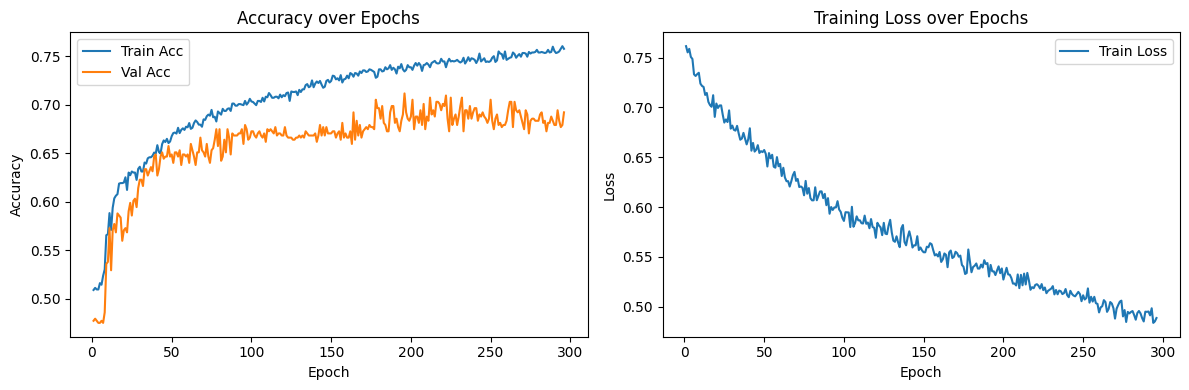


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▎       | 225/1000 [16:36<57:12,  4.43s/it, Train Loss=0.4357, Train Acc=0.8074, Val Acc=0.7245, Val Kappa=0.4500, Best Val Kappa=0.4822 (Epoch 126), Best Val Acc=0.7419 (Epoch 126)]  


⏹️ Early stopping at epoch 226. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7431
📊 Final Test Cohen’s Kappa Score: 0.4861


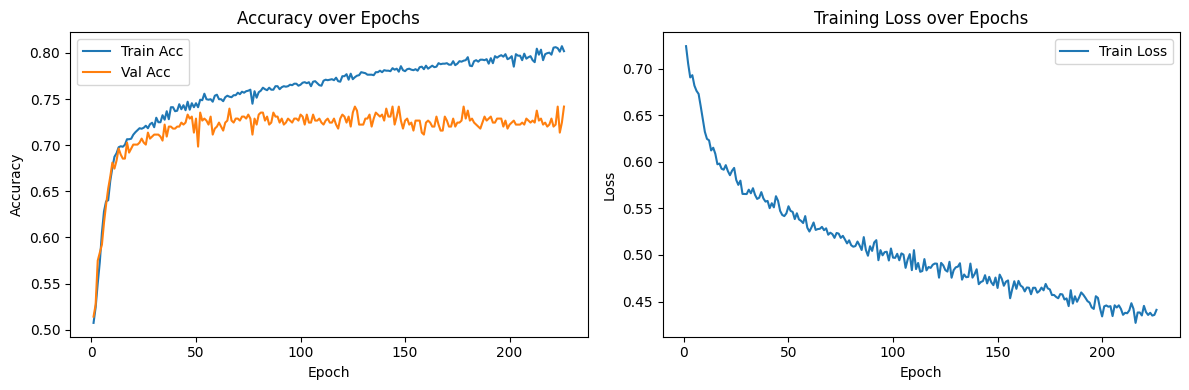

In [8]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [0, 1])
    test_mask = np.isin(test_labels, [0, 1])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask]

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)



=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  16%|█▌        | 161/1000 [15:02<1:18:24,  5.61s/it, Train Loss=0.5575, Train Acc=0.7401, Val Acc=0.6790, Val Kappa=0.3576, Best Val Kappa=0.3968 (Epoch 62), Best Val Acc=0.6985 (Epoch 62)]


⏹️ Early stopping at epoch 162. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5035
📊 Final Test Cohen’s Kappa Score: 0.0069


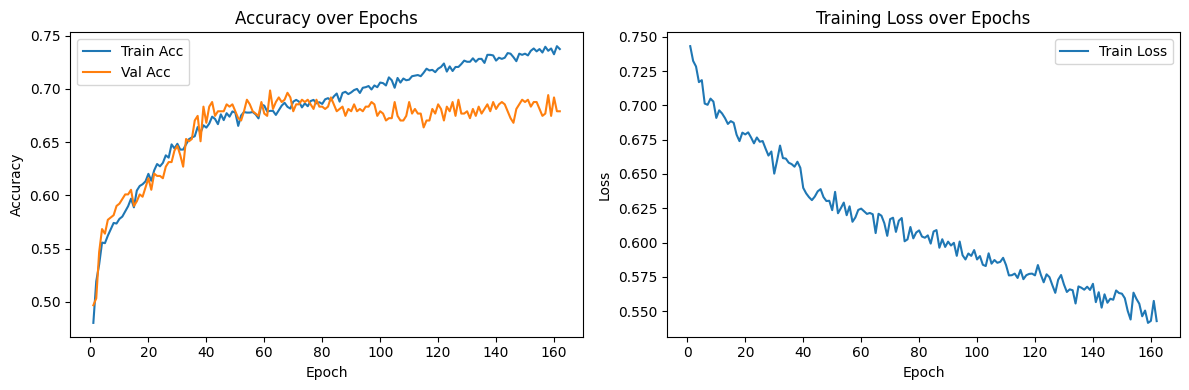


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  38%|███▊      | 376/1000 [29:34<49:05,  4.72s/it, Train Loss=0.4415, Train Acc=0.8209, Val Acc=0.7354, Val Kappa=0.4707, Best Val Kappa=0.4837 (Epoch 353), Best Val Acc=0.7419 (Epoch 353)]  


⏹️ Early stopping at epoch 377. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4653
📊 Final Test Cohen’s Kappa Score: -0.0694


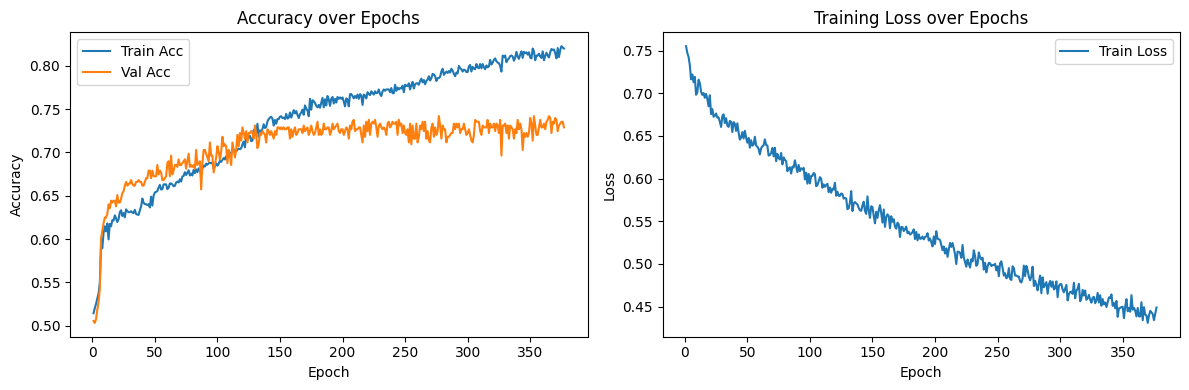


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  51%|█████     | 507/1000 [8:24:49<8:10:53, 59.74s/it, Train Loss=0.4347, Train Acc=0.7927, Val Acc=0.7267, Val Kappa=0.4463, Best Val Kappa=0.5207 (Epoch 408), Best Val Acc=0.7614 (Epoch 408)]    


⏹️ Early stopping at epoch 508. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5035
📊 Final Test Cohen’s Kappa Score: 0.0069


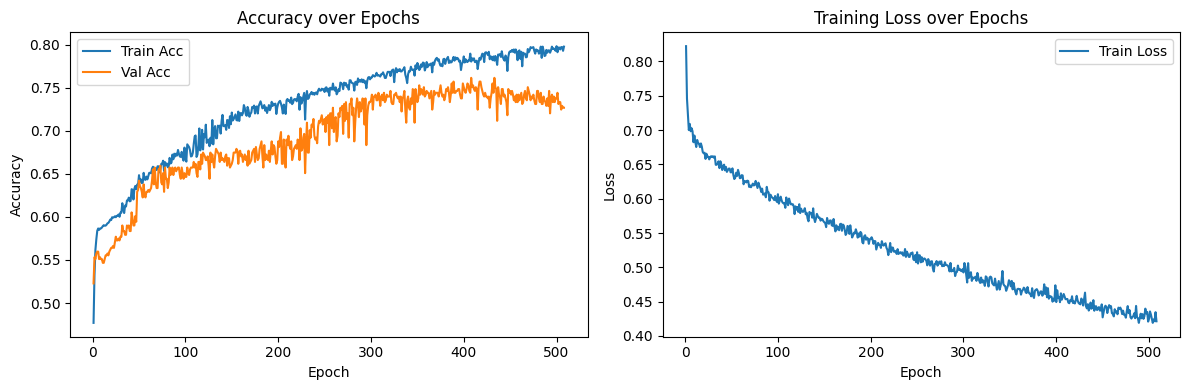


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  62%|██████▏   | 615/1000 [1:08:14<42:42,  6.66s/it, Train Loss=0.3537, Train Acc=0.8790, Val Acc=0.7267, Val Kappa=0.4533, Best Val Kappa=0.4966 (Epoch 516), Best Val Acc=0.7484 (Epoch 516)]  


⏹️ Early stopping at epoch 616. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4653
📊 Final Test Cohen’s Kappa Score: -0.0694


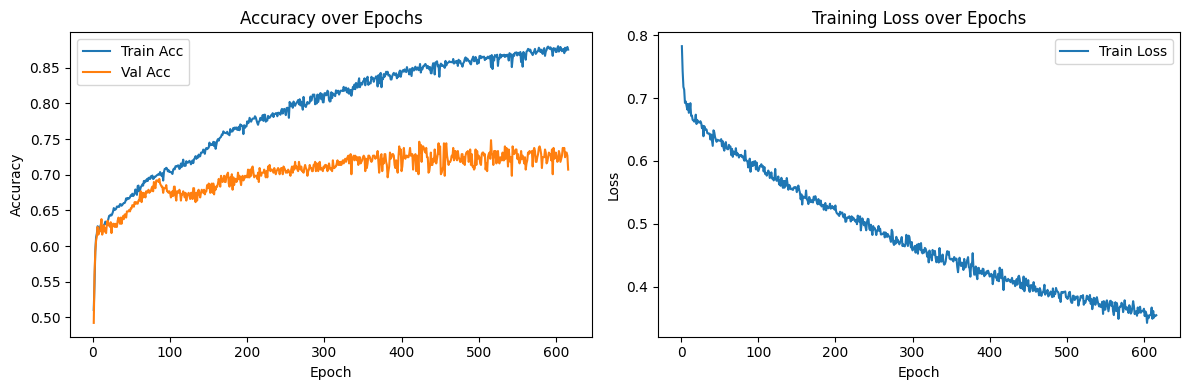


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2.1e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▏       | 220/1000 [13:11<46:45,  3.60s/it, Train Loss=0.5095, Train Acc=0.7813, Val Acc=0.6898, Val Kappa=0.3791, Best Val Kappa=0.4006 (Epoch 199), Best Val Acc=0.7007 (Epoch 199)]  


⏹️ Early stopping at epoch 221. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4965
📊 Final Test Cohen’s Kappa Score: -0.0069


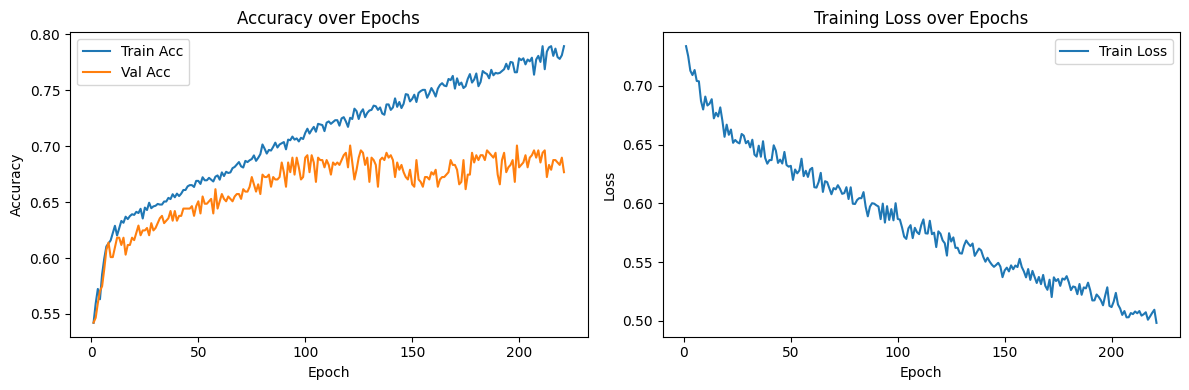


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  44%|████▎     | 437/1000 [32:20:32<41:40:03, 266.44s/it, Train Loss=0.4463, Train Acc=0.8003, Val Acc=0.7505, Val Kappa=0.5021, Best Val Kappa=0.5267 (Epoch 338), Best Val Acc=0.7636 (Epoch 338)]  


⏹️ Early stopping at epoch 438. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4618
📊 Final Test Cohen’s Kappa Score: -0.0764


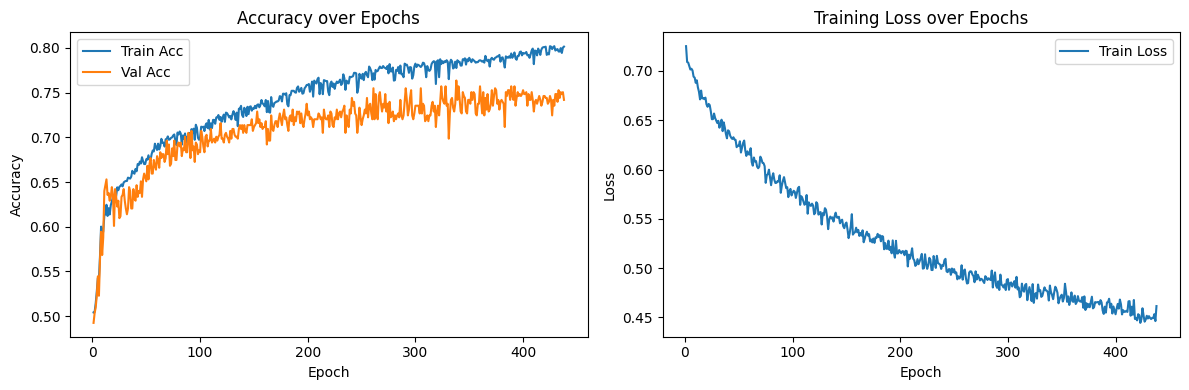


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  36%|███▌      | 357/1000 [24:58<44:59,  4.20s/it, Train Loss=0.4686, Train Acc=0.7895, Val Acc=0.6464, Val Kappa=0.2985, Best Val Kappa=0.3635 (Epoch 258), Best Val Acc=0.6790 (Epoch 258)]  


⏹️ Early stopping at epoch 358. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6528
📊 Final Test Cohen’s Kappa Score: 0.3056


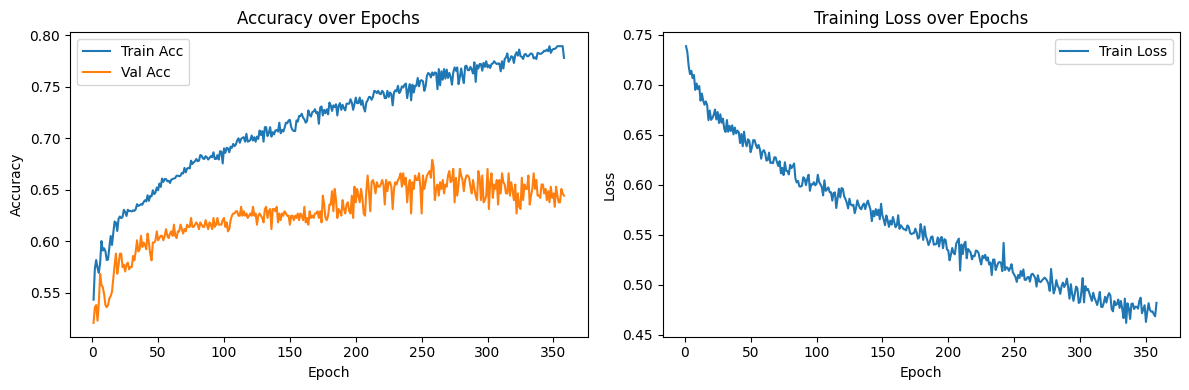


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  32%|███▏      | 322/1000 [1:30:51<3:11:18, 16.93s/it, Train Loss=0.5073, Train Acc=0.7298, Val Acc=0.6638, Val Kappa=0.3300, Best Val Kappa=0.3696 (Epoch 229), Best Val Acc=0.6833 (Epoch 229)]  


⏹️ Early stopping at epoch 323. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6250
📊 Final Test Cohen’s Kappa Score: 0.2500


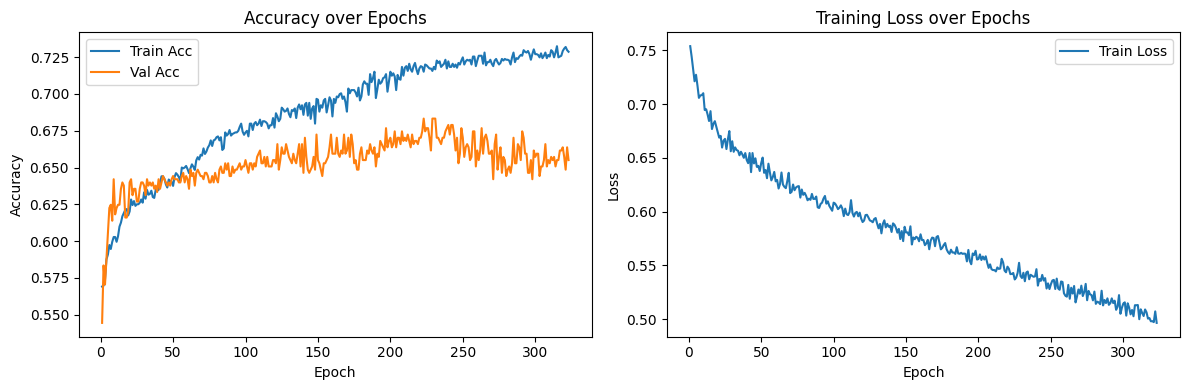


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_42358/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▏       | 220/1000 [51:08<3:01:20, 13.95s/it, Train Loss=0.4910, Train Acc=0.7906, Val Acc=0.6985, Val Kappa=0.3907, Best Val Kappa=0.4416 (Epoch 121), Best Val Acc=0.7223 (Epoch 121)]  


⏹️ Early stopping at epoch 221. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6458
📊 Final Test Cohen’s Kappa Score: 0.2917


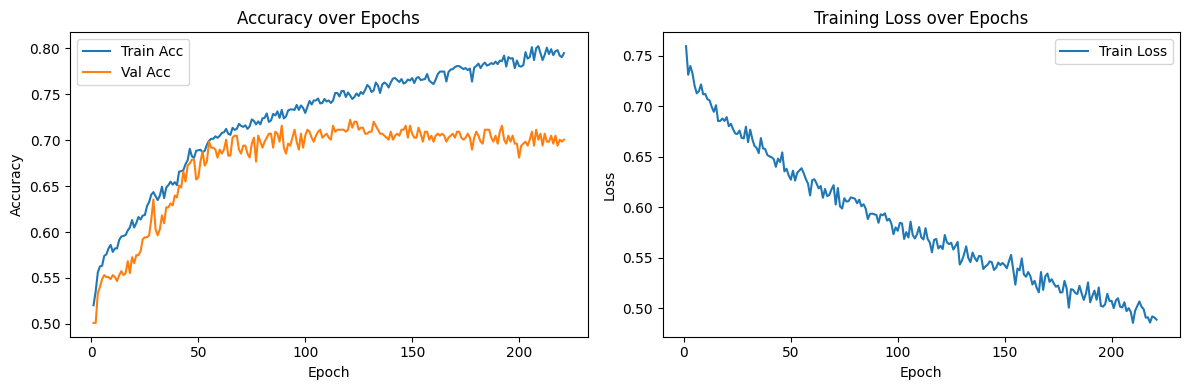

In [9]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [2, 3])
    test_mask = np.isin(test_labels, [2, 3])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask]-2

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]-2

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)


1-2


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▏       | 222/1000 [17:06<59:56,  4.62s/it, Train Loss=0.3981, Train Acc=0.8416, Val Acc=0.7484, Val Kappa=0.4976, Best Val Kappa=0.5498 (Epoch 123), Best Val Acc=0.7744 (Epoch 123)]


⏹️ Early stopping at epoch 223. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.8160
📊 Final Test Cohen’s Kappa Score: 0.6319

🔬 Classification Report for Test Set:


              precision    recall  f1-score   support

     Class 0       0.74      0.98      0.84       144
     Class 1       0.97      0.65      0.78       144

    accuracy                           0.82       288
   macro avg       0.85      0.82      0.81       288
weighted avg       0.85      0.82      0.81       288

🎯 Sensitivity (Recall for Class 1): 0.6528
🎯 Specificity: 0.9792


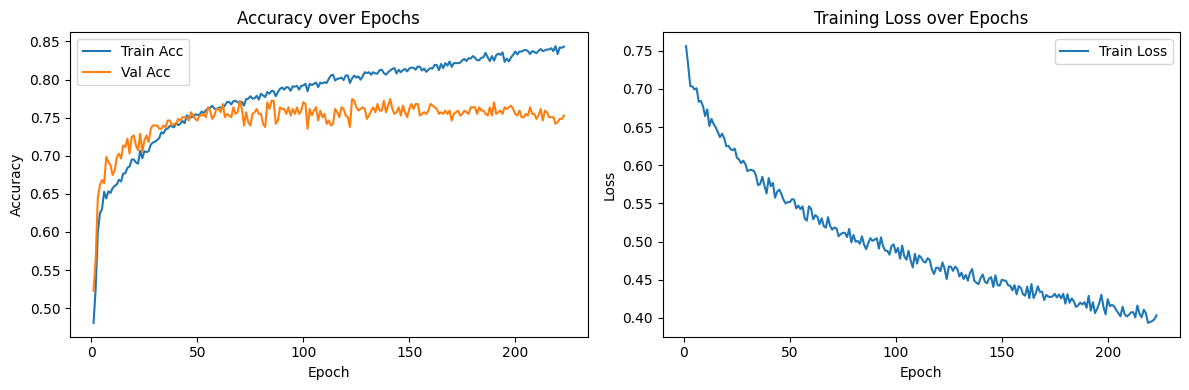


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  19%|█▉        | 188/1000 [12:58<56:01,  4.14s/it, Train Loss=0.3646, Train Acc=0.8606, Val Acc=0.7766, Val Kappa=0.5510, Best Val Kappa=0.5868 (Epoch 89), Best Val Acc=0.7939 (Epoch 89)]  


⏹️ Early stopping at epoch 189. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5556
📊 Final Test Cohen’s Kappa Score: 0.1111

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.53      0.87      0.66       144
     Class 1       0.65      0.24      0.35       144

    accuracy                           0.56       288
   macro avg       0.59      0.56      0.51       288
weighted avg       0.59      0.56      0.51       288

🎯 Sensitivity (Recall for Class 1): 0.2431
🎯 Specificity: 0.8681


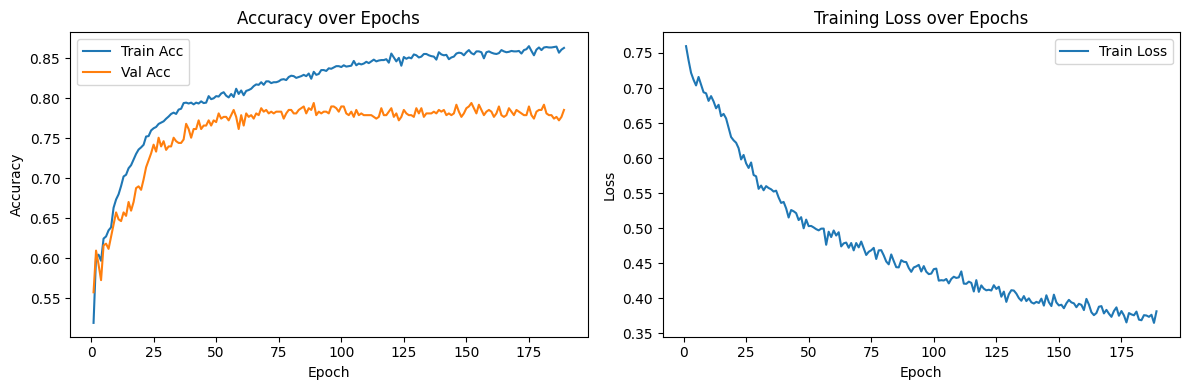


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  45%|████▌     | 452/1000 [30:42<37:13,  4.08s/it, Train Loss=0.3390, Train Acc=0.8844, Val Acc=0.8113, Val Kappa=0.6219, Best Val Kappa=0.6441 (Epoch 389), Best Val Acc=0.8221 (Epoch 389)]


⏹️ Early stopping at epoch 453. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6701
📊 Final Test Cohen’s Kappa Score: 0.3403

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       1.00      0.34      0.51       144
     Class 1       0.60      1.00      0.75       144

    accuracy                           0.67       288
   macro avg       0.80      0.67      0.63       288
weighted avg       0.80      0.67      0.63       288

🎯 Sensitivity (Recall for Class 1): 1.0000
🎯 Specificity: 0.3403


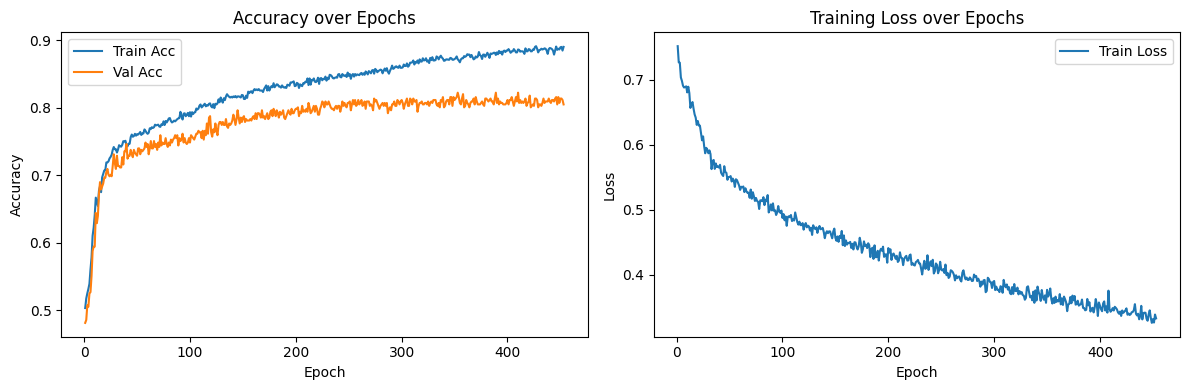


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  16%|█▋        | 163/1000 [11:32<59:14,  4.25s/it, Train Loss=0.4115, Train Acc=0.8508, Val Acc=0.7874, Val Kappa=0.5748, Best Val Kappa=0.5835 (Epoch 84), Best Val Acc=0.7918 (Epoch 84)]  


⏹️ Early stopping at epoch 164. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6389
📊 Final Test Cohen’s Kappa Score: 0.2778

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.59      0.94      0.72       144
     Class 1       0.84      0.34      0.49       144

    accuracy                           0.64       288
   macro avg       0.72      0.64      0.60       288
weighted avg       0.72      0.64      0.60       288

🎯 Sensitivity (Recall for Class 1): 0.3403
🎯 Specificity: 0.9375


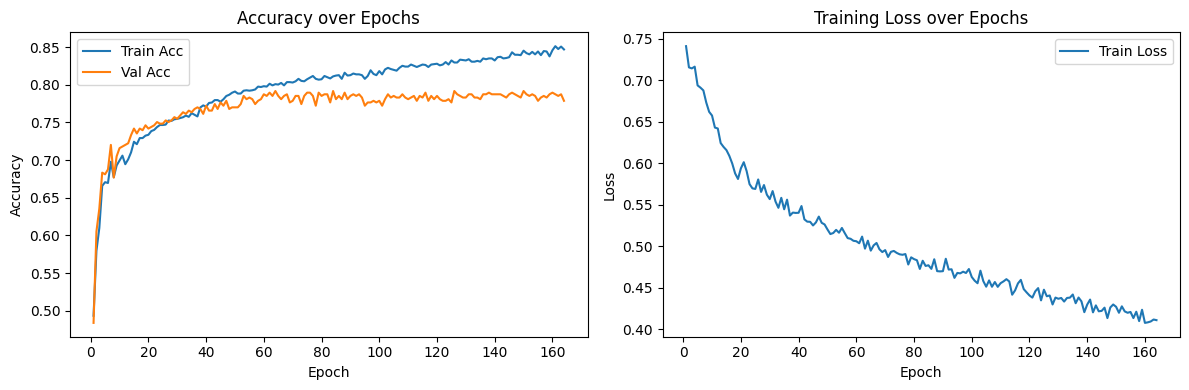


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  47%|████▋     | 471/1000 [31:05<34:55,  3.96s/it, Train Loss=0.2181, Train Acc=0.9479, Val Acc=0.8113, Val Kappa=0.6218, Best Val Kappa=0.6484 (Epoch 406), Best Val Acc=0.8243 (Epoch 406)]  


⏹️ Early stopping at epoch 472. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5208
📊 Final Test Cohen’s Kappa Score: 0.0417

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.51      0.96      0.67       144
     Class 1       0.67      0.08      0.15       144

    accuracy                           0.52       288
   macro avg       0.59      0.52      0.41       288
weighted avg       0.59      0.52      0.41       288

🎯 Sensitivity (Recall for Class 1): 0.0833
🎯 Specificity: 0.9583


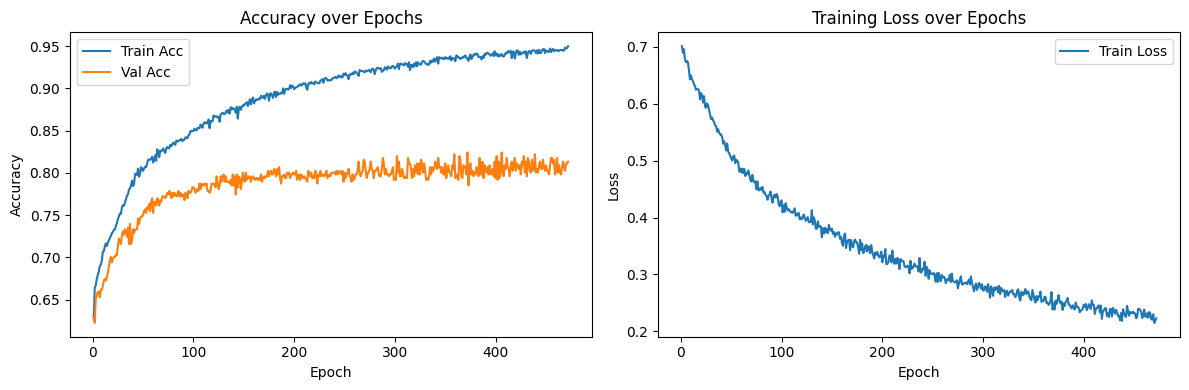


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  55%|█████▌    | 552/1000 [2:51:27<2:19:09, 18.64s/it, Train Loss=0.2597, Train Acc=0.8996, Val Acc=0.8004, Val Kappa=0.6009, Best Val Kappa=0.6442 (Epoch 453), Best Val Acc=0.8221 (Epoch 453)]    


⏹️ Early stopping at epoch 553. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4931
📊 Final Test Cohen’s Kappa Score: -0.0139

🔬 Classification Report for Test Set:


              precision    recall  f1-score   support

     Class 0       0.43      0.04      0.08       144
     Class 1       0.50      0.94      0.65       144

    accuracy                           0.49       288
   macro avg       0.46      0.49      0.36       288
weighted avg       0.46      0.49      0.36       288

🎯 Sensitivity (Recall for Class 1): 0.9444
🎯 Specificity: 0.0417


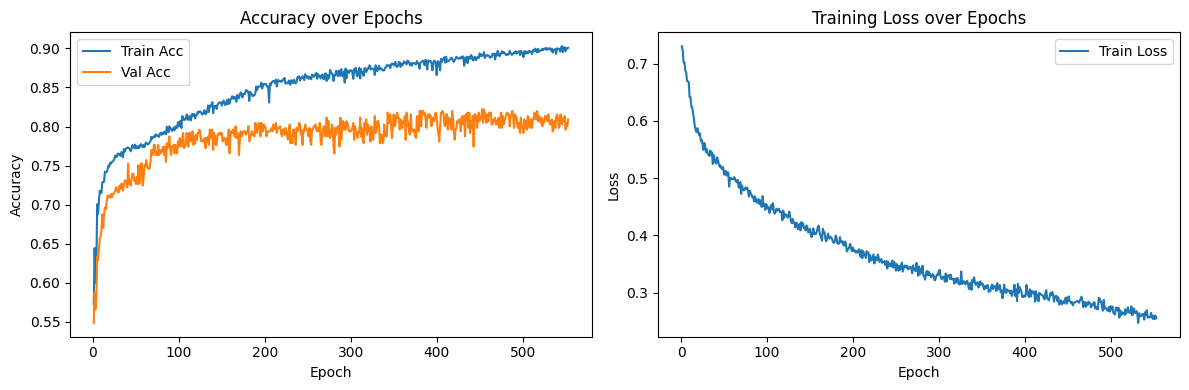


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  21%|██        | 208/1000 [19:23<1:13:51,  5.60s/it, Train Loss=0.3475, Train Acc=0.8627, Val Acc=0.7939, Val Kappa=0.5905, Best Val Kappa=0.6110 (Epoch 109), Best Val Acc=0.8069 (Epoch 109)]


⏹️ Early stopping at epoch 209. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5139
📊 Final Test Cohen’s Kappa Score: 0.0278

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.51      0.87      0.64       144
     Class 1       0.55      0.16      0.25       144

    accuracy                           0.51       288
   macro avg       0.53      0.51      0.44       288
weighted avg       0.53      0.51      0.44       288

🎯 Sensitivity (Recall for Class 1): 0.1597
🎯 Specificity: 0.8681


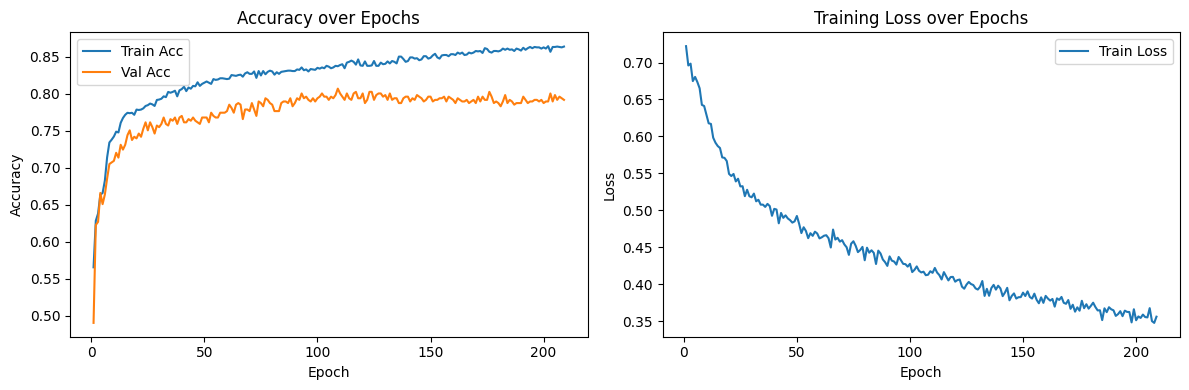


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  41%|████      | 409/1000 [28:25<41:04,  4.17s/it, Train Loss=0.2912, Train Acc=0.9099, Val Acc=0.8004, Val Kappa=0.6011, Best Val Kappa=0.6055 (Epoch 376), Best Val Acc=0.8026 (Epoch 376)]  


⏹️ Early stopping at epoch 410. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7396
📊 Final Test Cohen’s Kappa Score: 0.4792

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.71      0.81      0.76       144
     Class 1       0.78      0.67      0.72       144

    accuracy                           0.74       288
   macro avg       0.74      0.74      0.74       288
weighted avg       0.74      0.74      0.74       288

🎯 Sensitivity (Recall for Class 1): 0.6667
🎯 Specificity: 0.8125


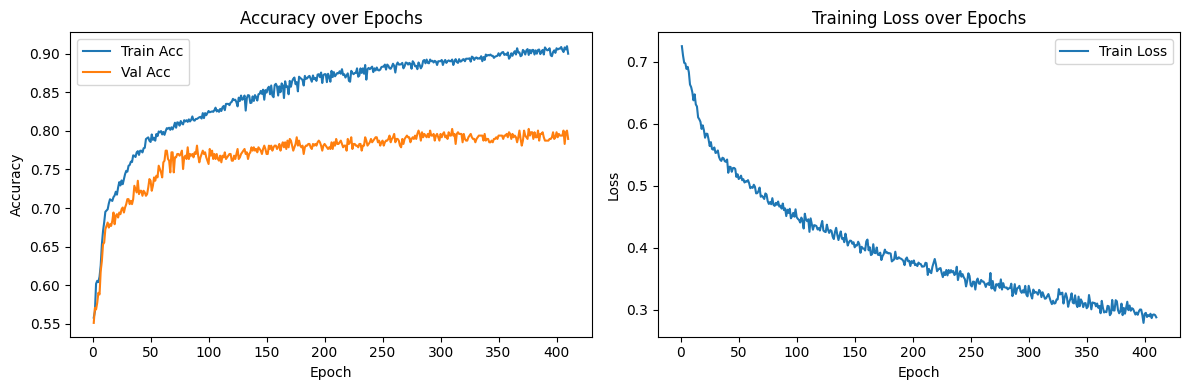


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  53%|█████▎    | 529/1000 [1:23:36<1:14:26,  9.48s/it, Train Loss=0.2305, Train Acc=0.9110, Val Acc=0.8069, Val Kappa=0.6141, Best Val Kappa=0.6357 (Epoch 430), Best Val Acc=0.8178 (Epoch 430)]


⏹️ Early stopping at epoch 530. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5521
📊 Final Test Cohen’s Kappa Score: 0.1042

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.67      0.20      0.31       144
     Class 1       0.53      0.90      0.67       144

    accuracy                           0.55       288
   macro avg       0.60      0.55      0.49       288
weighted avg       0.60      0.55      0.49       288

🎯 Sensitivity (Recall for Class 1): 0.9028
🎯 Specificity: 0.2014


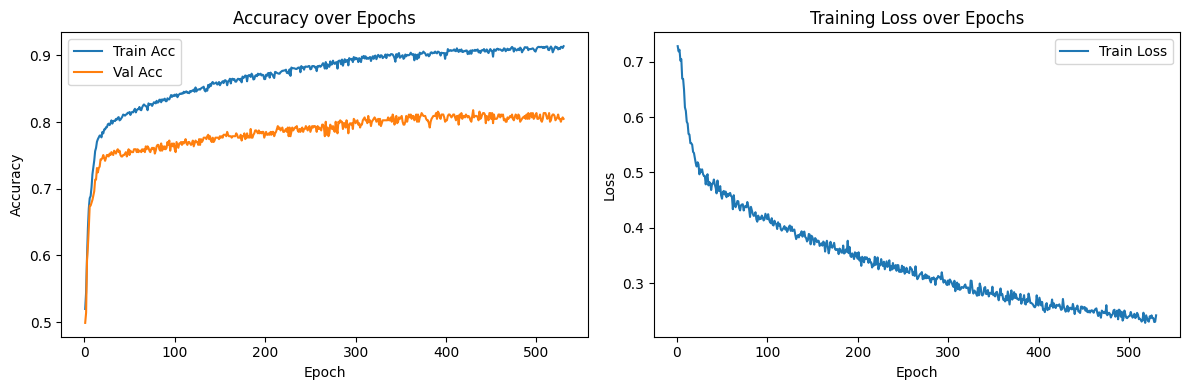

In [8]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [1, 2])
    test_mask = np.isin(test_labels, [1, 2])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask] - 1

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask] - 1

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    print(classification_report(final_labels, final_preds, target_names=['Class 0', 'Class 1']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    print(f"🎯 Sensitivity (Recall for Class 1): {sensitivity:.4f}")
    print(f"🎯 Specificity: {specificity:.4f}")

    # The classification_report already provides precision, recall (sensitivity), and F1-score for each class.
    # The 'recall' for Class 1 in the report is your sensitivity.
    # The 'recall' for Class 0 in the report is your specificity.

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

0-1


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  21%|██        | 211/1000 [17:22<1:04:59,  4.94s/it, Train Loss=0.4530, Train Acc=0.8020, Val Acc=0.7050, Val Kappa=0.4067, Best Val Kappa=0.4215 (Epoch 112), Best Val Acc=0.7115 (Epoch 112)]


⏹️ Early stopping at epoch 212. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6979
📊 Final Test Cohen’s Kappa Score: 0.3958

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.63      0.98      0.76       144
     Class 1       0.95      0.42      0.58       144

    accuracy                           0.70       288
   macro avg       0.79      0.70      0.67       288
weighted avg       0.79      0.70      0.67       288

🎯 Sensitivity (Recall for Class 1): 0.4167
🎯 Specificity: 0.9792


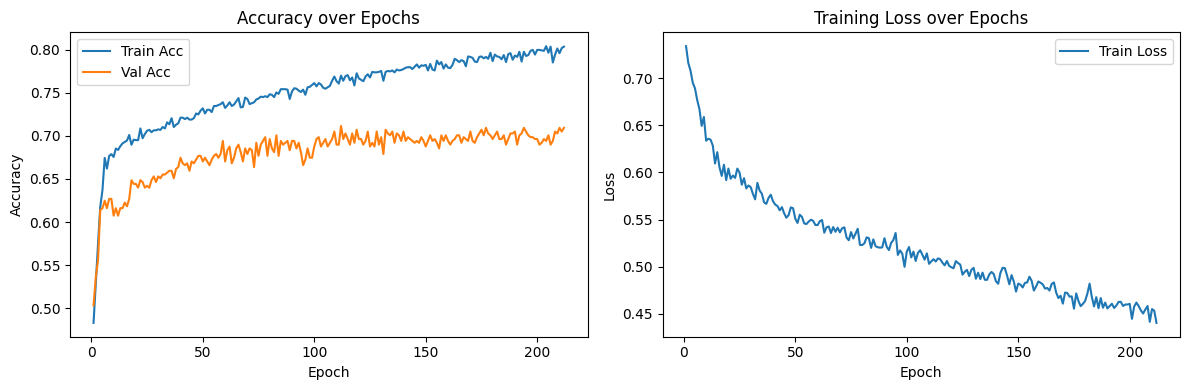


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▎       | 225/1000 [15:46<54:18,  4.20s/it, Train Loss=0.4121, Train Acc=0.8307, Val Acc=0.7549, Val Kappa=0.5099, Best Val Kappa=0.5792 (Epoch 126), Best Val Acc=0.7896 (Epoch 126)]  


⏹️ Early stopping at epoch 226. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5312
📊 Final Test Cohen’s Kappa Score: 0.0625

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.53      0.61      0.57       144
     Class 1       0.54      0.45      0.49       144

    accuracy                           0.53       288
   macro avg       0.53      0.53      0.53       288
weighted avg       0.53      0.53      0.53       288

🎯 Sensitivity (Recall for Class 1): 0.4514
🎯 Specificity: 0.6111


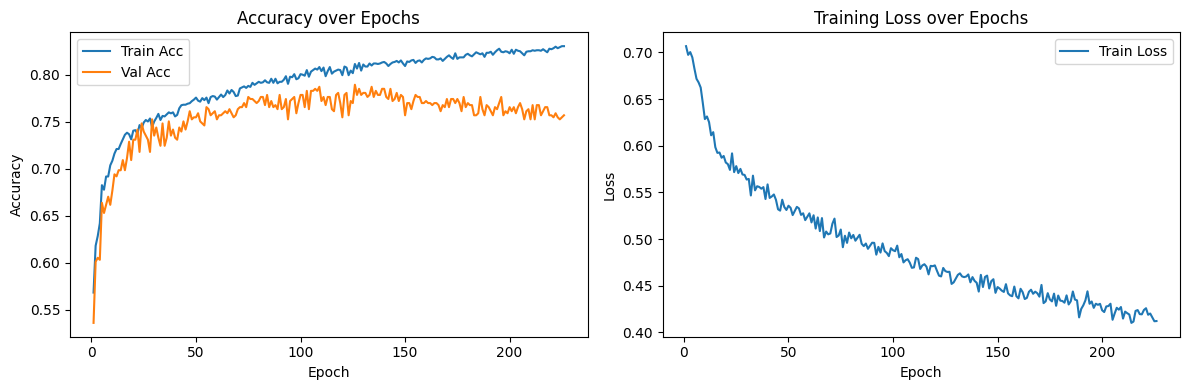


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  18%|█▊        | 183/1000 [15:14<1:08:01,  5.00s/it, Train Loss=0.4757, Train Acc=0.7748, Val Acc=0.6876, Val Kappa=0.3754, Best Val Kappa=0.4485 (Epoch 95), Best Val Acc=0.7245 (Epoch 95)]


⏹️ Early stopping at epoch 184. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6562
📊 Final Test Cohen’s Kappa Score: 0.3125

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.59      1.00      0.74       144
     Class 1       1.00      0.31      0.48       144

    accuracy                           0.66       288
   macro avg       0.80      0.66      0.61       288
weighted avg       0.80      0.66      0.61       288

🎯 Sensitivity (Recall for Class 1): 0.3125
🎯 Specificity: 1.0000


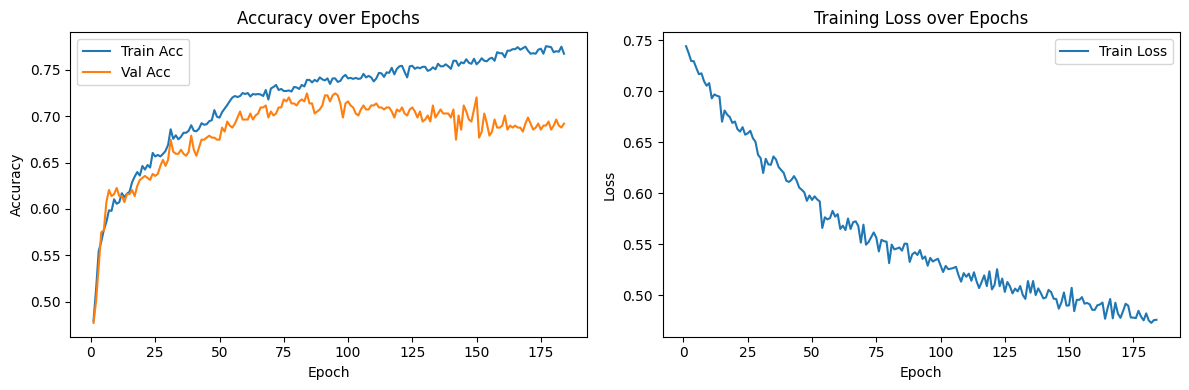


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  47%|████▋     | 473/1000 [1:32:48<1:43:24, 11.77s/it, Train Loss=0.3789, Train Acc=0.8253, Val Acc=0.7289, Val Kappa=0.4595, Best Val Kappa=0.5128 (Epoch 374), Best Val Acc=0.7549 (Epoch 374)]   


⏹️ Early stopping at epoch 474. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5347
📊 Final Test Cohen’s Kappa Score: 0.0694

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.86      0.08      0.15       144
     Class 1       0.52      0.99      0.68       144

    accuracy                           0.53       288
   macro avg       0.69      0.53      0.42       288
weighted avg       0.69      0.53      0.42       288

🎯 Sensitivity (Recall for Class 1): 0.9861
🎯 Specificity: 0.0833


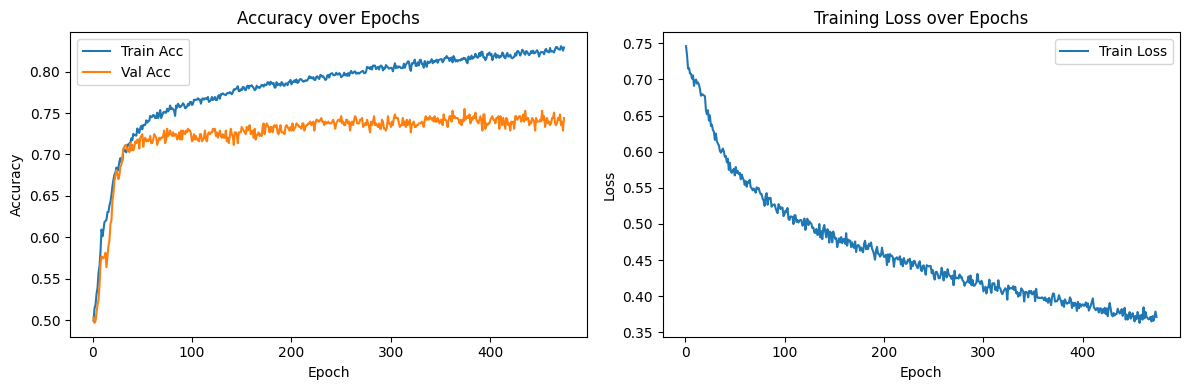


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  34%|███▍      | 341/1000 [46:13<1:29:20,  8.13s/it, Train Loss=0.4129, Train Acc=0.8454, Val Acc=0.7657, Val Kappa=0.5307, Best Val Kappa=0.5402 (Epoch 242), Best Val Acc=0.7701 (Epoch 242)]  


⏹️ Early stopping at epoch 342. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5278
📊 Final Test Cohen’s Kappa Score: 0.0556

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.52      0.60      0.56       144
     Class 1       0.53      0.46      0.49       144

    accuracy                           0.53       288
   macro avg       0.53      0.53      0.53       288
weighted avg       0.53      0.53      0.53       288

🎯 Sensitivity (Recall for Class 1): 0.4583
🎯 Specificity: 0.5972


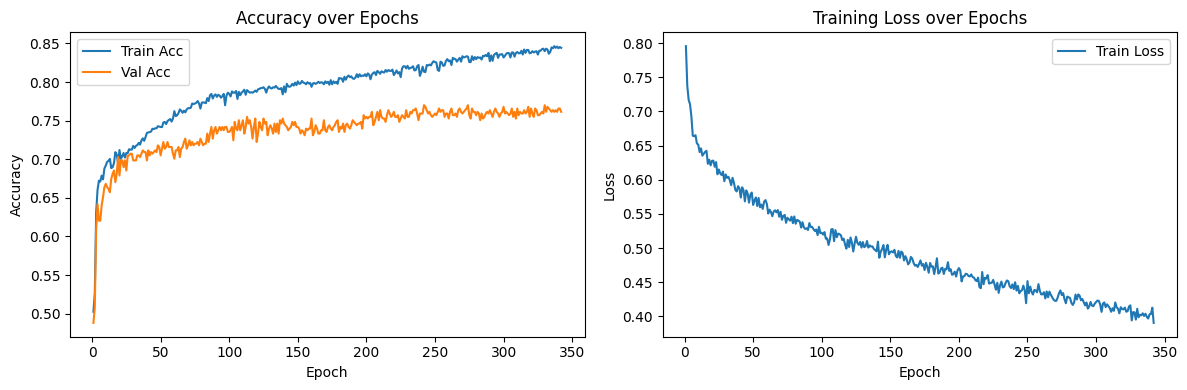


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  27%|██▋       | 266/1000 [4:46:53<13:11:39, 64.71s/it, Train Loss=0.4169, Train Acc=0.8090, Val Acc=0.7592, Val Kappa=0.5183, Best Val Kappa=0.5643 (Epoch 167), Best Val Acc=0.7831 (Epoch 167)] 


⏹️ Early stopping at epoch 267. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4757
📊 Final Test Cohen’s Kappa Score: -0.0486

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.46      0.26      0.33       144
     Class 1       0.48      0.69      0.57       144

    accuracy                           0.48       288
   macro avg       0.47      0.48      0.45       288
weighted avg       0.47      0.48      0.45       288

🎯 Sensitivity (Recall for Class 1): 0.6875
🎯 Specificity: 0.2639


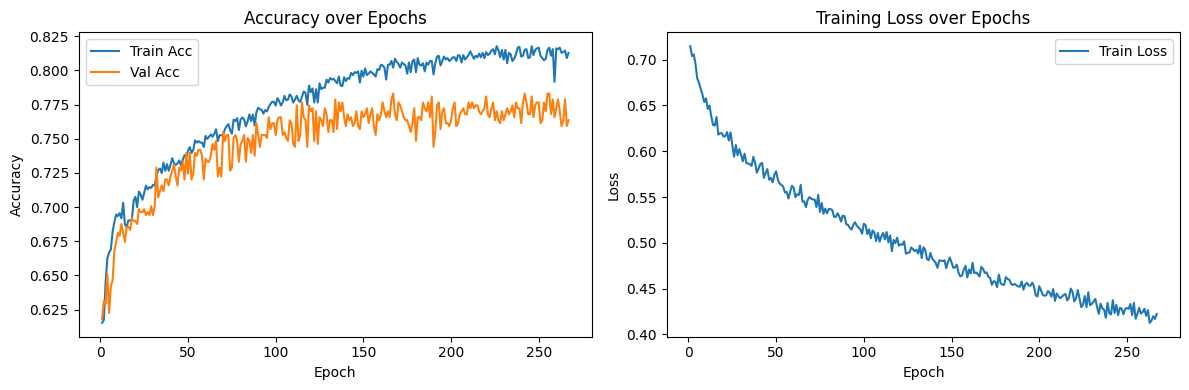


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  31%|███▏      | 314/1000 [26:01<56:50,  4.97s/it, Train Loss=0.4131, Train Acc=0.8242, Val Acc=0.7310, Val Kappa=0.4599, Best Val Kappa=0.4824 (Epoch 241), Best Val Acc=0.7419 (Epoch 241)]  


⏹️ Early stopping at epoch 315. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6562
📊 Final Test Cohen’s Kappa Score: 0.3125

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.69      0.57      0.62       144
     Class 1       0.63      0.74      0.68       144

    accuracy                           0.66       288
   macro avg       0.66      0.66      0.65       288
weighted avg       0.66      0.66      0.65       288

🎯 Sensitivity (Recall for Class 1): 0.7431
🎯 Specificity: 0.5694


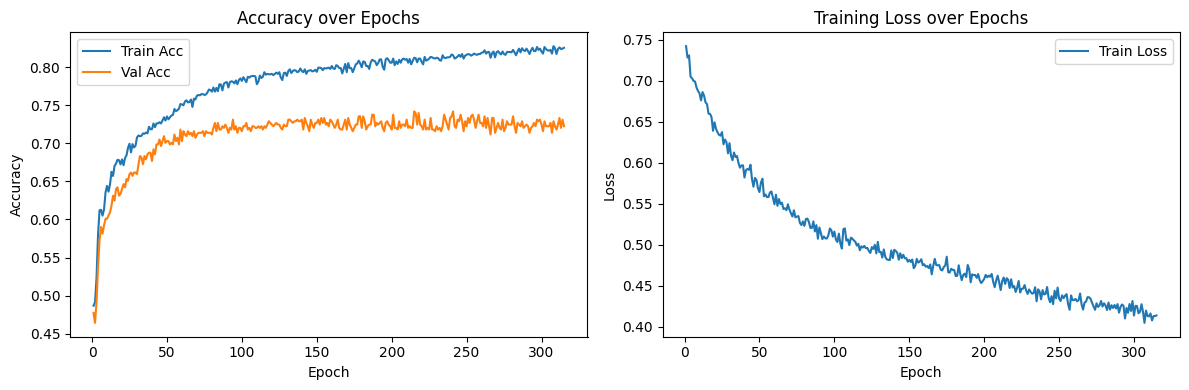


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▏       | 219/1000 [17:01<1:00:43,  4.67s/it, Train Loss=0.5037, Train Acc=0.7482, Val Acc=0.6833, Val Kappa=0.3696, Best Val Kappa=0.4046 (Epoch 129), Best Val Acc=0.7028 (Epoch 129)]


⏹️ Early stopping at epoch 220. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.9271
📊 Final Test Cohen’s Kappa Score: 0.8542

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.92      0.93      0.93       144
     Class 1       0.93      0.92      0.93       144

    accuracy                           0.93       288
   macro avg       0.93      0.93      0.93       288
weighted avg       0.93      0.93      0.93       288

🎯 Sensitivity (Recall for Class 1): 0.9236
🎯 Specificity: 0.9306


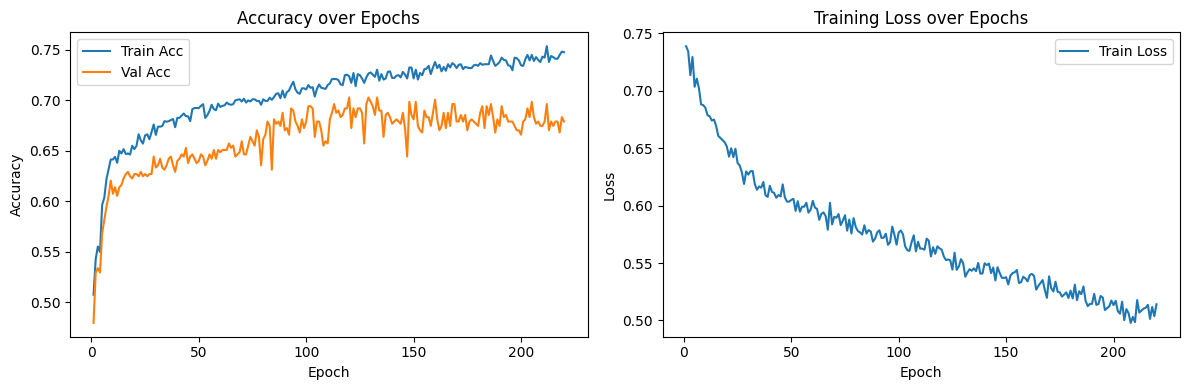


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  28%|██▊       | 280/1000 [21:08<54:22,  4.53s/it, Train Loss=0.4047, Train Acc=0.7987, Val Acc=0.7245, Val Kappa=0.4449, Best Val Kappa=0.4739 (Epoch 181), Best Val Acc=0.7397 (Epoch 181)]  


⏹️ Early stopping at epoch 281. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7708
📊 Final Test Cohen’s Kappa Score: 0.5417

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.93      0.58      0.72       144
     Class 1       0.70      0.96      0.81       144

    accuracy                           0.77       288
   macro avg       0.82      0.77      0.76       288
weighted avg       0.82      0.77      0.76       288

🎯 Sensitivity (Recall for Class 1): 0.9583
🎯 Specificity: 0.5833


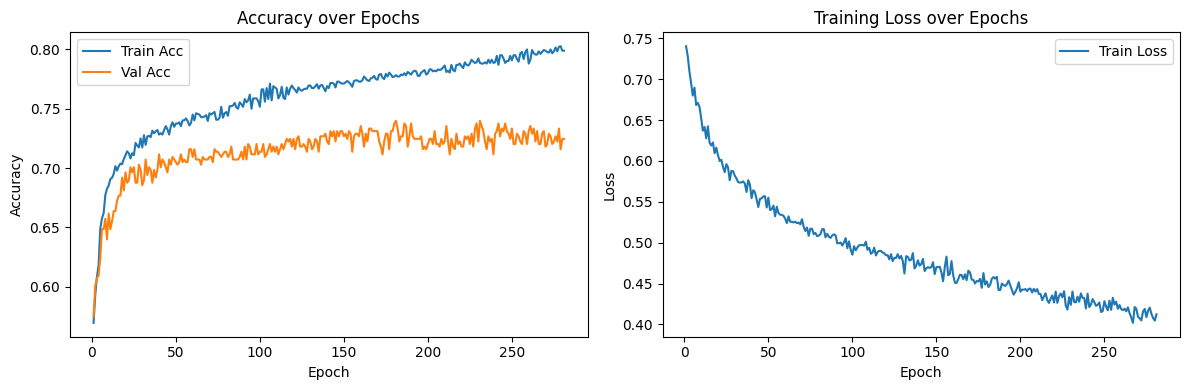

In [ ]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [0, 1])
    test_mask = np.isin(test_labels, [0, 1])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask]

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    print(classification_report(final_labels, final_preds, target_names=['Class 0', 'Class 1']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    print(f"🎯 Sensitivity (Recall for Class 1): {sensitivity:.4f}")
    print(f"🎯 Specificity: {specificity:.4f}")

    # The classification_report already provides precision, recall (sensitivity), and F1-score for each class.
    # The 'recall' for Class 1 in the report is your sensitivity.
    # The 'recall' for Class 0 in the report is your specificity.

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

2-3


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  44%|████▎     | 437/1000 [31:07<40:05,  4.27s/it, Train Loss=0.4353, Train Acc=0.8101, Val Acc=0.7050, Val Kappa=0.4092, Best Val Kappa=0.4662 (Epoch 338), Best Val Acc=0.7332 (Epoch 338)]  


⏹️ Early stopping at epoch 438. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4965
📊 Final Test Cohen’s Kappa Score: -0.0069

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.50      0.99      0.66       144
     Class 1       0.33      0.01      0.01       144

    accuracy                           0.50       288
   macro avg       0.42      0.50      0.34       288
weighted avg       0.42      0.50      0.34       288

🎯 Sensitivity (Recall for Class 1): 0.0069
🎯 Specificity: 0.9861


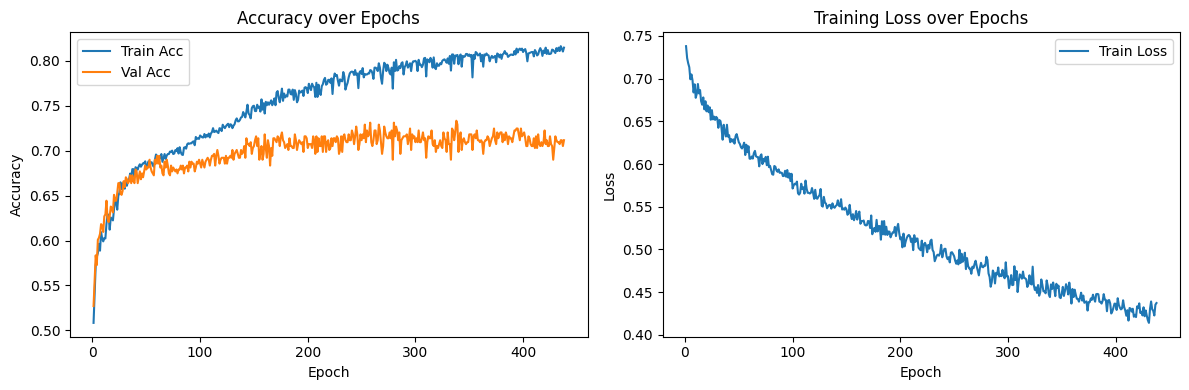


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  26%|██▌       | 259/1000 [1:38:03<4:40:32, 22.72s/it, Train Loss=0.4801, Train Acc=0.7949, Val Acc=0.6616, Val Kappa=0.3318, Best Val Kappa=0.3927 (Epoch 189), Best Val Acc=0.6920 (Epoch 189)]


⏹️ Early stopping at epoch 260. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5382
📊 Final Test Cohen’s Kappa Score: 0.0764

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.53      0.75      0.62       144
     Class 1       0.57      0.33      0.41       144

    accuracy                           0.54       288
   macro avg       0.55      0.54      0.52       288
weighted avg       0.55      0.54      0.52       288

🎯 Sensitivity (Recall for Class 1): 0.3264
🎯 Specificity: 0.7500


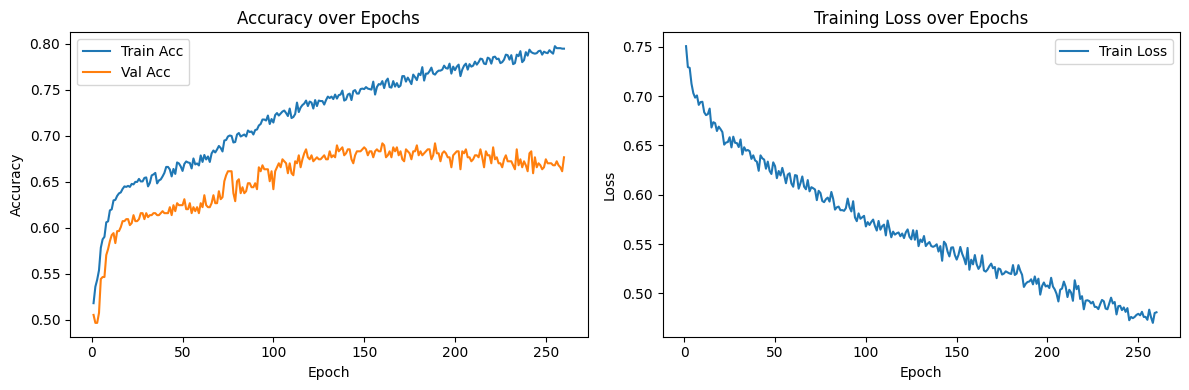


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  20%|██        | 201/1000 [13:24<53:19,  4.00s/it, Train Loss=0.5546, Train Acc=0.7401, Val Acc=0.6920, Val Kappa=0.3841, Best Val Kappa=0.3880 (Epoch 102), Best Val Acc=0.6941 (Epoch 102)]  


⏹️ Early stopping at epoch 202. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4618
📊 Final Test Cohen’s Kappa Score: -0.0764

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.47      0.56      0.51       144
     Class 1       0.45      0.37      0.41       144

    accuracy                           0.46       288
   macro avg       0.46      0.46      0.46       288
weighted avg       0.46      0.46      0.46       288

🎯 Sensitivity (Recall for Class 1): 0.3681
🎯 Specificity: 0.5556


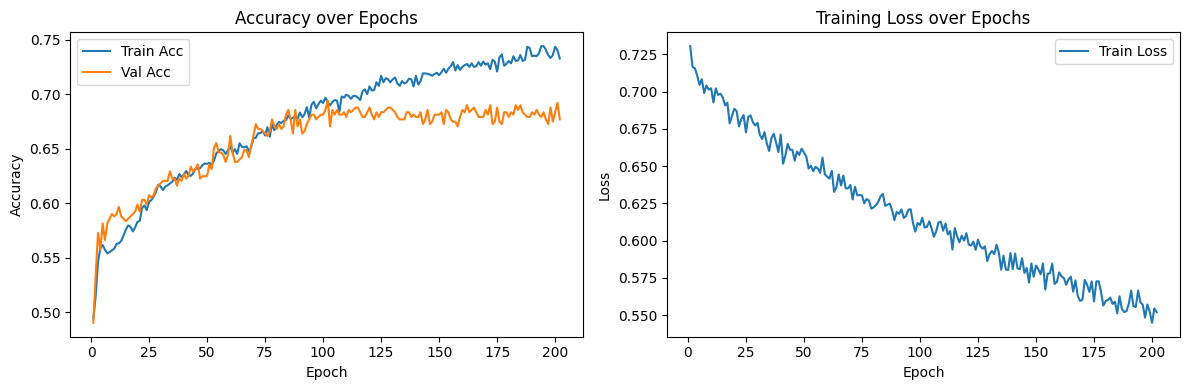


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  50%|████▉     | 498/1000 [16:36:04<16:44:04, 120.01s/it, Train Loss=0.4333, Train Acc=0.8101, Val Acc=0.7050, Val Kappa=0.4099, Best Val Kappa=0.4234 (Epoch 399), Best Val Acc=0.7115 (Epoch 399)] 


⏹️ Early stopping at epoch 499. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4722
📊 Final Test Cohen’s Kappa Score: -0.0556

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.44      0.20      0.28       144
     Class 1       0.48      0.74      0.58       144

    accuracy                           0.47       288
   macro avg       0.46      0.47      0.43       288
weighted avg       0.46      0.47      0.43       288

🎯 Sensitivity (Recall for Class 1): 0.7431
🎯 Specificity: 0.2014


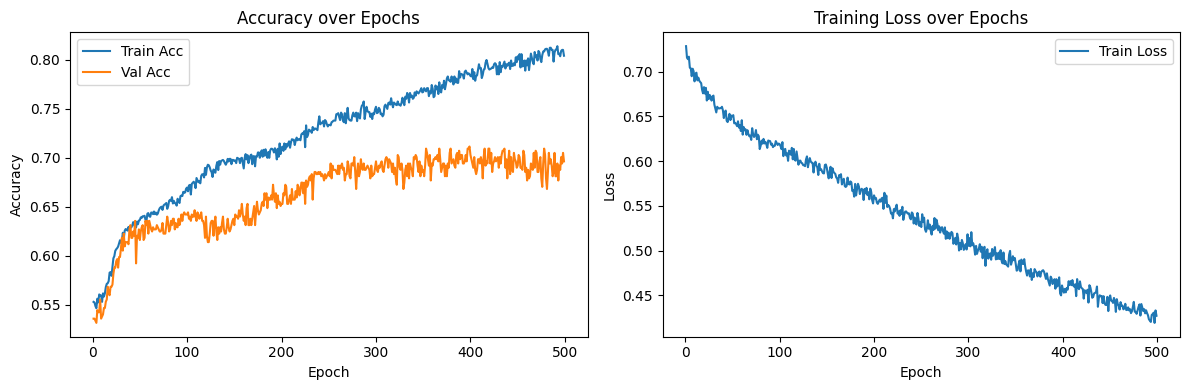


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2.1e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  36%|███▋      | 365/1000 [42:00<1:13:05,  6.91s/it, Train Loss=0.4242, Train Acc=0.8269, Val Acc=0.7028, Val Kappa=0.4056, Best Val Kappa=0.4279 (Epoch 270), Best Val Acc=0.7115 (Epoch 270)]  


⏹️ Early stopping at epoch 366. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4965
📊 Final Test Cohen’s Kappa Score: -0.0069

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.50      0.79      0.61       144
     Class 1       0.49      0.20      0.29       144

    accuracy                           0.50       288
   macro avg       0.49      0.50      0.45       288
weighted avg       0.49      0.50      0.45       288

🎯 Sensitivity (Recall for Class 1): 0.2014
🎯 Specificity: 0.7917


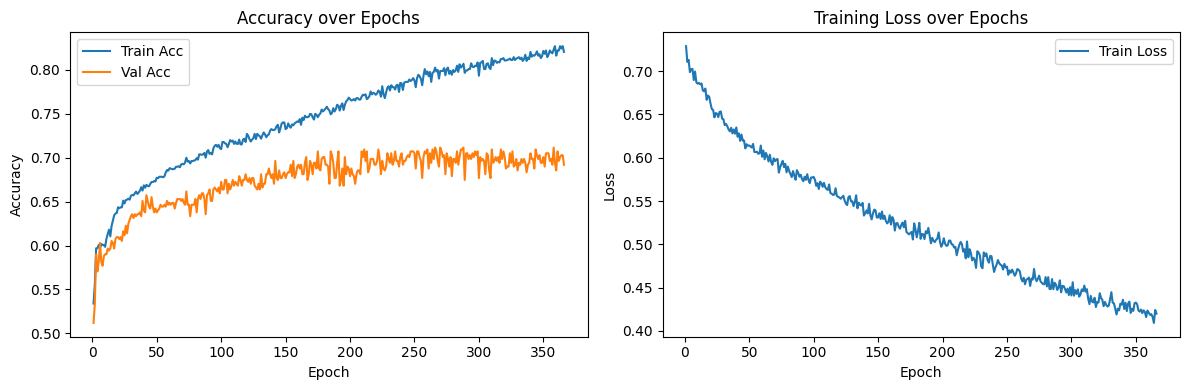


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  32%|███▏      | 323/1000 [25:13<52:52,  4.69s/it, Train Loss=0.4617, Train Acc=0.7868, Val Acc=0.6898, Val Kappa=0.3812, Best Val Kappa=0.4051 (Epoch 224), Best Val Acc=0.7028 (Epoch 224)]  


⏹️ Early stopping at epoch 324. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4688
📊 Final Test Cohen’s Kappa Score: -0.0625

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.48      0.92      0.63       144
     Class 1       0.15      0.01      0.03       144

    accuracy                           0.47       288
   macro avg       0.32      0.47      0.33       288
weighted avg       0.32      0.47      0.33       288

🎯 Sensitivity (Recall for Class 1): 0.0139
🎯 Specificity: 0.9236


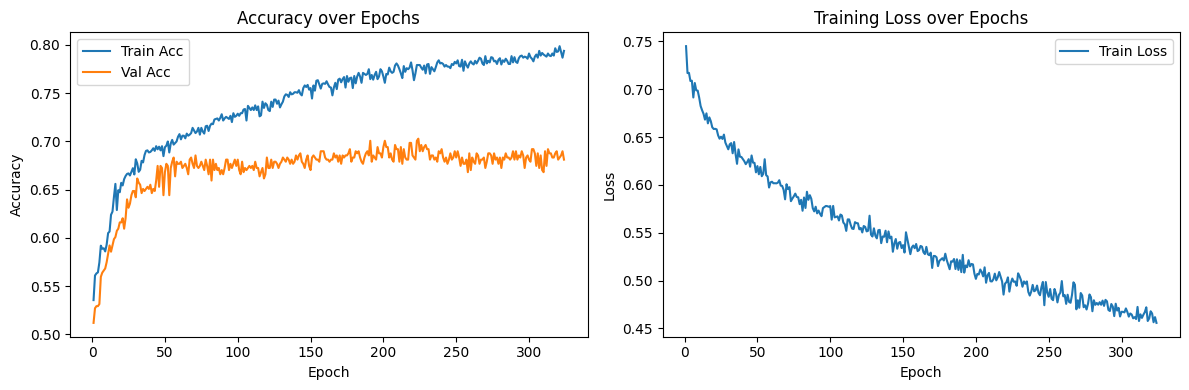


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  16%|█▌        | 158/1000 [10:51<57:52,  4.12s/it, Train Loss=0.5764, Train Acc=0.6918, Val Acc=0.6161, Val Kappa=0.2399, Best Val Kappa=0.2907 (Epoch 59), Best Val Acc=0.6443 (Epoch 59)]  


⏹️ Early stopping at epoch 159. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5174
📊 Final Test Cohen’s Kappa Score: 0.0347

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.56      0.15      0.24       144
     Class 1       0.51      0.88      0.65       144

    accuracy                           0.52       288
   macro avg       0.54      0.52      0.44       288
weighted avg       0.54      0.52      0.44       288

🎯 Sensitivity (Recall for Class 1): 0.8819
🎯 Specificity: 0.1528


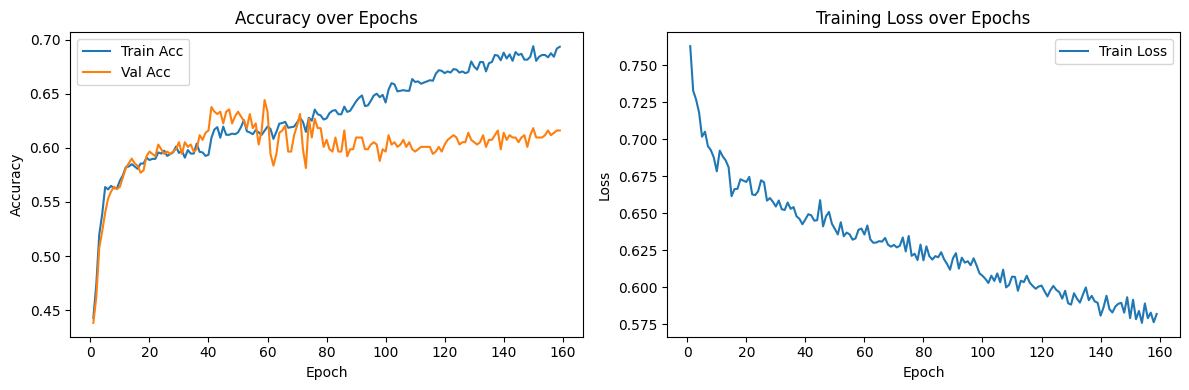


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  38%|███▊      | 380/1000 [22:04<36:01,  3.49s/it, Train Loss=0.5032, Train Acc=0.7786, Val Acc=0.6616, Val Kappa=0.3207, Best Val Kappa=0.3527 (Epoch 281), Best Val Acc=0.6768 (Epoch 281)]


⏹️ Early stopping at epoch 381. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5312
📊 Final Test Cohen’s Kappa Score: 0.0625

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.55      0.33      0.41       144
     Class 1       0.52      0.74      0.61       144

    accuracy                           0.53       288
   macro avg       0.54      0.53      0.51       288
weighted avg       0.54      0.53      0.51       288

🎯 Sensitivity (Recall for Class 1): 0.7361
🎯 Specificity: 0.3264


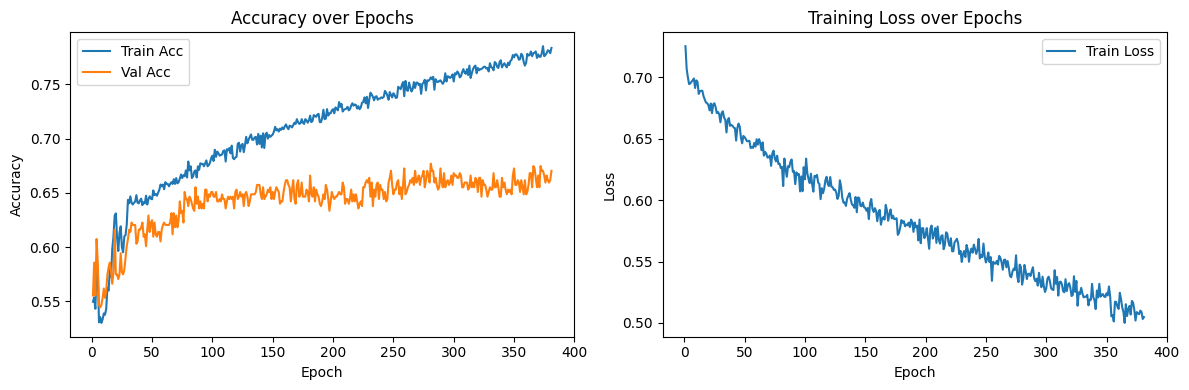


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_2204/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  62%|██████▏   | 615/1000 [3:41:07<2:18:25, 21.57s/it, Train Loss=0.3910, Train Acc=0.8318, Val Acc=0.7028, Val Kappa=0.4061, Best Val Kappa=0.4280 (Epoch 516), Best Val Acc=0.7137 (Epoch 516)]   


⏹️ Early stopping at epoch 616. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6771
📊 Final Test Cohen’s Kappa Score: 0.3542

🔬 Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.98      0.36      0.53       144
     Class 1       0.61      0.99      0.75       144

    accuracy                           0.68       288
   macro avg       0.79      0.68      0.64       288
weighted avg       0.79      0.68      0.64       288

🎯 Sensitivity (Recall for Class 1): 0.9931
🎯 Specificity: 0.3611


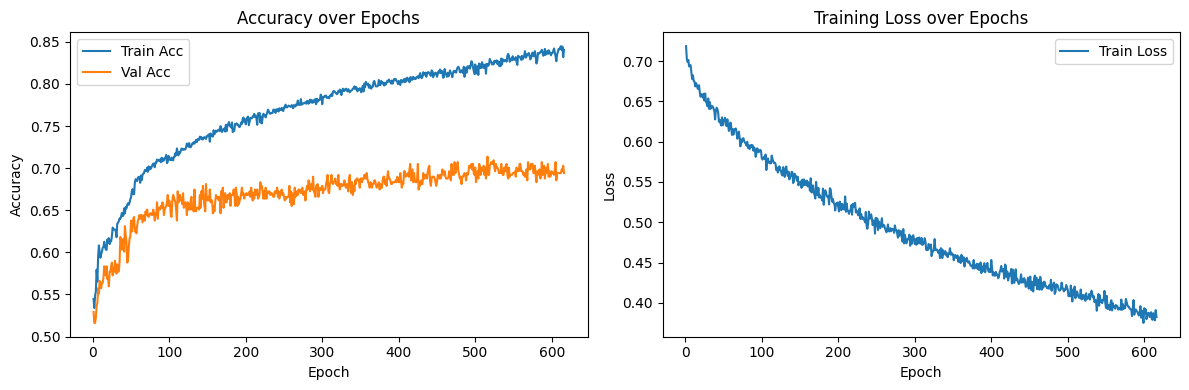

In [10]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [2, 3])
    test_mask = np.isin(test_labels, [2, 3])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask]-2

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]-2

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    print(classification_report(final_labels, final_preds, target_names=['Class 0', 'Class 1']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    print(f"🎯 Sensitivity (Recall for Class 1): {sensitivity:.4f}")
    print(f"🎯 Specificity: {specificity:.4f}")

    # The classification_report already provides precision, recall (sensitivity), and F1-score for each class.
    # The 'recall' for Class 1 in the report is your sensitivity.
    # The 'recall' for Class 0 in the report is your specificity.

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

In [ ]:
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report
from mne.decoding import CSP
import matplotlib.pyplot as plt
from tqdm import trange

0-2


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  42%|████▏     | 424/1000 [33:05<44:56,  4.68s/it, Train Loss=0.3506, Train Acc=0.8823, Val Acc=0.7701, Val Kappa=0.5402, Best Val Kappa=0.5620 (Epoch 375), Best Val Acc=0.7809 (Epoch 375)]  


⏹️ Early stopping at epoch 425. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6771
📊 Final Test Cohen’s Kappa Score: 0.3542

🔬 Classification Report for Test Set:


               precision    recall  f1-score   support

Left Hand (0)       0.62      0.90      0.74       144
     Feet (1)       0.81      0.46      0.59       144

     accuracy                           0.68       288
    macro avg       0.72      0.68      0.66       288
 weighted avg       0.72      0.68      0.66       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.4583
🎯 Specificity (Recall for Class 0 - Left Hand): 0.8958


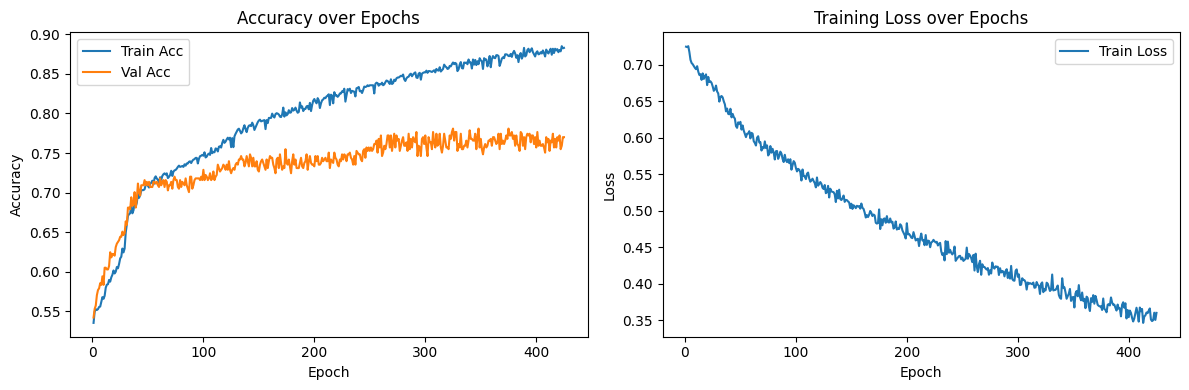


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  33%|███▎      | 331/1000 [50:02<1:41:09,  9.07s/it, Train Loss=0.3722, Train Acc=0.8687, Val Acc=0.7831, Val Kappa=0.5665, Best Val Kappa=0.6009 (Epoch 232), Best Val Acc=0.8004 (Epoch 232)]


⏹️ Early stopping at epoch 332. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4896
📊 Final Test Cohen’s Kappa Score: -0.0208

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.49      0.66      0.56       144
     Feet (1)       0.48      0.32      0.38       144

     accuracy                           0.49       288
    macro avg       0.49      0.49      0.47       288
 weighted avg       0.49      0.49      0.47       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.3194
🎯 Specificity (Recall for Class 0 - Left Hand): 0.6597


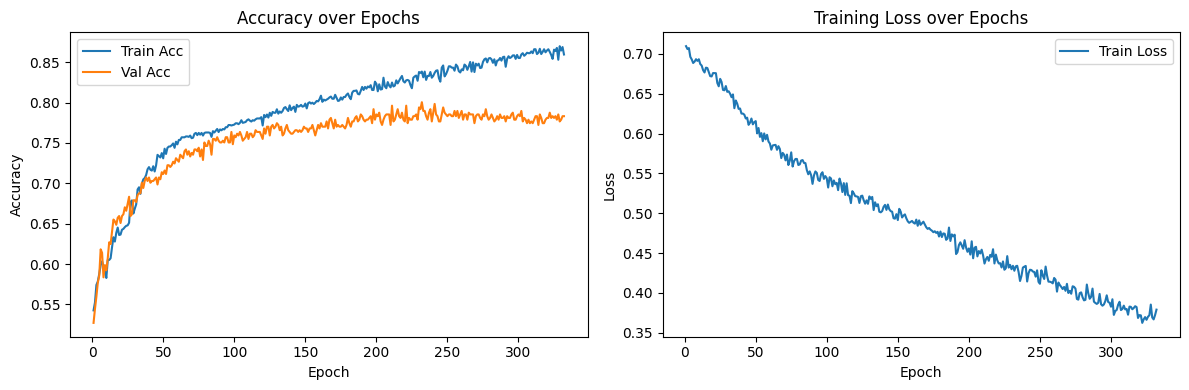


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  16%|█▌        | 159/1000 [12:47<1:07:41,  4.83s/it, Train Loss=0.5225, Train Acc=0.7672, Val Acc=0.7289, Val Kappa=0.4571, Best Val Kappa=0.4691 (Epoch 60), Best Val Acc=0.7332 (Epoch 60)]


⏹️ Early stopping at epoch 160. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6528
📊 Final Test Cohen’s Kappa Score: 0.3056

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.59      0.99      0.74       144
     Feet (1)       0.96      0.32      0.48       144

     accuracy                           0.65       288
    macro avg       0.78      0.65      0.61       288
 weighted avg       0.77      0.65      0.61       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.3194
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9861


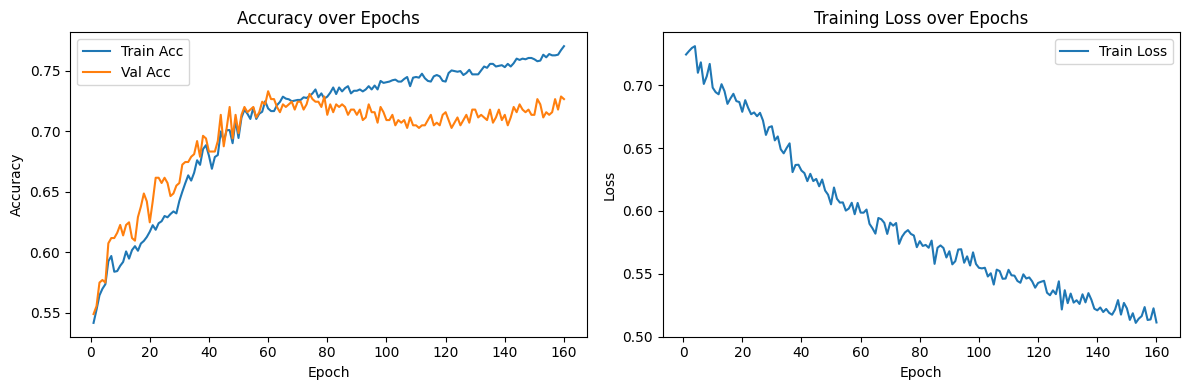


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  45%|████▍     | 449/1000 [1:19:20<1:37:21, 10.60s/it, Train Loss=0.2891, Train Acc=0.9012, Val Acc=0.8134, Val Kappa=0.6273, Best Val Kappa=0.6473 (Epoch 350), Best Val Acc=0.8243 (Epoch 350)]  


⏹️ Early stopping at epoch 450. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5174
📊 Final Test Cohen’s Kappa Score: 0.0347

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.67      0.07      0.13       144
     Feet (1)       0.51      0.97      0.67       144

     accuracy                           0.52       288
    macro avg       0.59      0.52      0.40       288
 weighted avg       0.59      0.52      0.40       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.9653
🎯 Specificity (Recall for Class 0 - Left Hand): 0.0694


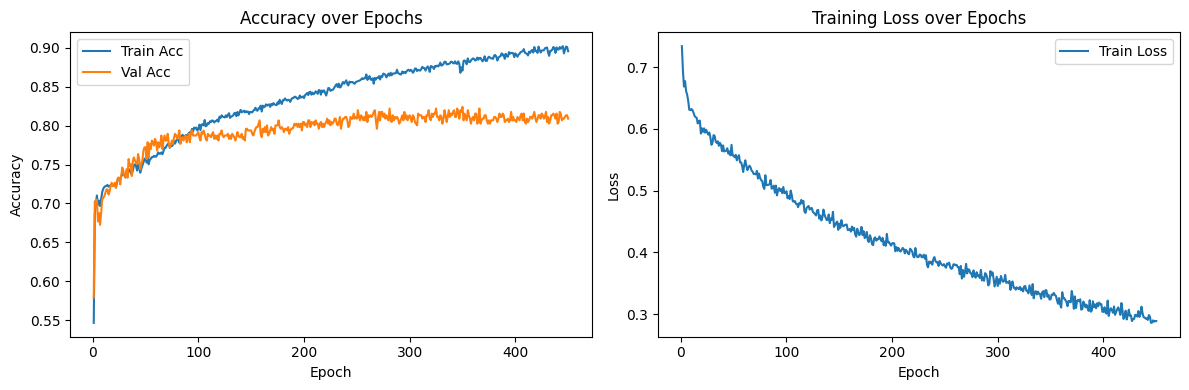


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  54%|█████▍    | 538/1000 [46:24<39:50,  5.18s/it, Train Loss=0.2766, Train Acc=0.9078, Val Acc=0.7722, Val Kappa=0.5441, Best Val Kappa=0.5877 (Epoch 439), Best Val Acc=0.7939 (Epoch 439)]   


⏹️ Early stopping at epoch 539. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.51      0.99      0.67       144
     Feet (1)       0.80      0.03      0.05       144

     accuracy                           0.51       288
    macro avg       0.65      0.51      0.36       288
 weighted avg       0.65      0.51      0.36       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0278
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9931


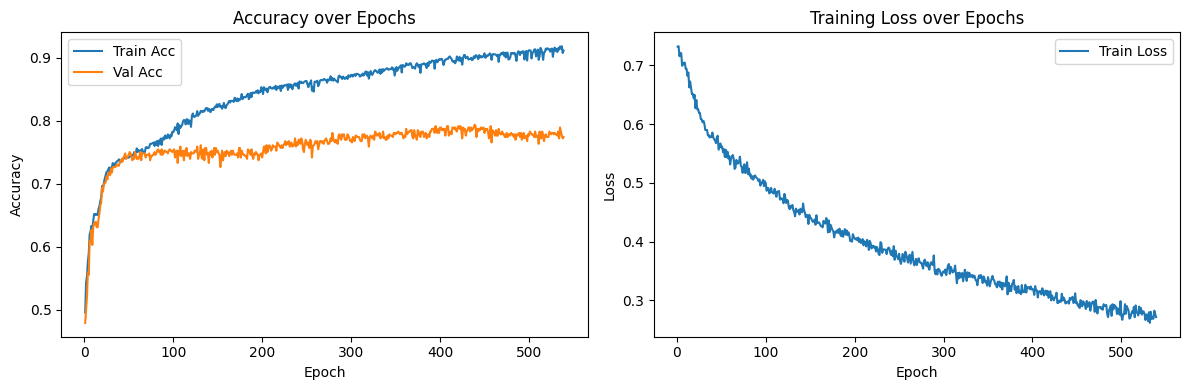


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  24%|██▍       | 239/1000 [18:12<57:57,  4.57s/it, Train Loss=0.3611, Train Acc=0.8551, Val Acc=0.8091, Val Kappa=0.6170, Best Val Kappa=0.6387 (Epoch 140), Best Val Acc=0.8200 (Epoch 140)]  


⏹️ Early stopping at epoch 240. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5208
📊 Final Test Cohen’s Kappa Score: 0.0417

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.65      0.09      0.16       144
     Feet (1)       0.51      0.95      0.67       144

     accuracy                           0.52       288
    macro avg       0.58      0.52      0.41       288
 weighted avg       0.58      0.52      0.41       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.9514
🎯 Specificity (Recall for Class 0 - Left Hand): 0.0903


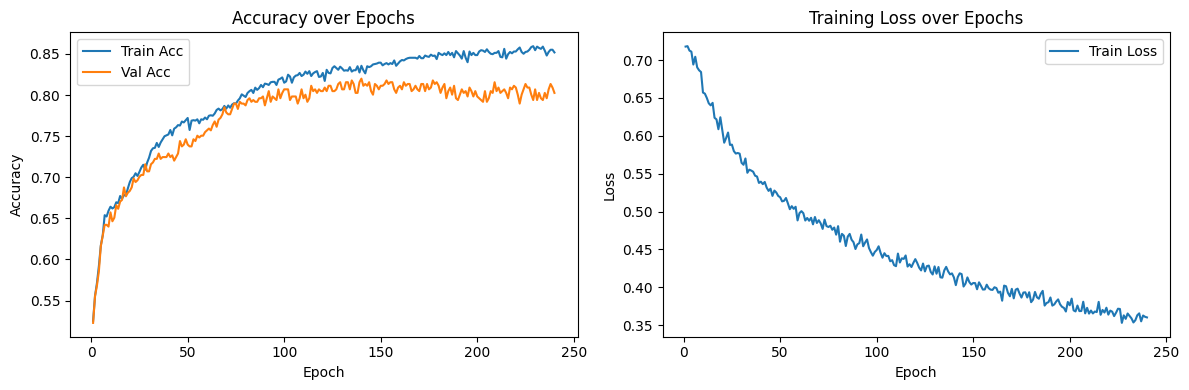


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  37%|███▋      | 373/1000 [30:33<51:22,  4.92s/it, Train Loss=0.3555, Train Acc=0.8481, Val Acc=0.8048, Val Kappa=0.6096, Best Val Kappa=0.6140 (Epoch 274), Best Val Acc=0.8069 (Epoch 274)]  


⏹️ Early stopping at epoch 374. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4653
📊 Final Test Cohen’s Kappa Score: -0.0694

🔬 Classification Report for Test Set:


               precision    recall  f1-score   support

Left Hand (0)       0.48      0.67      0.56       144
     Feet (1)       0.44      0.26      0.32       144

     accuracy                           0.47       288
    macro avg       0.46      0.47      0.44       288
 weighted avg       0.46      0.47      0.44       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.2569
🎯 Specificity (Recall for Class 0 - Left Hand): 0.6736


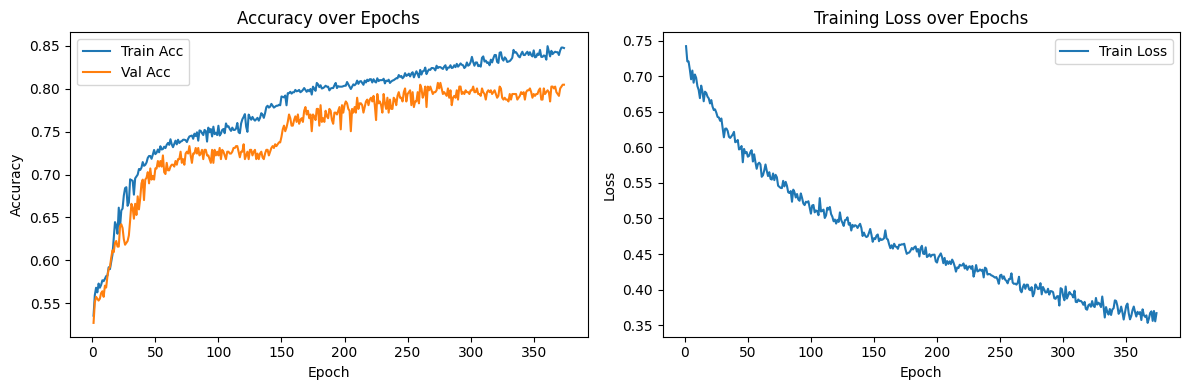


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  34%|███▍      | 343/1000 [24:21<46:39,  4.26s/it, Train Loss=0.3416, Train Acc=0.8806, Val Acc=0.7809, Val Kappa=0.5612, Best Val Kappa=0.5873 (Epoch 244), Best Val Acc=0.7939 (Epoch 244)]  


⏹️ Early stopping at epoch 344. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6771
📊 Final Test Cohen’s Kappa Score: 0.3542

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.64      0.79      0.71       144
     Feet (1)       0.73      0.56      0.64       144

     accuracy                           0.68       288
    macro avg       0.69      0.68      0.67       288
 weighted avg       0.69      0.68      0.67       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.5625
🎯 Specificity (Recall for Class 0 - Left Hand): 0.7917


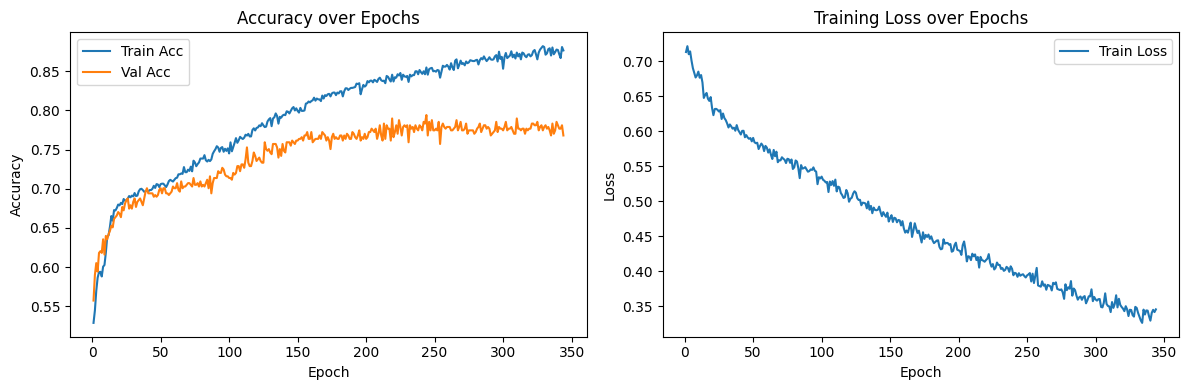


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1103/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  28%|██▊       | 284/1000 [19:02<48:01,  4.02s/it, Train Loss=0.3983, Train Acc=0.8540, Val Acc=0.7614, Val Kappa=0.5228, Best Val Kappa=0.5359 (Epoch 225), Best Val Acc=0.7679 (Epoch 225)]  


⏹️ Early stopping at epoch 285. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6806
📊 Final Test Cohen’s Kappa Score: 0.3611

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.70      0.63      0.66       144
     Feet (1)       0.66      0.73      0.70       144

     accuracy                           0.68       288
    macro avg       0.68      0.68      0.68       288
 weighted avg       0.68      0.68      0.68       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.7292
🎯 Specificity (Recall for Class 0 - Left Hand): 0.6319


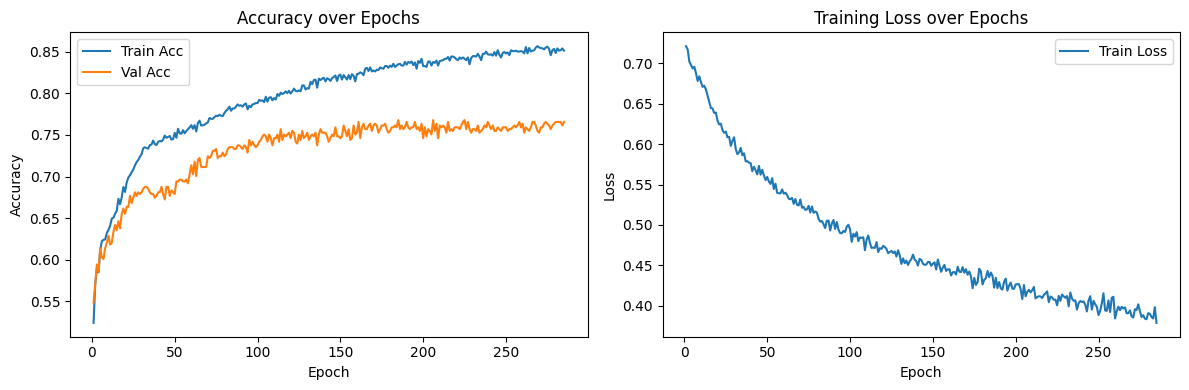

In [12]:

for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    train_mask = np.isin(train_labels_all, [0, 2])
    test_mask = np.isin(test_labels, [0, 2])

    # Filter the data based on the mask
    train_data_binary = train_data_all[train_mask]
    test_data_binary = test_data[test_mask]
    train_labels_binary = (train_labels_all[train_mask] == 2).astype(int)
    test_labels_binary = (test_labels[test_mask] == 2).astype(int)

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    # Updated target names for clarity
    print(classification_report(final_labels, final_preds, target_names=['Left Hand (0)', 'Feet (1)']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"🎯 Sensitivity (Recall for Class 1 - Feet): {sensitivity:.4f}")
        print(f"🎯 Specificity (Recall for Class 0 - Left Hand): {specificity:.4f}")
    else:
        print("Could not compute sensitivity/specificity from confusion matrix (likely only one class was predicted).")
        print(f"Confusion Matrix:\n{cm}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

In [8]:
0-3


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  30%|███       | 304/1000 [22:23<51:16,  4.42s/it, Train Loss=0.3899, Train Acc=0.8410, Val Acc=0.7462, Val Kappa=0.4858, Best Val Kappa=0.5403 (Epoch 205), Best Val Acc=0.7722 (Epoch 205)]  


⏹️ Early stopping at epoch 305. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8125
📊 Final Test Cohen’s Kappa Score: 0.6250

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.73      0.99      0.84       144
     Feet (1)       0.98      0.64      0.77       144

     accuracy                           0.81       288
    macro avg       0.86      0.81      0.81       288
 weighted avg       0.86      0.81      0.81       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.6389
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9861


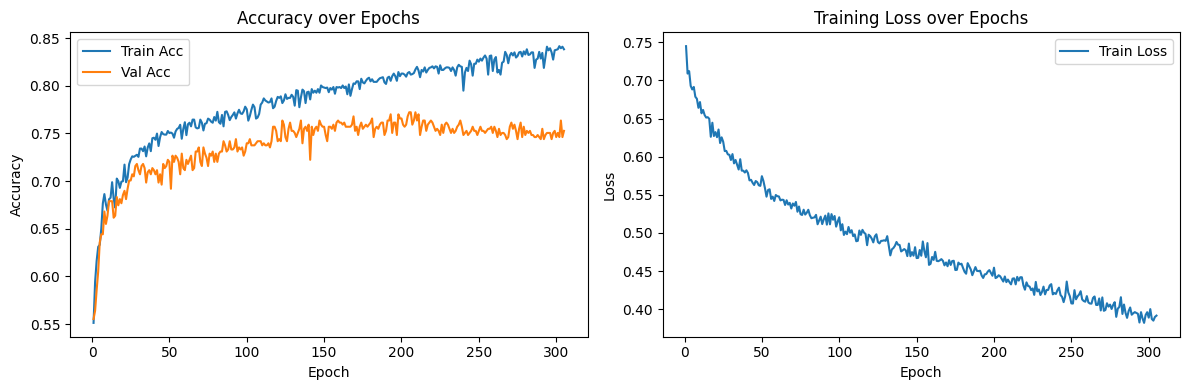


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  49%|████▉     | 489/1000 [38:10<39:53,  4.68s/it, Train Loss=0.2906, Train Acc=0.9018, Val Acc=0.8351, Val Kappa=0.6693, Best Val Kappa=0.7040 (Epoch 390), Best Val Acc=0.8525 (Epoch 390)]  


⏹️ Early stopping at epoch 490. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.51      0.94      0.66       144
     Feet (1)       0.57      0.08      0.15       144

     accuracy                           0.51       288
    macro avg       0.54      0.51      0.40       288
 weighted avg       0.54      0.51      0.40       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0833
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9375


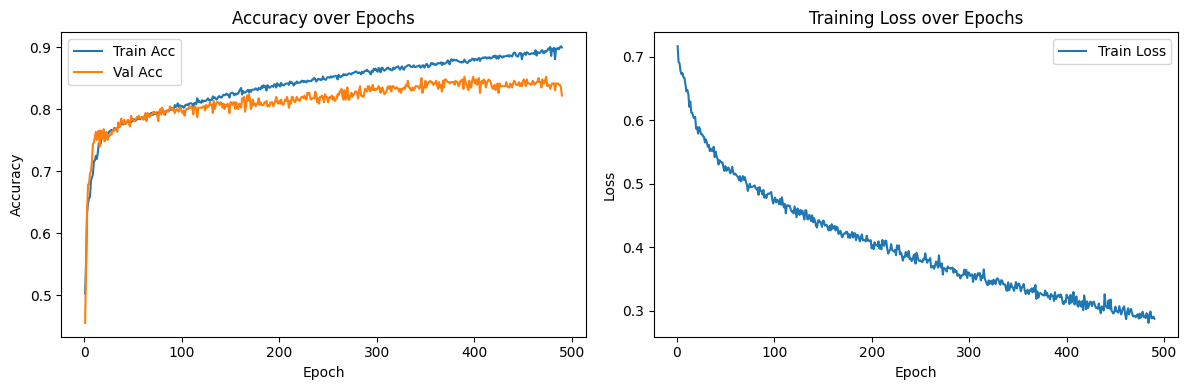


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  34%|███▎      | 336/1000 [26:05<51:34,  4.66s/it, Train Loss=0.3345, Train Acc=0.8698, Val Acc=0.7831, Val Kappa=0.5656, Best Val Kappa=0.5916 (Epoch 237), Best Val Acc=0.7961 (Epoch 237)]  


⏹️ Early stopping at epoch 337. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6875
📊 Final Test Cohen’s Kappa Score: 0.3750

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.68      0.72      0.70       144
     Feet (1)       0.70      0.65      0.68       144

     accuracy                           0.69       288
    macro avg       0.69      0.69      0.69       288
 weighted avg       0.69      0.69      0.69       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.6528
🎯 Specificity (Recall for Class 0 - Left Hand): 0.7222


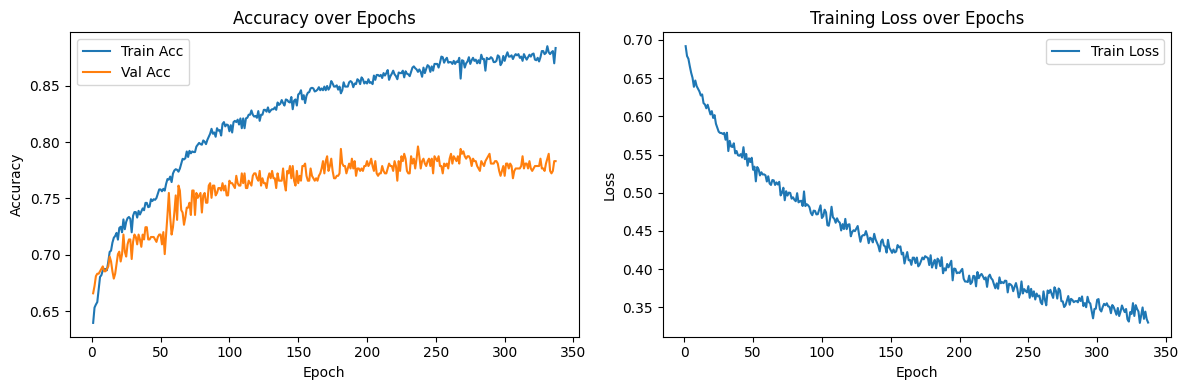


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  42%|████▏     | 417/1000 [31:13<43:39,  4.49s/it, Train Loss=0.3329, Train Acc=0.8893, Val Acc=0.7570, Val Kappa=0.5123, Best Val Kappa=0.5529 (Epoch 318), Best Val Acc=0.7766 (Epoch 318)]  


⏹️ Early stopping at epoch 418. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5486
📊 Final Test Cohen’s Kappa Score: 0.0972

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.69      0.17      0.28       144
     Feet (1)       0.53      0.92      0.67       144

     accuracy                           0.55       288
    macro avg       0.61      0.55      0.47       288
 weighted avg       0.61      0.55      0.47       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.9236
🎯 Specificity (Recall for Class 0 - Left Hand): 0.1736


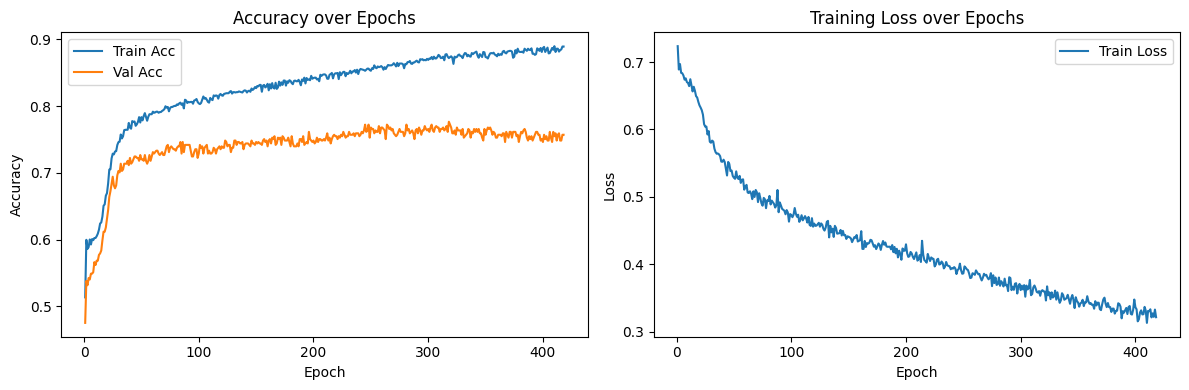


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  55%|█████▌    | 554/1000 [44:53<36:08,  4.86s/it, Train Loss=0.2575, Train Acc=0.9148, Val Acc=0.7983, Val Kappa=0.5968, Best Val Kappa=0.6307 (Epoch 455), Best Val Acc=0.8156 (Epoch 455)]  


⏹️ Early stopping at epoch 555. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4931
📊 Final Test Cohen’s Kappa Score: -0.0139

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.50      0.98      0.66       144
     Feet (1)       0.25      0.01      0.01       144

     accuracy                           0.49       288
    macro avg       0.37      0.49      0.34       288
 weighted avg       0.37      0.49      0.34       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0069
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9792


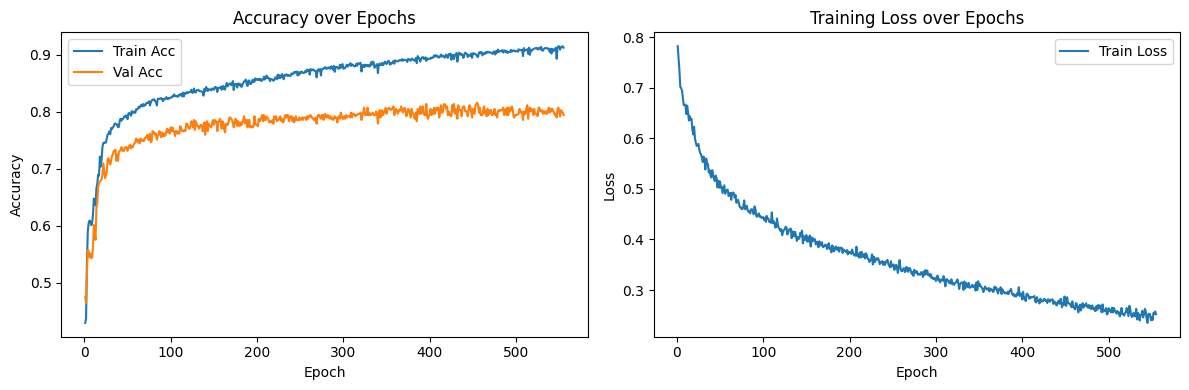


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  30%|██▉       | 299/1000 [24:57<58:31,  5.01s/it, Train Loss=0.3516, Train Acc=0.8399, Val Acc=0.8113, Val Kappa=0.6238, Best Val Kappa=0.6361 (Epoch 200), Best Val Acc=0.8178 (Epoch 200)]  


⏹️ Early stopping at epoch 300. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5243
📊 Final Test Cohen’s Kappa Score: 0.0486

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.54      0.36      0.43       144
     Feet (1)       0.52      0.69      0.59       144

     accuracy                           0.52       288
    macro avg       0.53      0.52      0.51       288
 weighted avg       0.53      0.52      0.51       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.6875
🎯 Specificity (Recall for Class 0 - Left Hand): 0.3611


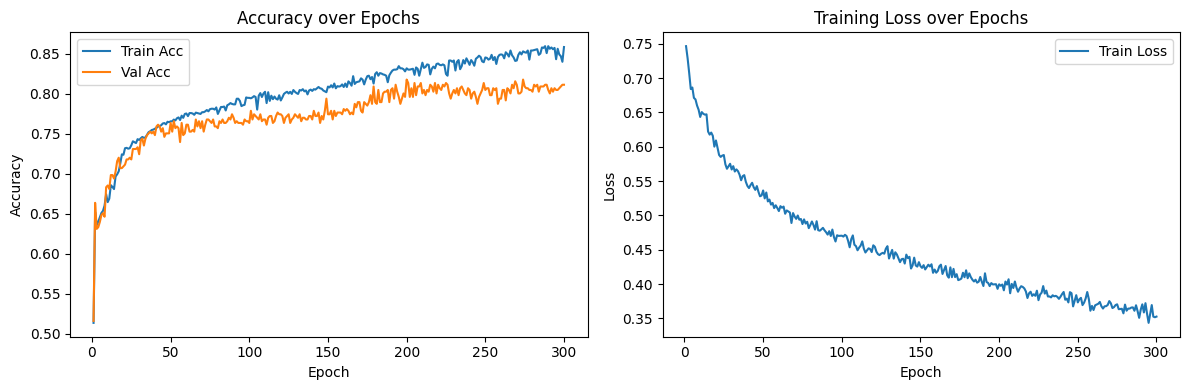


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  41%|████▏     | 413/1000 [32:55<46:47,  4.78s/it, Train Loss=0.3232, Train Acc=0.8638, Val Acc=0.7939, Val Kappa=0.5889, Best Val Kappa=0.6101 (Epoch 314), Best Val Acc=0.8048 (Epoch 314)]  


⏹️ Early stopping at epoch 414. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.51      1.00      0.67       144
     Feet (1)       1.00      0.02      0.04       144

     accuracy                           0.51       288
    macro avg       0.75      0.51      0.36       288
 weighted avg       0.75      0.51      0.36       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0208
🎯 Specificity (Recall for Class 0 - Left Hand): 1.0000


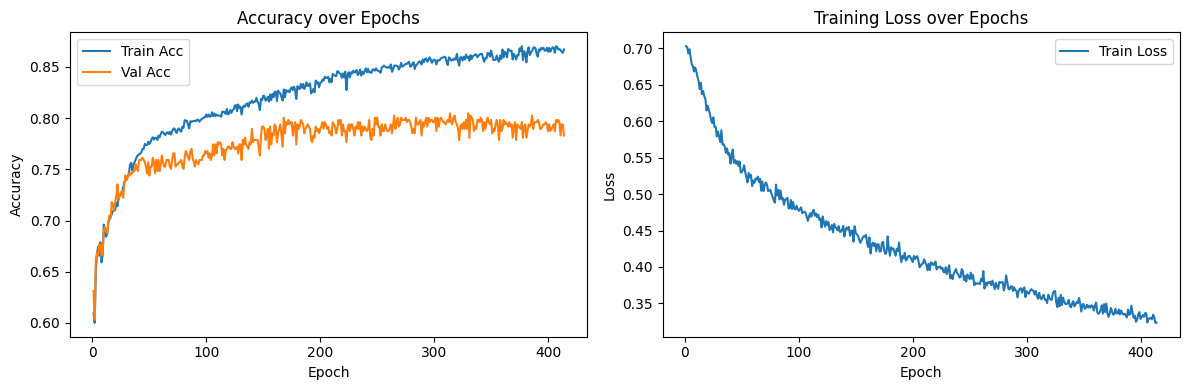


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  62%|██████▏   | 615/1000 [47:13<29:33,  4.61s/it, Train Loss=0.3011, Train Acc=0.8806, Val Acc=0.7831, Val Kappa=0.5666, Best Val Kappa=0.6352 (Epoch 565), Best Val Acc=0.8178 (Epoch 565)]  


⏹️ Early stopping at epoch 616. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.3750
📊 Final Test Cohen’s Kappa Score: -0.2500

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.34      0.28      0.31       144
     Feet (1)       0.40      0.47      0.43       144

     accuracy                           0.38       288
    macro avg       0.37      0.38      0.37       288
 weighted avg       0.37      0.38      0.37       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.4722
🎯 Specificity (Recall for Class 0 - Left Hand): 0.2778


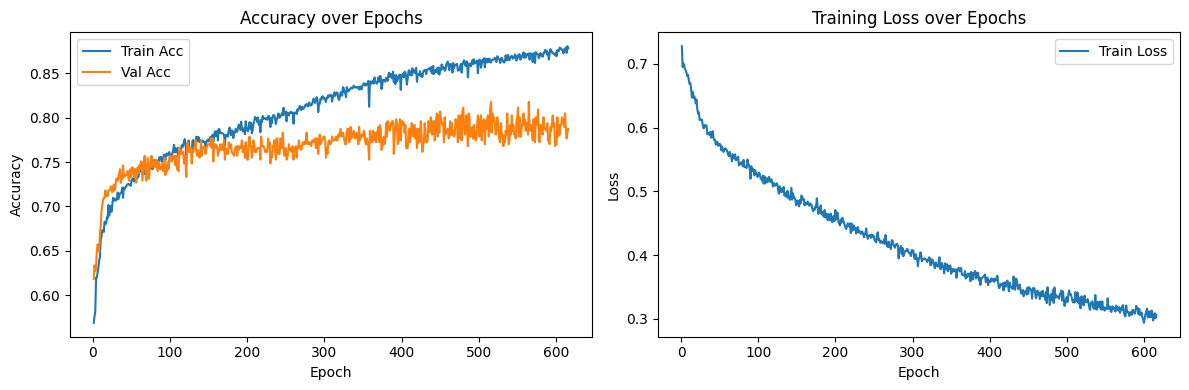


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  40%|████      | 405/1000 [31:59<47:00,  4.74s/it, Train Loss=0.3542, Train Acc=0.8709, Val Acc=0.8156, Val Kappa=0.6271, Best Val Kappa=0.6427 (Epoch 306), Best Val Acc=0.8243 (Epoch 306)]  


⏹️ Early stopping at epoch 406. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6806
📊 Final Test Cohen’s Kappa Score: 0.3611

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       1.00      0.36      0.53       144
     Feet (1)       0.61      1.00      0.76       144

     accuracy                           0.68       288
    macro avg       0.81      0.68      0.64       288
 weighted avg       0.81      0.68      0.64       288

🎯 Sensitivity (Recall for Class 1 - Feet): 1.0000
🎯 Specificity (Recall for Class 0 - Left Hand): 0.3611


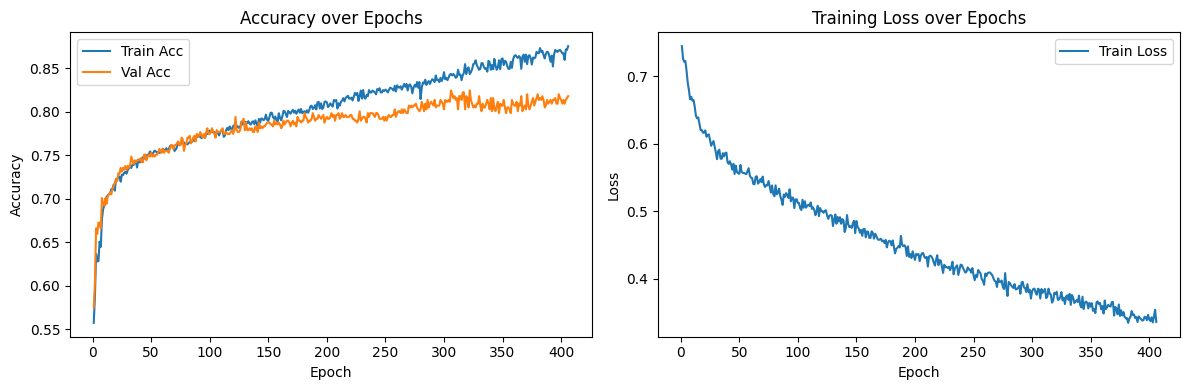

In [9]:

for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    train_mask = np.isin(train_labels_all, [0, 3])
    test_mask = np.isin(test_labels, [0, 3])

    # Filter the data based on the mask
    train_data_binary = train_data_all[train_mask]
    test_data_binary = test_data[test_mask]
    train_labels_binary = (train_labels_all[train_mask] == 3).astype(int)
    test_labels_binary = (test_labels[test_mask] == 3).astype(int)

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    # Updated target names for clarity
    print(classification_report(final_labels, final_preds, target_names=['Left Hand (0)', 'Feet (1)']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"🎯 Sensitivity (Recall for Class 1 - Feet): {sensitivity:.4f}")
        print(f"🎯 Specificity (Recall for Class 0 - Left Hand): {specificity:.4f}")
    else:
        print("Could not compute sensitivity/specificity from confusion matrix (likely only one class was predicted).")
        print(f"Confusion Matrix:\n{cm}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

In [ ]:
1-3


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  66%|██████▋   | 664/1000 [45:08<22:50,  4.08s/it, Train Loss=0.3138, Train Acc=0.8795, Val Acc=0.7874, Val Kappa=0.5747, Best Val Kappa=0.6157 (Epoch 654), Best Val Acc=0.8091 (Epoch 654)]  


⏹️ Early stopping at epoch 665. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7535
📊 Final Test Cohen’s Kappa Score: 0.5069

🔬 Classification Report for Test Set:


               precision    recall  f1-score   support

Left Hand (0)       0.67      1.00      0.80       144
     Feet (1)       1.00      0.51      0.67       144

     accuracy                           0.75       288
    macro avg       0.83      0.75      0.74       288
 weighted avg       0.83      0.75      0.74       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.5069
🎯 Specificity (Recall for Class 0 - Left Hand): 1.0000


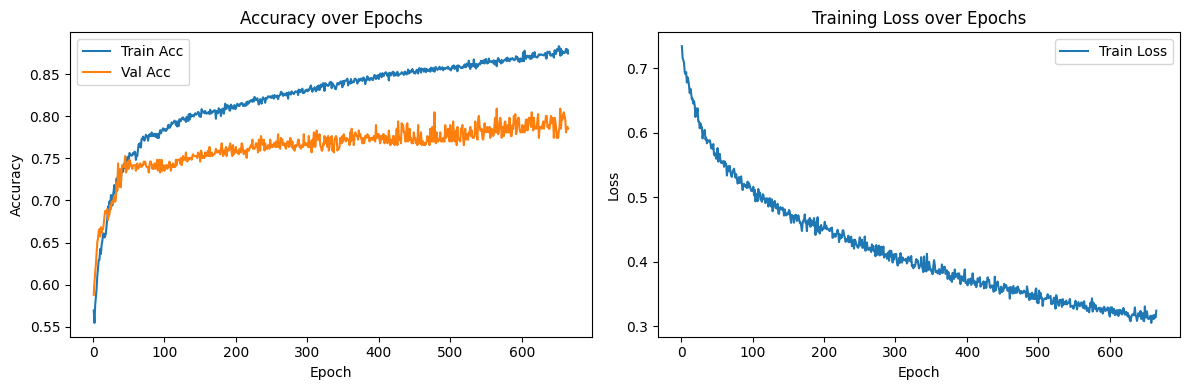


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  40%|████      | 405/1000 [28:03<41:13,  4.16s/it, Train Loss=0.2982, Train Acc=0.8931, Val Acc=0.7939, Val Kappa=0.5878, Best Val Kappa=0.6139 (Epoch 395), Best Val Acc=0.8069 (Epoch 395)]  


⏹️ Early stopping at epoch 406. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5069
📊 Final Test Cohen’s Kappa Score: 0.0139

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.50      0.89      0.64       144
     Feet (1)       0.53      0.12      0.20       144

     accuracy                           0.51       288
    macro avg       0.52      0.51      0.42       288
 weighted avg       0.52      0.51      0.42       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.1250
🎯 Specificity (Recall for Class 0 - Left Hand): 0.8889


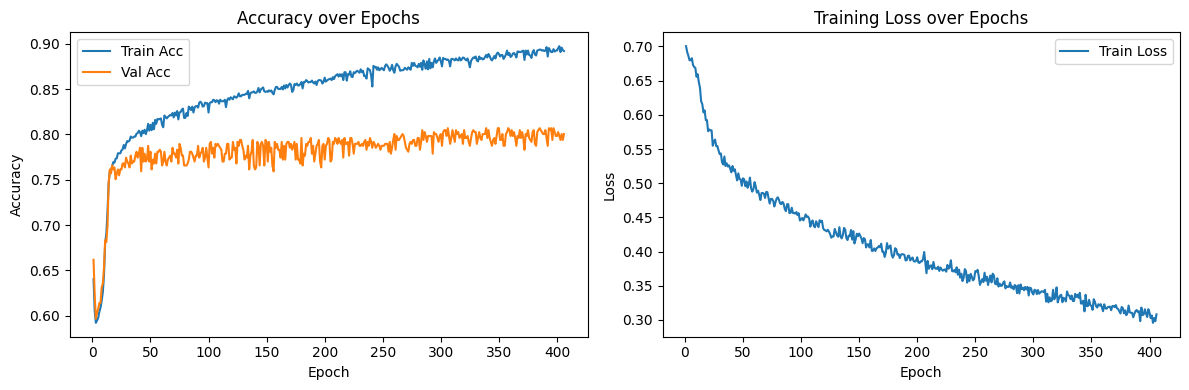


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  42%|████▏     | 418/1000 [26:05<36:20,  3.75s/it, Train Loss=0.3557, Train Acc=0.8709, Val Acc=0.7852, Val Kappa=0.5710, Best Val Kappa=0.5966 (Epoch 319), Best Val Acc=0.7983 (Epoch 319)]


⏹️ Early stopping at epoch 419. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7951
📊 Final Test Cohen’s Kappa Score: 0.5903

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.90      0.66      0.76       144
     Feet (1)       0.73      0.93      0.82       144

     accuracy                           0.80       288
    macro avg       0.82      0.80      0.79       288
 weighted avg       0.82      0.80      0.79       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.9306
🎯 Specificity (Recall for Class 0 - Left Hand): 0.6597


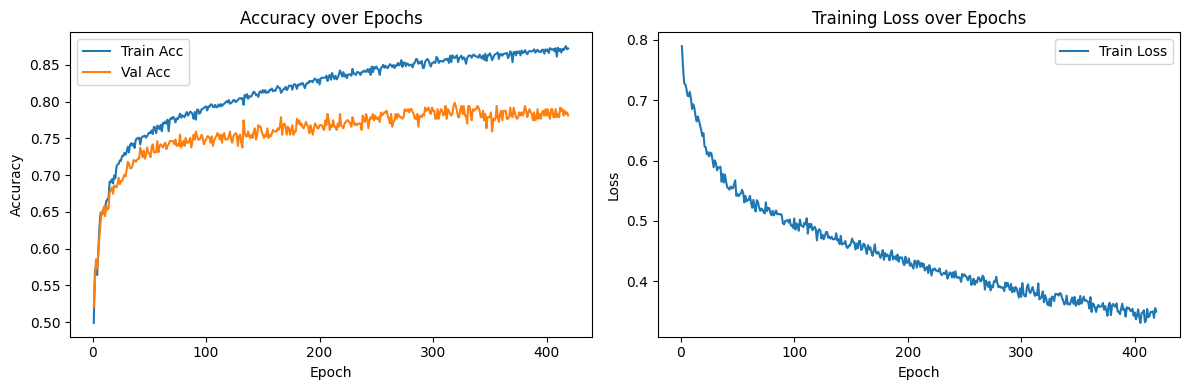


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▏       | 221/1000 [15:23<54:15,  4.18s/it, Train Loss=0.3405, Train Acc=0.8730, Val Acc=0.7679, Val Kappa=0.5351, Best Val Kappa=0.5697 (Epoch 122), Best Val Acc=0.7852 (Epoch 122)]  


⏹️ Early stopping at epoch 222. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6424
📊 Final Test Cohen’s Kappa Score: 0.2847

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.70      0.51      0.59       144
     Feet (1)       0.61      0.78      0.69       144

     accuracy                           0.64       288
    macro avg       0.65      0.64      0.64       288
 weighted avg       0.65      0.64      0.64       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.7778
🎯 Specificity (Recall for Class 0 - Left Hand): 0.5069


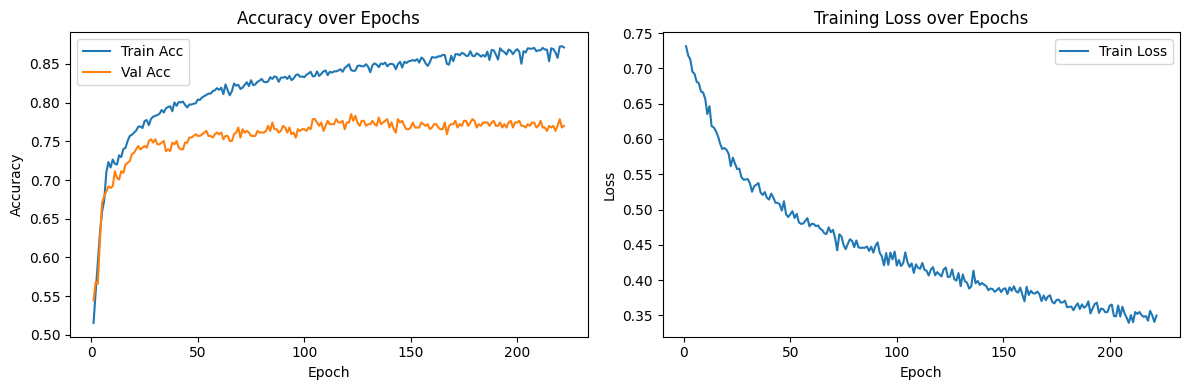


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  27%|██▋       | 268/1000 [13:10:26<35:58:58, 176.96s/it, Train Loss=0.3212, Train Acc=0.8828, Val Acc=0.7961, Val Kappa=0.5908, Best Val Kappa=0.6221 (Epoch 169), Best Val Acc=0.8113 (Epoch 169)]  


⏹️ Early stopping at epoch 269. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5035
📊 Final Test Cohen’s Kappa Score: 0.0069

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.50      0.95      0.66       144
     Feet (1)       0.53      0.06      0.10       144

     accuracy                           0.50       288
    macro avg       0.52      0.50      0.38       288
 weighted avg       0.52      0.50      0.38       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0556
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9514


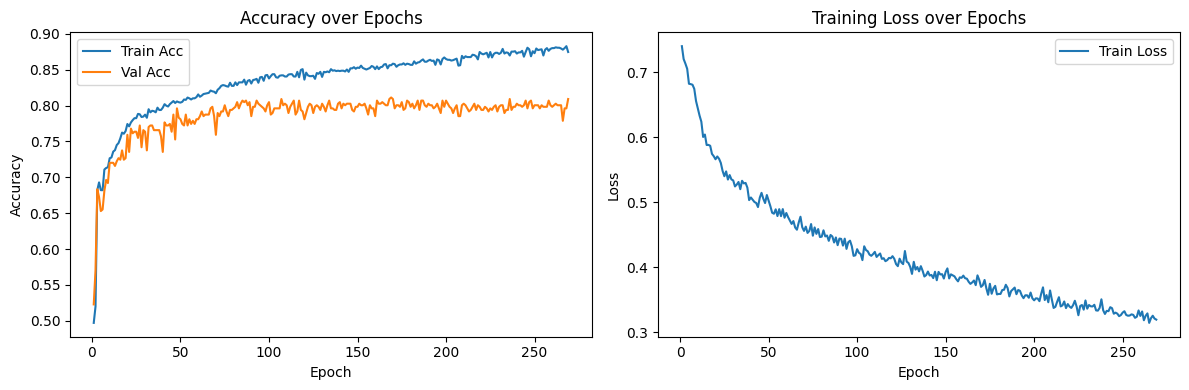


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  40%|████      | 401/1000 [28:00<41:50,  4.19s/it, Train Loss=0.3115, Train Acc=0.8817, Val Acc=0.8460, Val Kappa=0.6918, Best Val Kappa=0.7045 (Epoch 331), Best Val Acc=0.8525 (Epoch 331)]  


⏹️ Early stopping at epoch 402. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.52      0.26      0.34       144
     Feet (1)       0.51      0.76      0.61       144

     accuracy                           0.51       288
    macro avg       0.51      0.51      0.48       288
 weighted avg       0.51      0.51      0.48       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.7639
🎯 Specificity (Recall for Class 0 - Left Hand): 0.2569


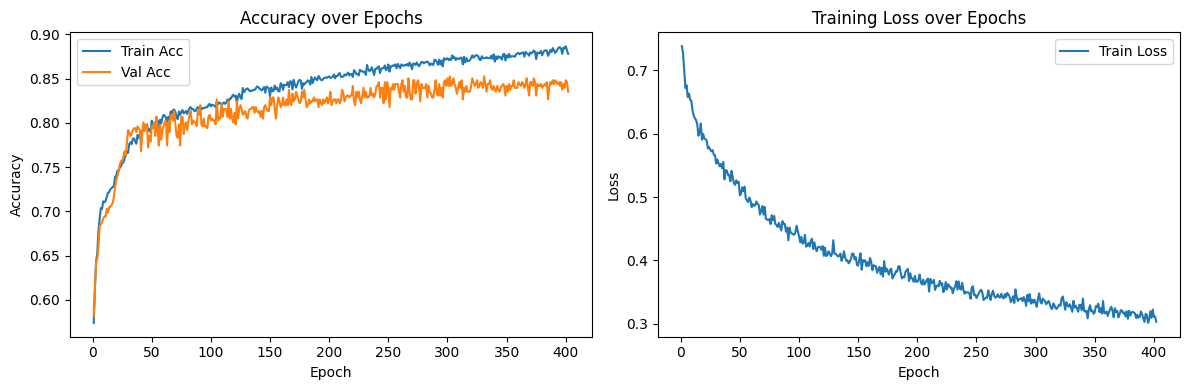


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  36%|███▌      | 357/1000 [52:49<1:35:08,  8.88s/it, Train Loss=0.3608, Train Acc=0.8595, Val Acc=0.8091, Val Kappa=0.6184, Best Val Kappa=0.6487 (Epoch 258), Best Val Acc=0.8243 (Epoch 258)]  


⏹️ Early stopping at epoch 358. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5417
📊 Final Test Cohen’s Kappa Score: 0.0833

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.52      0.99      0.68       144
     Feet (1)       0.88      0.10      0.17       144

     accuracy                           0.54       288
    macro avg       0.70      0.54      0.43       288
 weighted avg       0.70      0.54      0.43       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0972
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9861


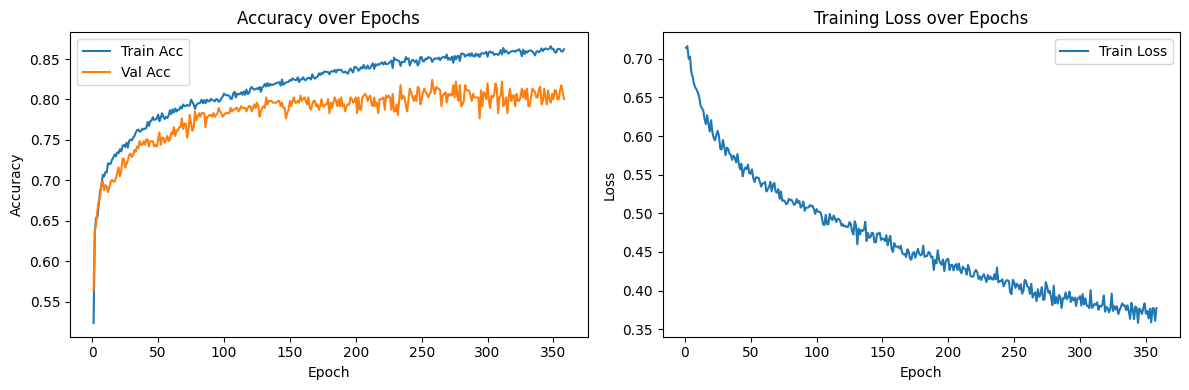


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  37%|███▋      | 374/1000 [23:25<39:11,  3.76s/it, Train Loss=0.3531, Train Acc=0.8557, Val Acc=0.7939, Val Kappa=0.5885, Best Val Kappa=0.6180 (Epoch 293), Best Val Acc=0.8091 (Epoch 293)]


⏹️ Early stopping at epoch 375. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7118
📊 Final Test Cohen’s Kappa Score: 0.4236

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.67      0.83      0.74       144
     Feet (1)       0.78      0.59      0.67       144

     accuracy                           0.71       288
    macro avg       0.73      0.71      0.71       288
 weighted avg       0.73      0.71      0.71       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.5903
🎯 Specificity (Recall for Class 0 - Left Hand): 0.8333


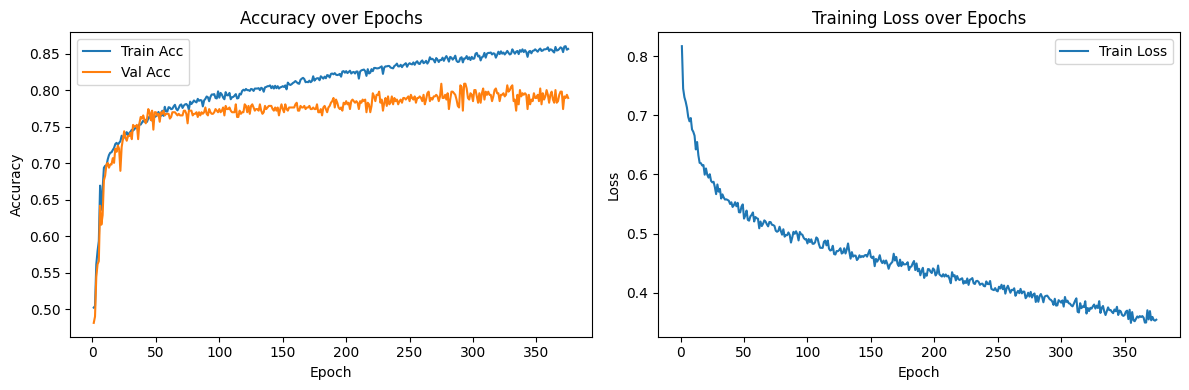


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  17%|█▋        | 167/1000 [1:17:52<6:28:25, 27.98s/it, Train Loss=0.4197, Train Acc=0.8329, Val Acc=0.7462, Val Kappa=0.4976, Best Val Kappa=0.5775 (Epoch 68), Best Val Acc=0.7918 (Epoch 68)]   


⏹️ Early stopping at epoch 168. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5833
📊 Final Test Cohen’s Kappa Score: 0.1667

🔬 Classification Report for Test Set:


               precision    recall  f1-score   support

Left Hand (0)       1.00      0.17      0.29       144
     Feet (1)       0.55      1.00      0.71       144

     accuracy                           0.58       288
    macro avg       0.77      0.58      0.50       288
 weighted avg       0.77      0.58      0.50       288

🎯 Sensitivity (Recall for Class 1 - Feet): 1.0000
🎯 Specificity (Recall for Class 0 - Left Hand): 0.1667


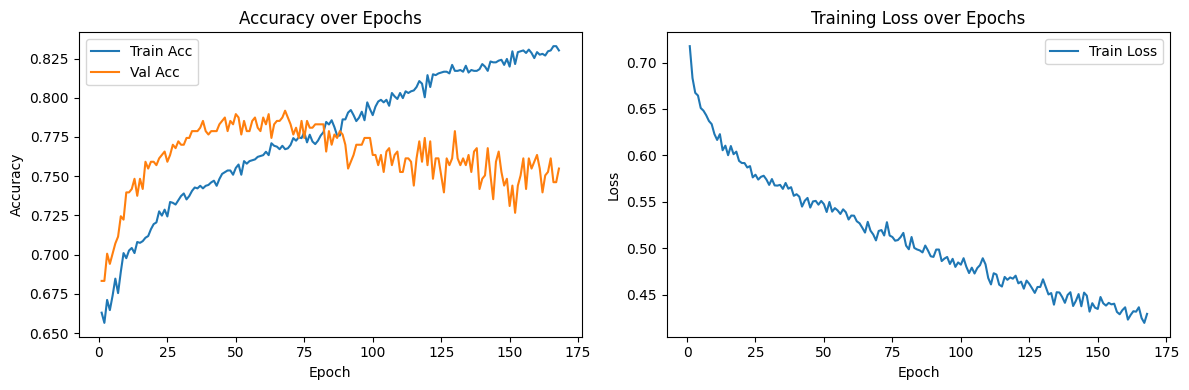

In [7]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    train_mask = np.isin(train_labels_all, [1, 3])
    test_mask = np.isin(test_labels, [1, 3])

    # Filter the data based on the mask
    train_data_binary = train_data_all[train_mask]
    test_data_binary = test_data[test_mask]
    train_labels_binary = (train_labels_all[train_mask] == 3).astype(int)
    test_labels_binary = (test_labels[test_mask] == 3).astype(int)

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    # Updated target names for clarity
    print(classification_report(final_labels, final_preds, target_names=['Left Hand (0)', 'Feet (1)']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"🎯 Sensitivity (Recall for Class 1 - Feet): {sensitivity:.4f}")
        print(f"🎯 Specificity (Recall for Class 0 - Left Hand): {specificity:.4f}")
    else:
        print("Could not compute sensitivity/specificity from confusion matrix (likely only one class was predicted).")
        print(f"Confusion Matrix:\n{cm}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

\
    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

2-3


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  52%|█████▏    | 523/1000 [1:05:50<1:00:03,  7.55s/it, Train Loss=0.3805, Train Acc=0.8535, Val Acc=0.7223, Val Kappa=0.4469, Best Val Kappa=0.4643 (Epoch 510), Best Val Acc=0.7310 (Epoch 510)]


⏹️ Early stopping at epoch 524. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4931
📊 Final Test Cohen’s Kappa Score: -0.0139

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.50      0.94      0.65       144
     Feet (1)       0.43      0.04      0.08       144

     accuracy                           0.49       288
    macro avg       0.46      0.49      0.36       288
 weighted avg       0.46      0.49      0.36       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0417
🎯 Specificity (Recall for Class 0 - Left Hand): 0.9444


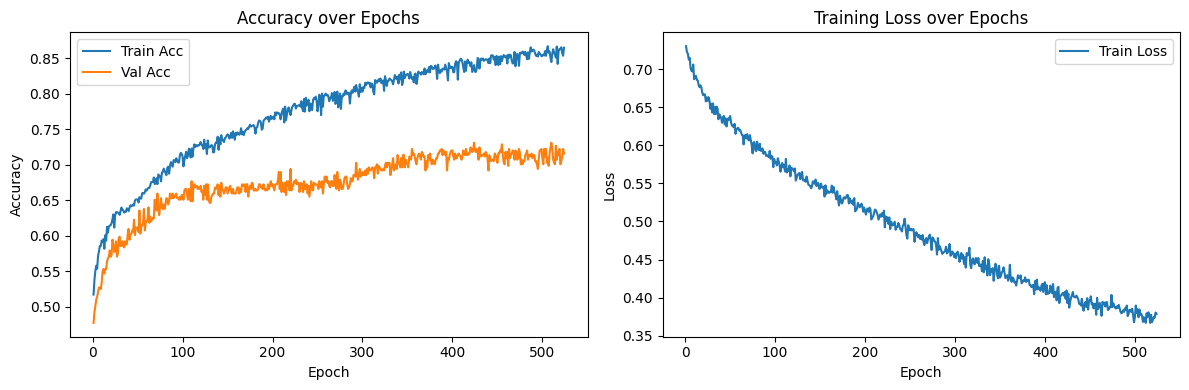


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  22%|██▏       | 215/1000 [17:35<1:04:14,  4.91s/it, Train Loss=0.5039, Train Acc=0.7846, Val Acc=0.6833, Val Kappa=0.3666, Best Val Kappa=0.3929 (Epoch 116), Best Val Acc=0.6963 (Epoch 116)]


⏹️ Early stopping at epoch 216. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4097
📊 Final Test Cohen’s Kappa Score: -0.1806

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.44      0.70      0.54       144
     Feet (1)       0.28      0.12      0.17       144

     accuracy                           0.41       288
    macro avg       0.36      0.41      0.35       288
 weighted avg       0.36      0.41      0.35       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.1181
🎯 Specificity (Recall for Class 0 - Left Hand): 0.7014


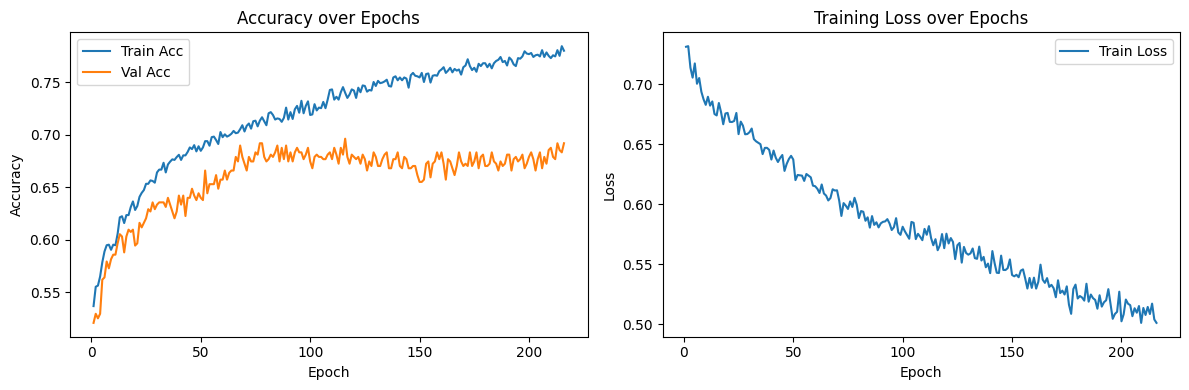


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  19%|█▉        | 188/1000 [14:24<1:02:14,  4.60s/it, Train Loss=0.5484, Train Acc=0.7113, Val Acc=0.6573, Val Kappa=0.3134, Best Val Kappa=0.3813 (Epoch 89), Best Val Acc=0.6898 (Epoch 89)]


⏹️ Early stopping at epoch 189. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.51      0.88      0.64       144
     Feet (1)       0.54      0.15      0.23       144

     accuracy                           0.51       288
    macro avg       0.52      0.51      0.44       288
 weighted avg       0.52      0.51      0.44       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.1458
🎯 Specificity (Recall for Class 0 - Left Hand): 0.8750


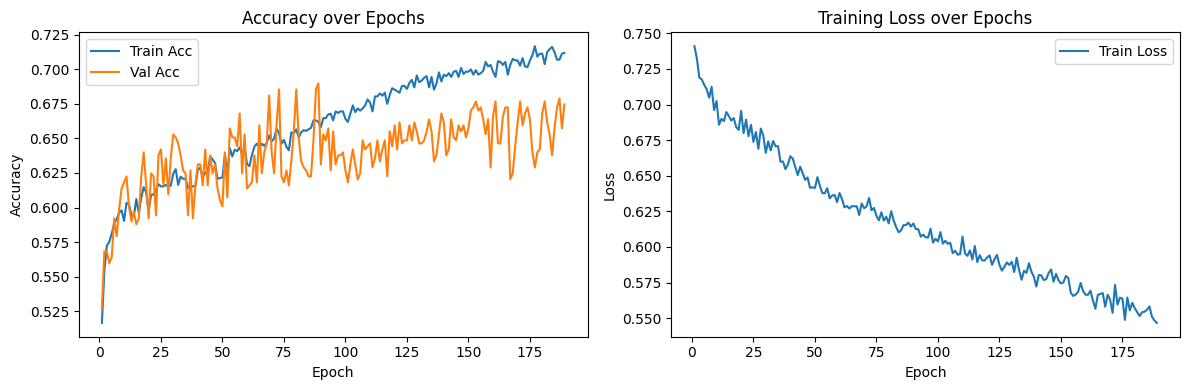


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  35%|███▍      | 348/1000 [29:12<54:42,  5.03s/it, Train Loss=0.4783, Train Acc=0.7857, Val Acc=0.6833, Val Kappa=0.3634, Best Val Kappa=0.4506 (Epoch 249), Best Val Acc=0.7267 (Epoch 249)]  


⏹️ Early stopping at epoch 349. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4688
📊 Final Test Cohen’s Kappa Score: -0.0625

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.38      0.10      0.16       144
     Feet (1)       0.48      0.83      0.61       144

     accuracy                           0.47       288
    macro avg       0.43      0.47      0.39       288
 weighted avg       0.43      0.47      0.39       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.8333
🎯 Specificity (Recall for Class 0 - Left Hand): 0.1042


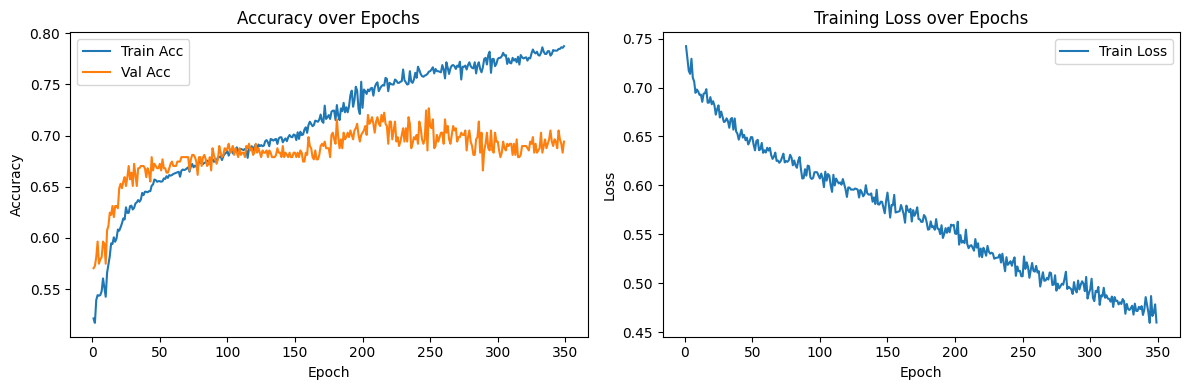


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2.1e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  35%|███▌      | 354/1000 [27:33<50:16,  4.67s/it, Train Loss=0.4897, Train Acc=0.7824, Val Acc=0.6920, Val Kappa=0.3853, Best Val Kappa=0.3914 (Epoch 255), Best Val Acc=0.6963 (Epoch 255)]  


⏹️ Early stopping at epoch 355. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4653
📊 Final Test Cohen’s Kappa Score: -0.0694

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.48      0.74      0.58       144
     Feet (1)       0.42      0.19      0.26       144

     accuracy                           0.47       288
    macro avg       0.45      0.47      0.42       288
 weighted avg       0.45      0.47      0.42       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.1875
🎯 Specificity (Recall for Class 0 - Left Hand): 0.7431


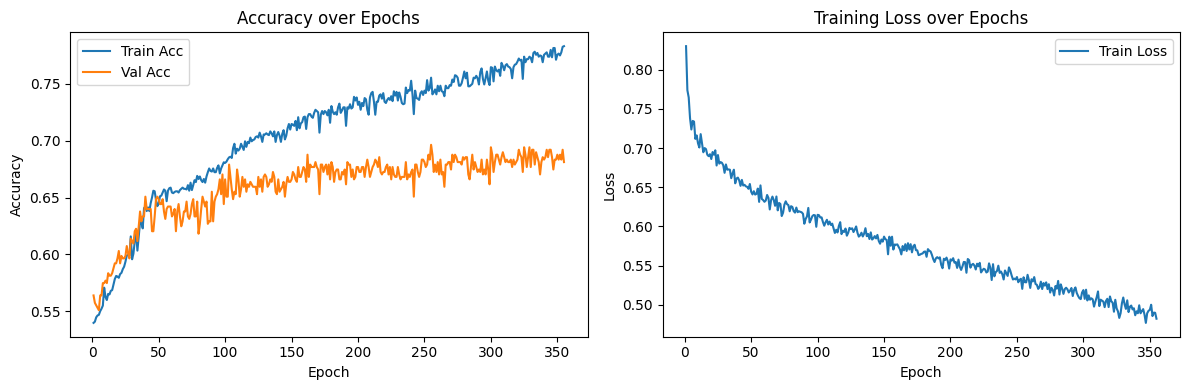


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  29%|██▉       | 288/1000 [22:54<56:37,  4.77s/it, Train Loss=0.4498, Train Acc=0.7965, Val Acc=0.7028, Val Kappa=0.4047, Best Val Kappa=0.4206 (Epoch 255), Best Val Acc=0.7137 (Epoch 255)]  


⏹️ Early stopping at epoch 289. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4549
📊 Final Test Cohen’s Kappa Score: -0.0903

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.48      0.86      0.61       144
     Feet (1)       0.26      0.05      0.08       144

     accuracy                           0.45       288
    macro avg       0.37      0.45      0.35       288
 weighted avg       0.37      0.45      0.35       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.0486
🎯 Specificity (Recall for Class 0 - Left Hand): 0.8611


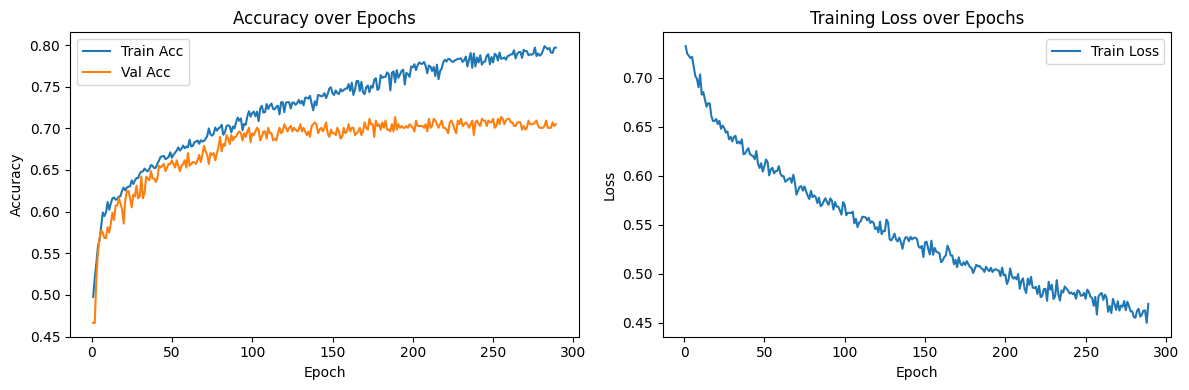


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 22 dim * 4.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  25%|██▍       | 248/1000 [12:23:01<37:33:02, 179.76s/it, Train Loss=0.5262, Train Acc=0.7618, Val Acc=0.6681, Val Kappa=0.3388, Best Val Kappa=0.3830 (Epoch 149), Best Val Acc=0.6898 (Epoch 149)]  


⏹️ Early stopping at epoch 249. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5660
📊 Final Test Cohen’s Kappa Score: 0.1319

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.57      0.51      0.54       144
     Feet (1)       0.56      0.62      0.59       144

     accuracy                           0.57       288
    macro avg       0.57      0.57      0.56       288
 weighted avg       0.57      0.57      0.56       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.6250
🎯 Specificity (Recall for Class 0 - Left Hand): 0.5069


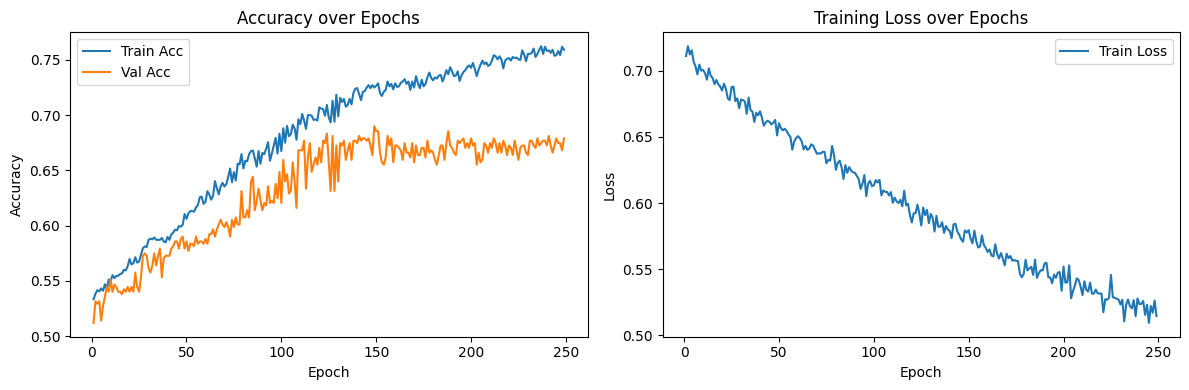


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  14%|█▍        | 141/1000 [09:47<59:37,  4.16s/it, Train Loss=0.5931, Train Acc=0.6864, Val Acc=0.6291, Val Kappa=0.2587, Best Val Kappa=0.2975 (Epoch 42), Best Val Acc=0.6486 (Epoch 42)]  


⏹️ Early stopping at epoch 142. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7431
📊 Final Test Cohen’s Kappa Score: 0.4861

🔬 Classification Report for Test Set:


               precision    recall  f1-score   support

Left Hand (0)       0.80      0.65      0.72       144
     Feet (1)       0.71      0.83      0.76       144

     accuracy                           0.74       288
    macro avg       0.75      0.74      0.74       288
 weighted avg       0.75      0.74      0.74       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.8333
🎯 Specificity (Recall for Class 0 - Left Hand): 0.6528


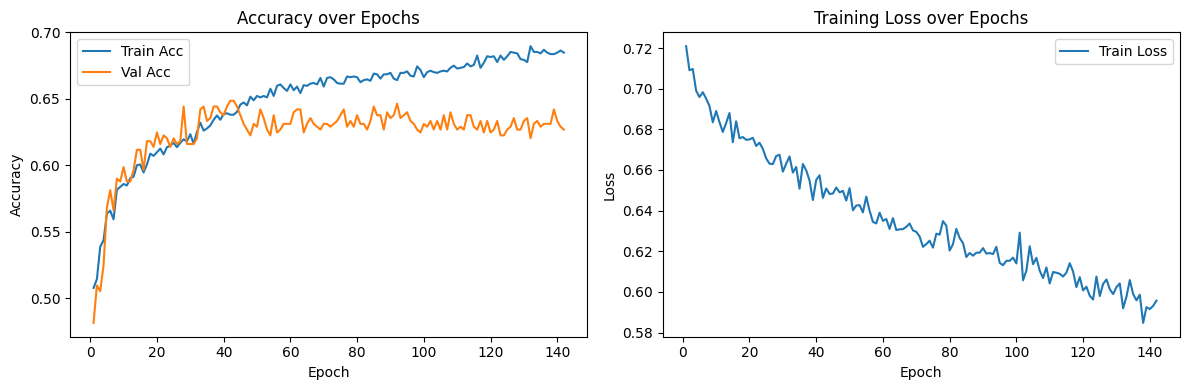


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1189/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  51%|█████     | 507/1000 [4:59:52<4:51:35, 35.49s/it, Train Loss=0.4004, Train Acc=0.8448, Val Acc=0.6811, Val Kappa=0.3651, Best Val Kappa=0.3942 (Epoch 408), Best Val Acc=0.6963 (Epoch 408)] 


⏹️ Early stopping at epoch 508. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5347
📊 Final Test Cohen’s Kappa Score: 0.0694

🔬 Classification Report for Test Set:
               precision    recall  f1-score   support

Left Hand (0)       0.55      0.36      0.44       144
     Feet (1)       0.53      0.71      0.60       144

     accuracy                           0.53       288
    macro avg       0.54      0.53      0.52       288
 weighted avg       0.54      0.53      0.52       288

🎯 Sensitivity (Recall for Class 1 - Feet): 0.7083
🎯 Specificity (Recall for Class 0 - Left Hand): 0.3611


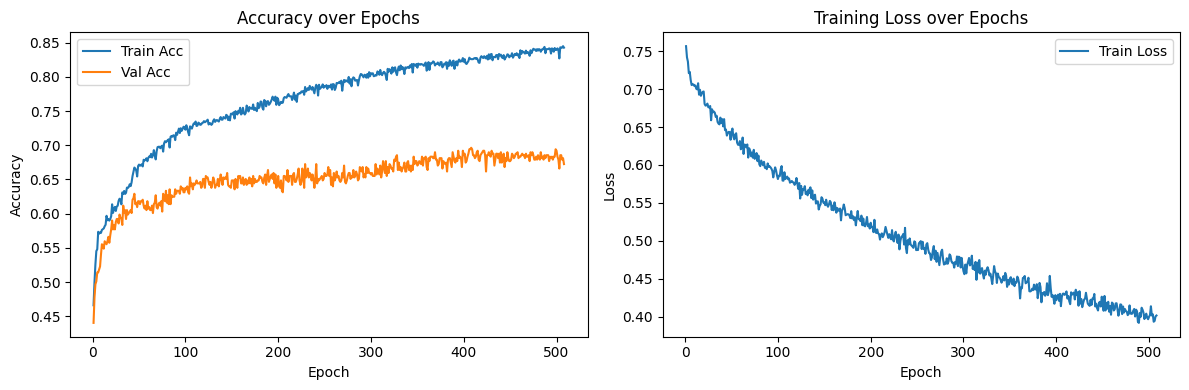

In [8]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    train_mask = np.isin(train_labels_all, [2, 3])
    test_mask = np.isin(test_labels, [2, 3])

    # Filter the data based on the mask
    train_data_binary = train_data_all[train_mask]
    test_data_binary = test_data[test_mask]
    train_labels_binary = (train_labels_all[train_mask] == 3).astype(int)
    test_labels_binary = (test_labels[test_mask] == 3).astype(int)

    # CSP Feature Extraction
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_labels, final_preds = evaluate_model(model, test_loader, return_preds=True)
    
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Print the additional metrics
    print("\n🔬 Classification Report for Test Set:")
    # Updated target names for clarity
    print(classification_report(final_labels, final_preds, target_names=['Left Hand (0)', 'Feet (1)']))

    # To calculate sensitivity and specificity manually from the confusion matrix
    cm = confusion_matrix(final_labels, final_preds)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"🎯 Sensitivity (Recall for Class 1 - Feet): {sensitivity:.4f}")
        print(f"🎯 Specificity (Recall for Class 0 - Left Hand): {specificity:.4f}")
    else:
        print("Could not compute sensitivity/specificity from confusion matrix (likely only one class was predicted).")
        print(f"Confusion Matrix:\n{cm}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()


    plot_learning_curves(train_losses, train_accuracies, val_accuracies)

In [ ]:
import pandas as pd